In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skyproj, healpy as hp, healsparse as hsp, h5py, fitsio
from scipy import stats
from scipy.ndimage import gaussian_filter1d

import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=17)


COLORS = ["f07167","219ebc","ffba0a","c767ac","59a270"]
COLORS = ['#' + c if c[0] != '#' else c for c in COLORS ]

from cycler import cycler

# Update the default prop_cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=COLORS)

In [2]:
p      = '/project/kadrlica/dhayaa/Redmapper'
decade = fitsio.read(p + '/DECADEEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
des    = fitsio.read(p + '/DESEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')

In [3]:
decade_sys = fitsio.read(p + '/DECADEEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog_sysmaps.fit')
des_sys    = fitsio.read(p+ '/DESEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog_sysmaps.fit')

# Redshift estimates

In [5]:
def run(sym, data):
    
    msk = sym
    z   = data['z_lambda'][msk]
    dz  = (data['z_lambda'][msk] - data['cg_spec_z'][msk]) / (1 + data['z_lambda'][msk])
    sz  = data['z_lambda_e'][msk] / (1 + data['z_lambda'][msk])

    ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
    med = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]
    avg = [stats.binned_statistic(z[m], dz[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
    std = [stats.binned_statistic(z[m], dz[m], statistic = 'std',    bins = zbs)[0] for m in ind]
    err = [stats.binned_statistic(z[m], sz[m], statistic = 'median', bins = zbs)[0] for m in ind]

    std = gaussian_filter1d(np.median(std, axis = 0), sigma = 1)
    med = [gaussian_filter1d(m, sigma = 1) for m in med]
    
    return med, avg, std, err

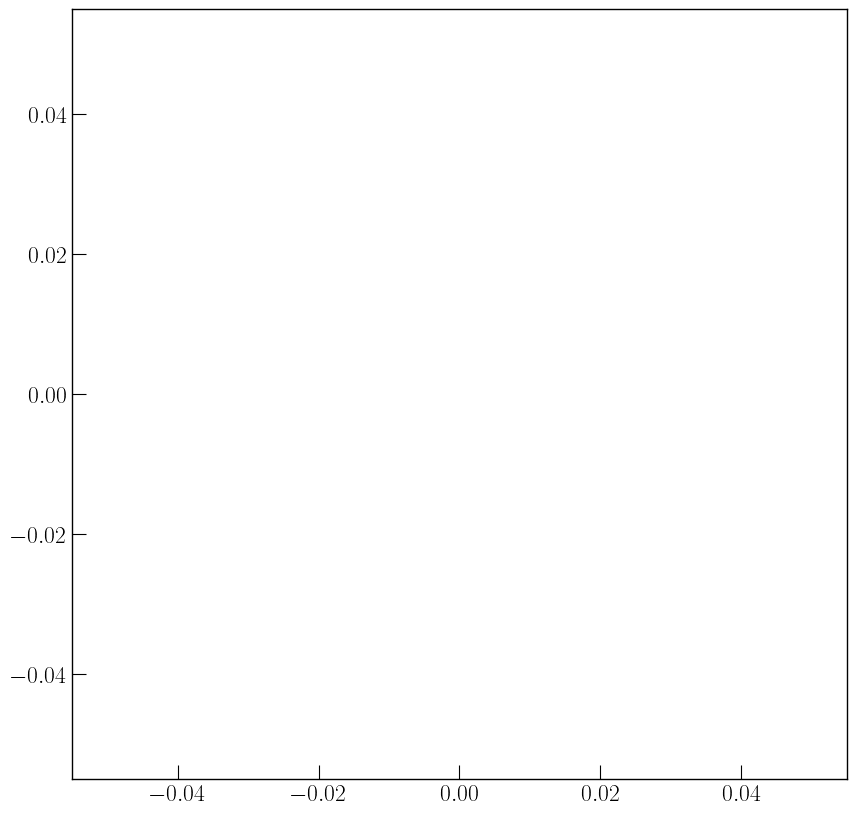

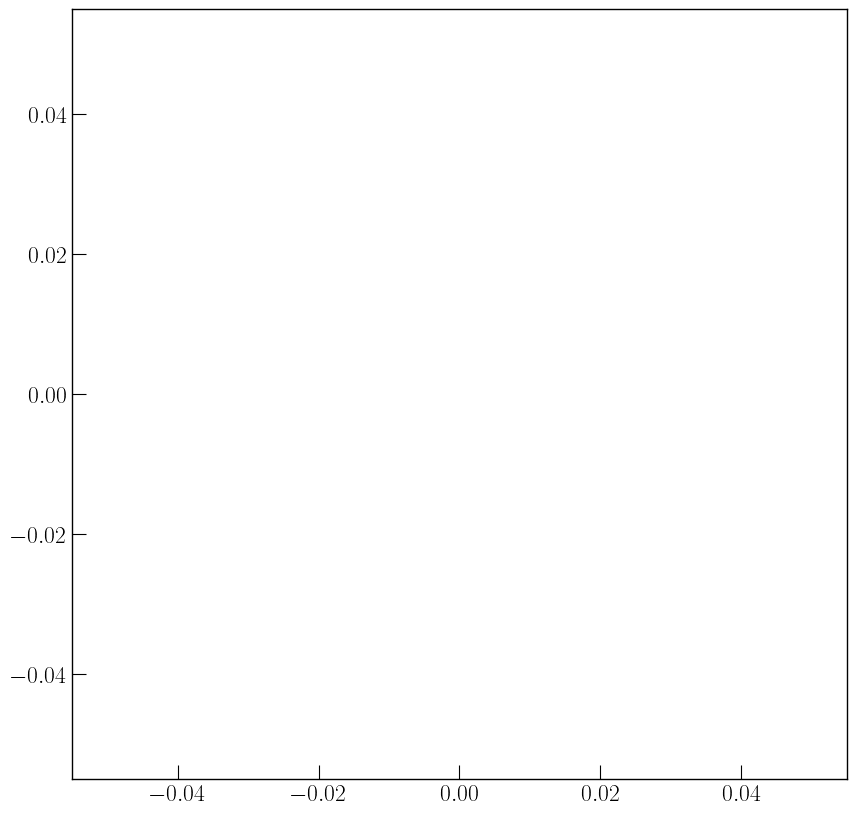

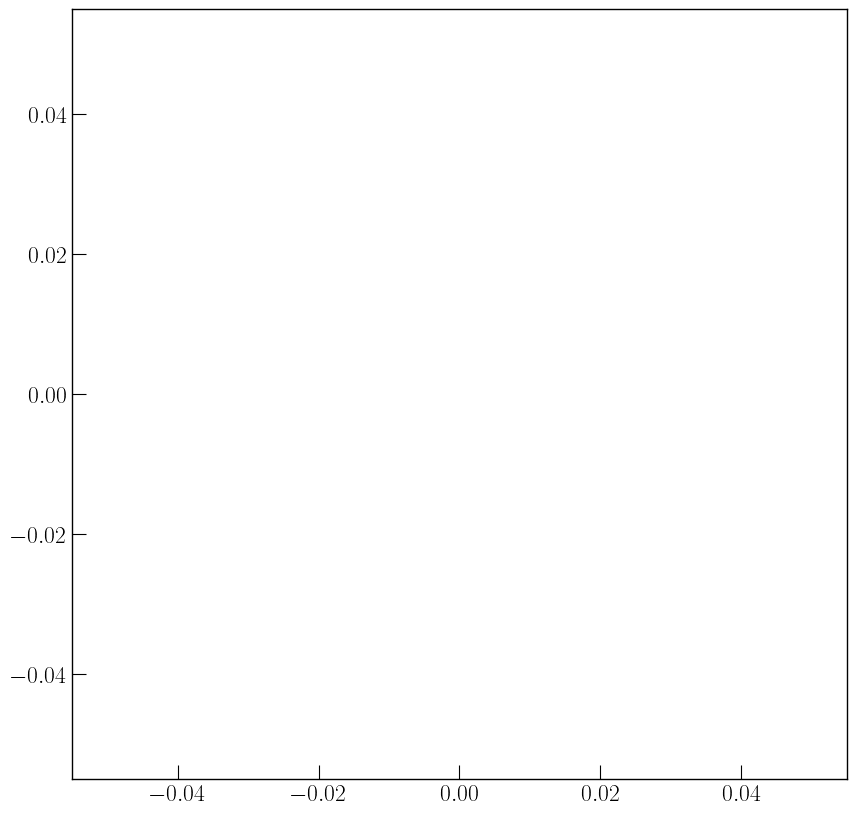

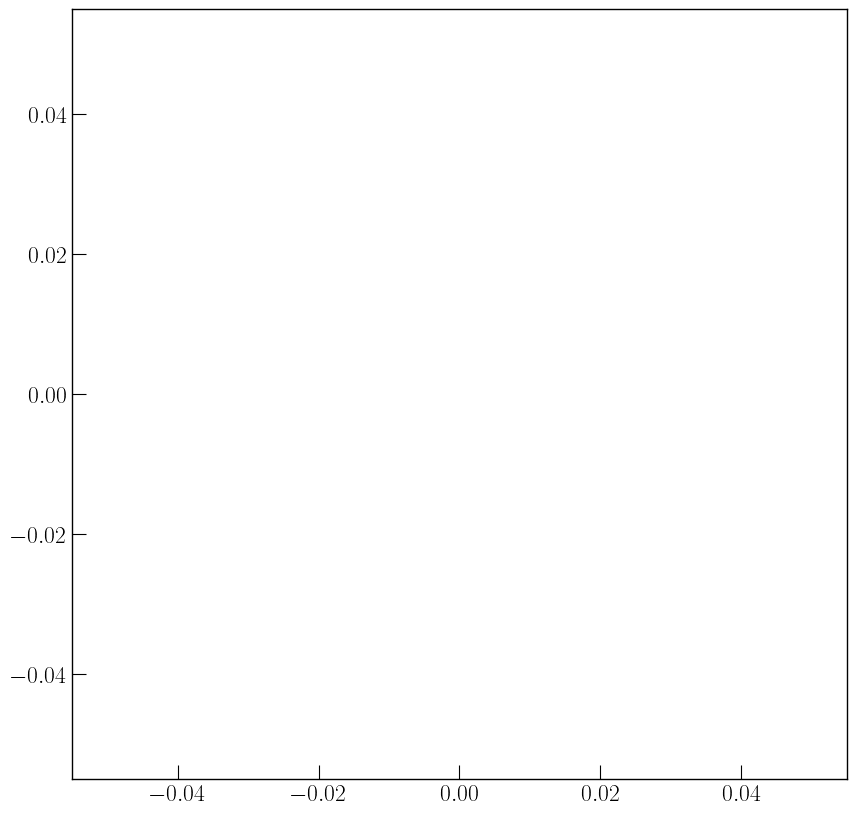

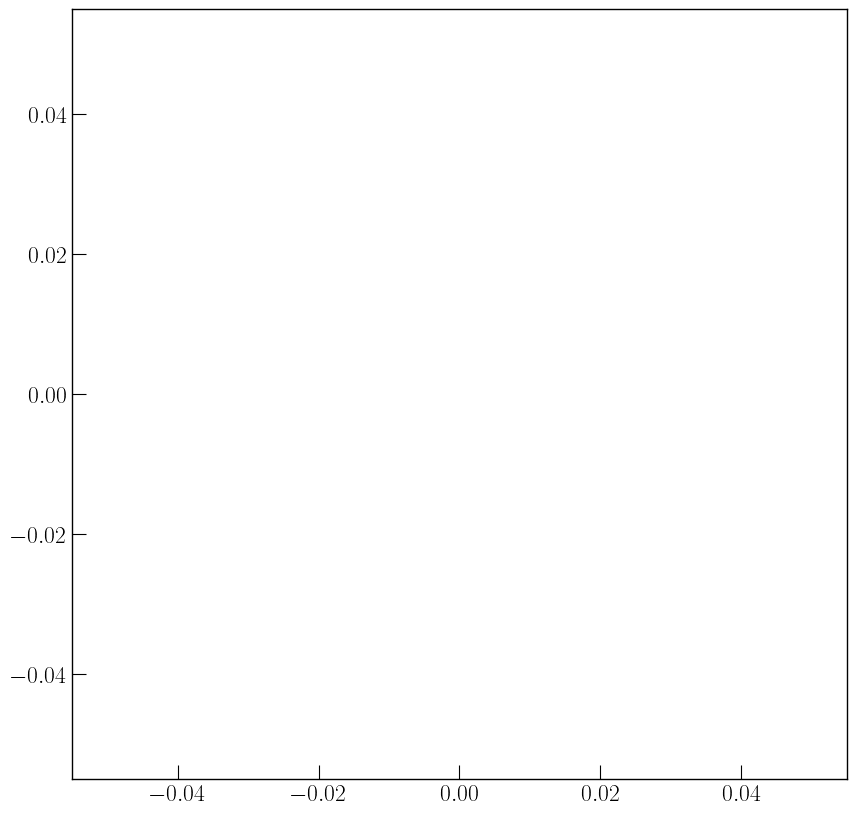

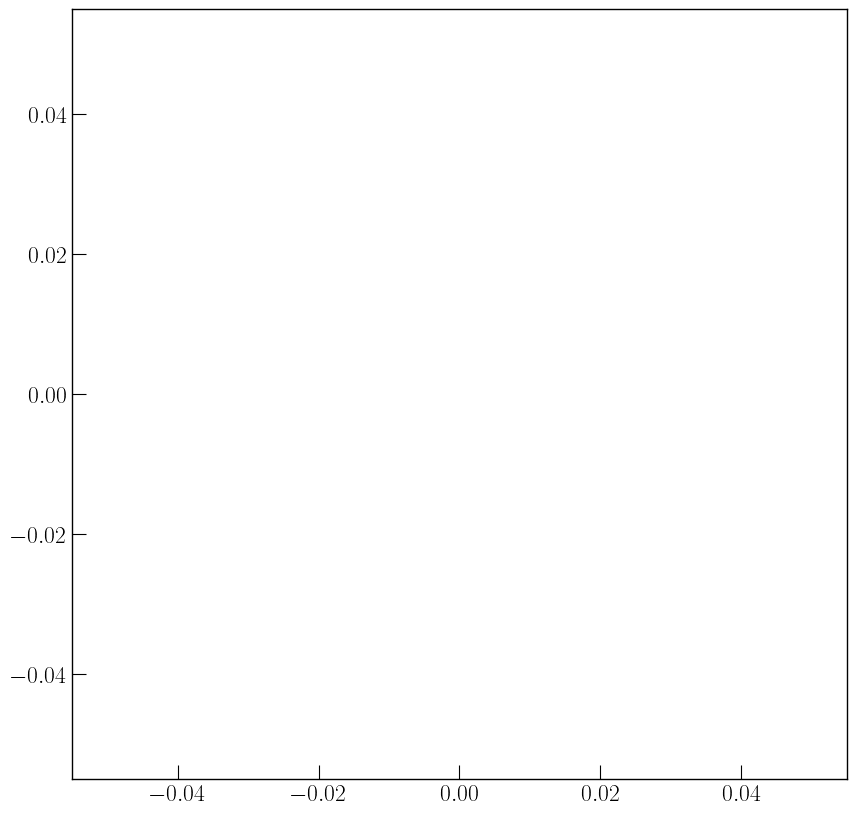

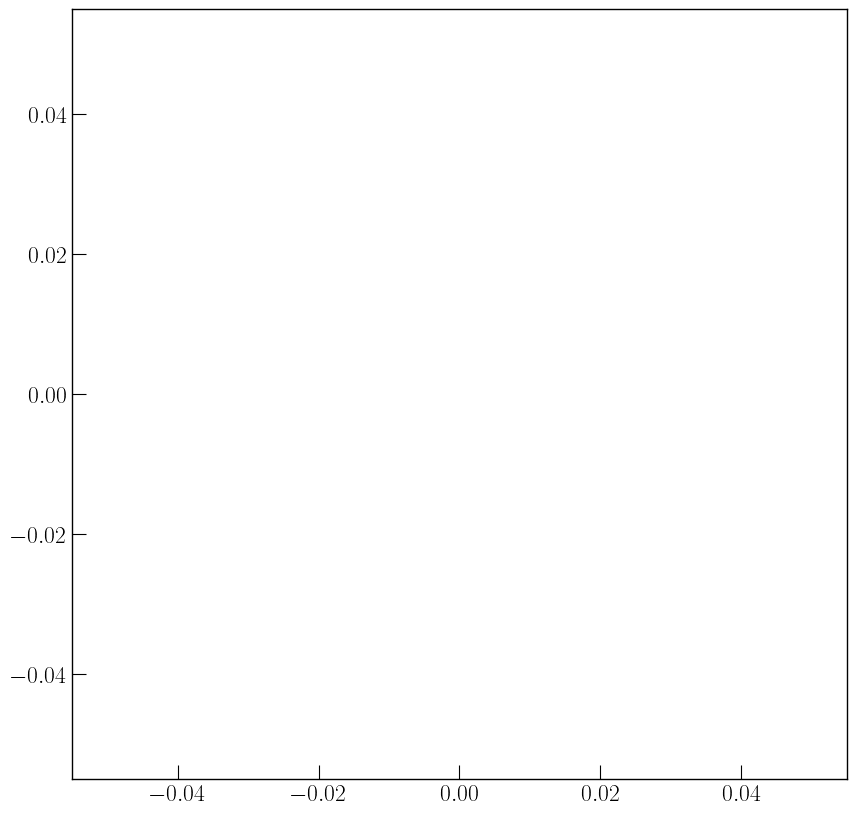

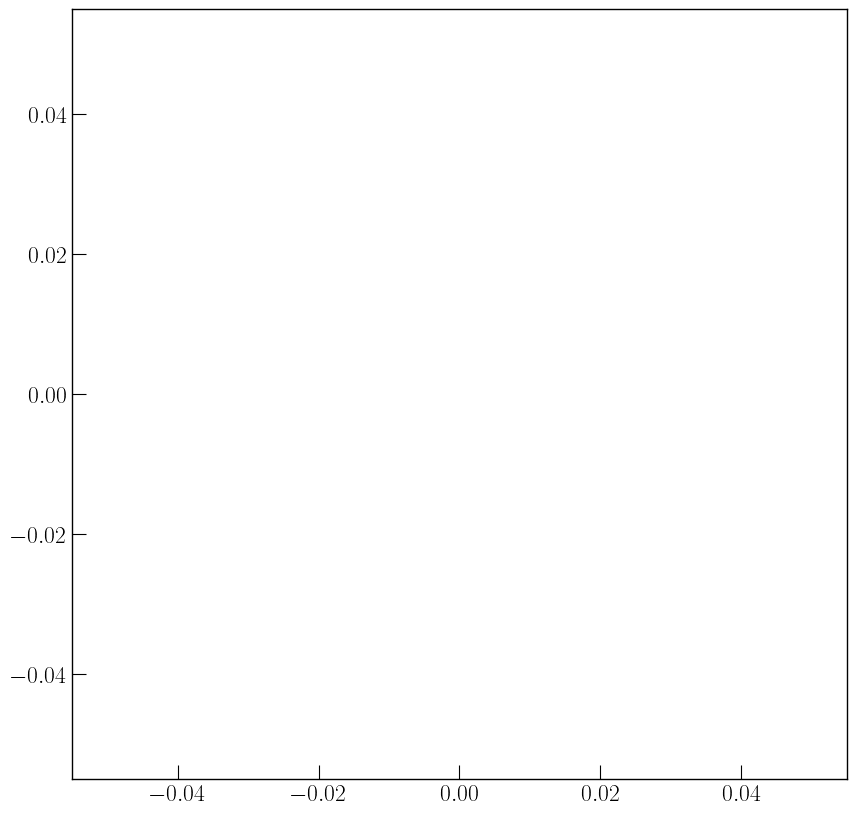

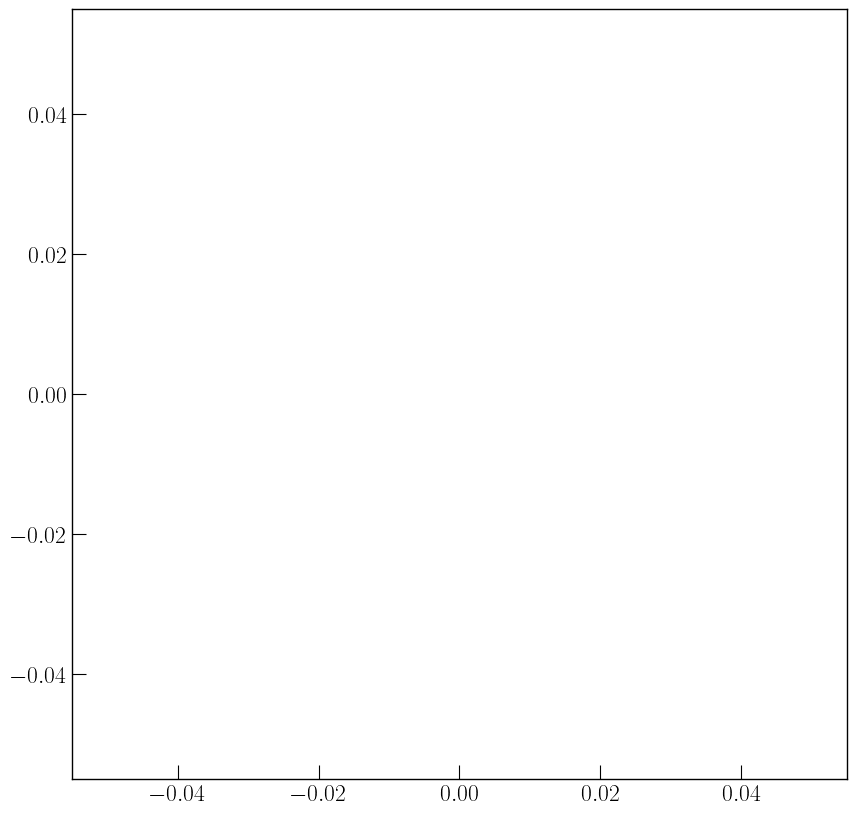

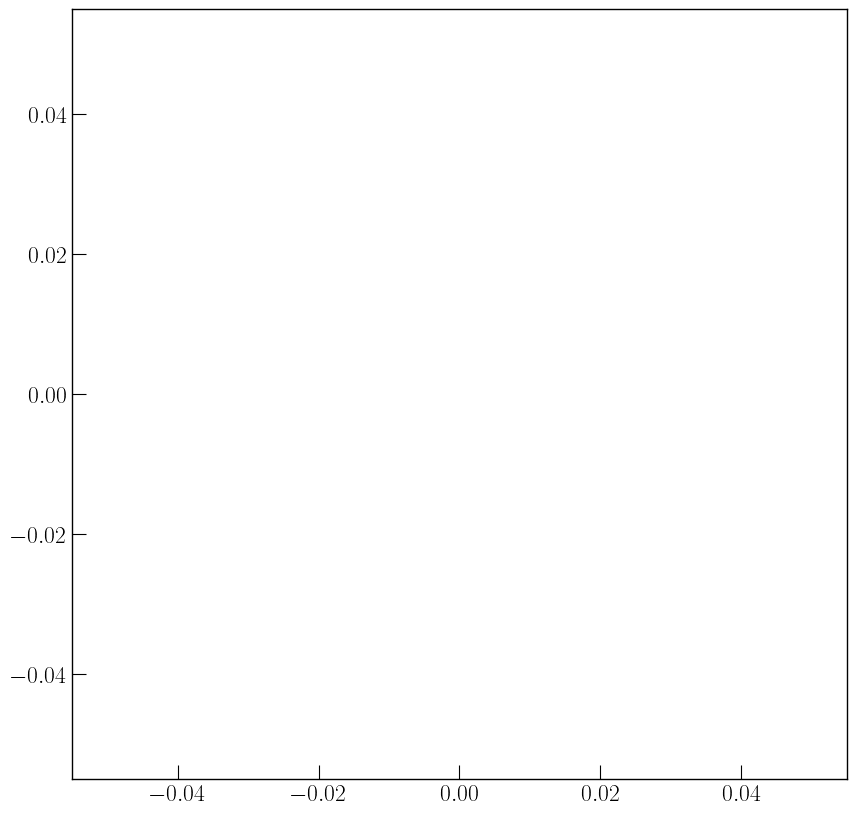

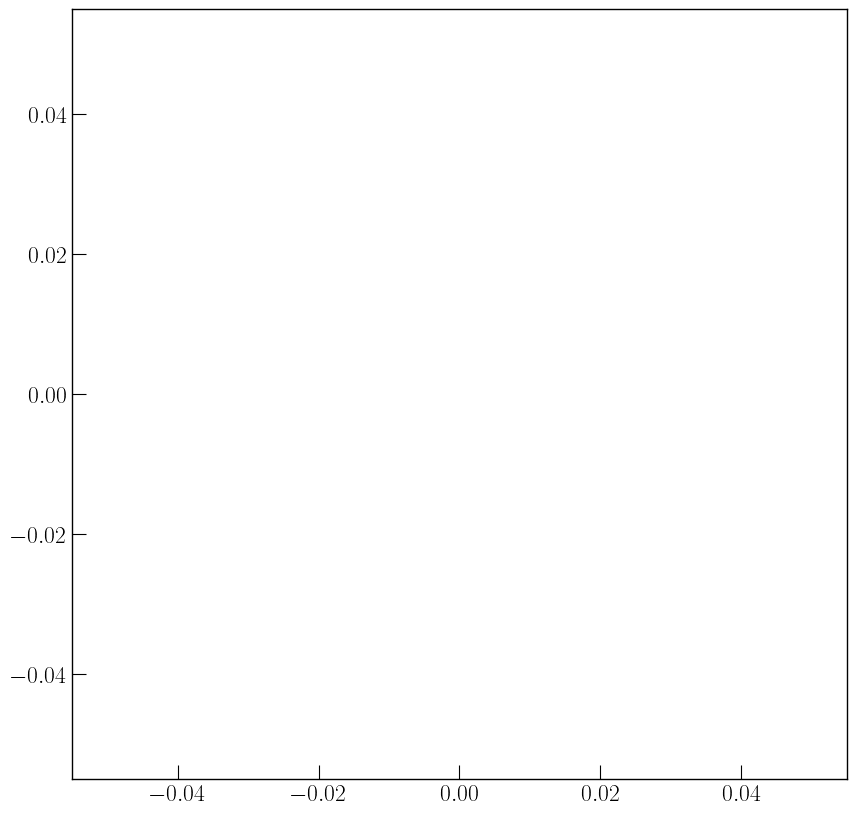

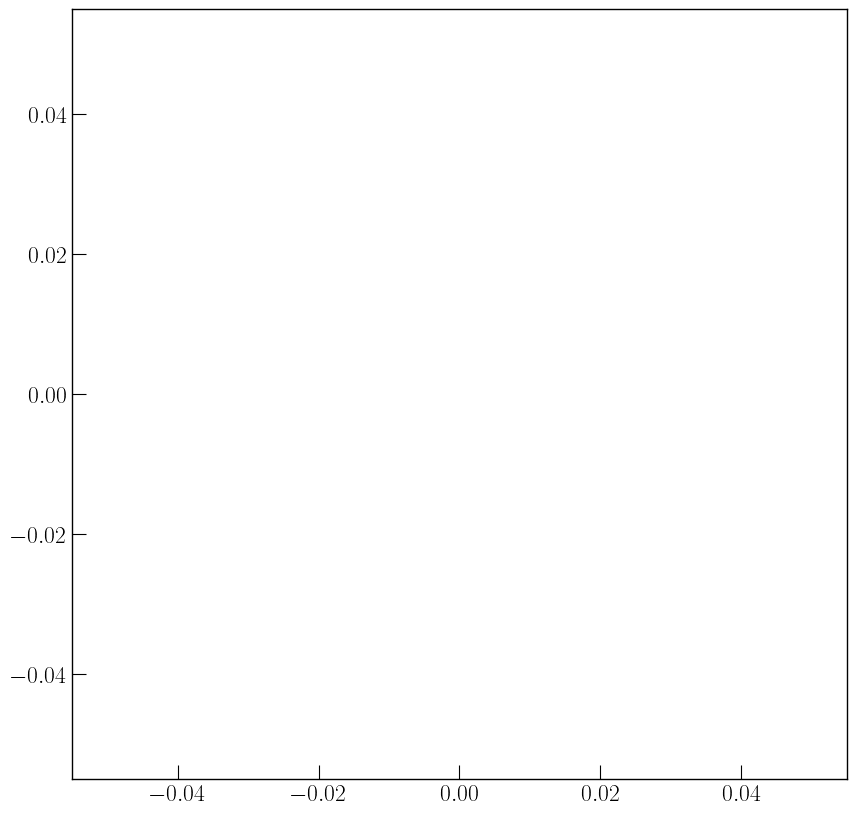

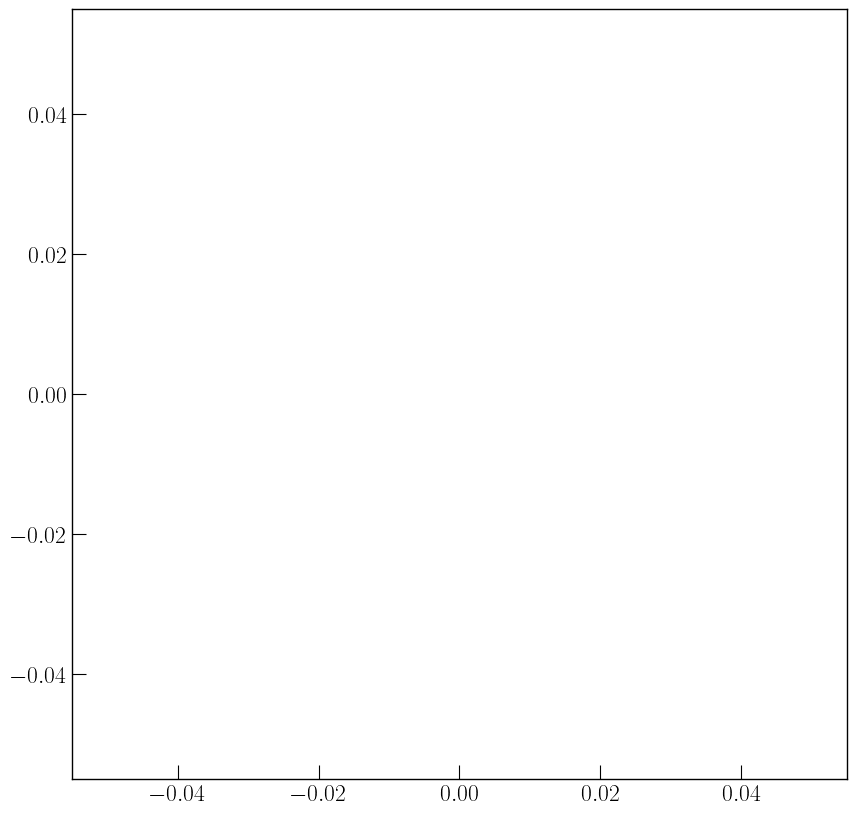

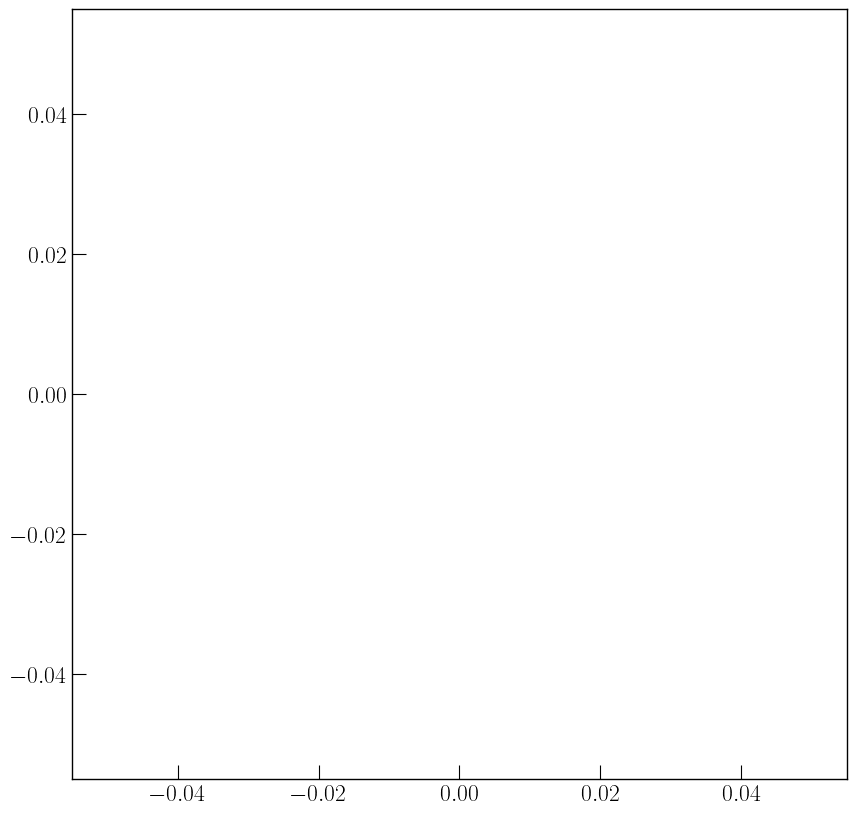

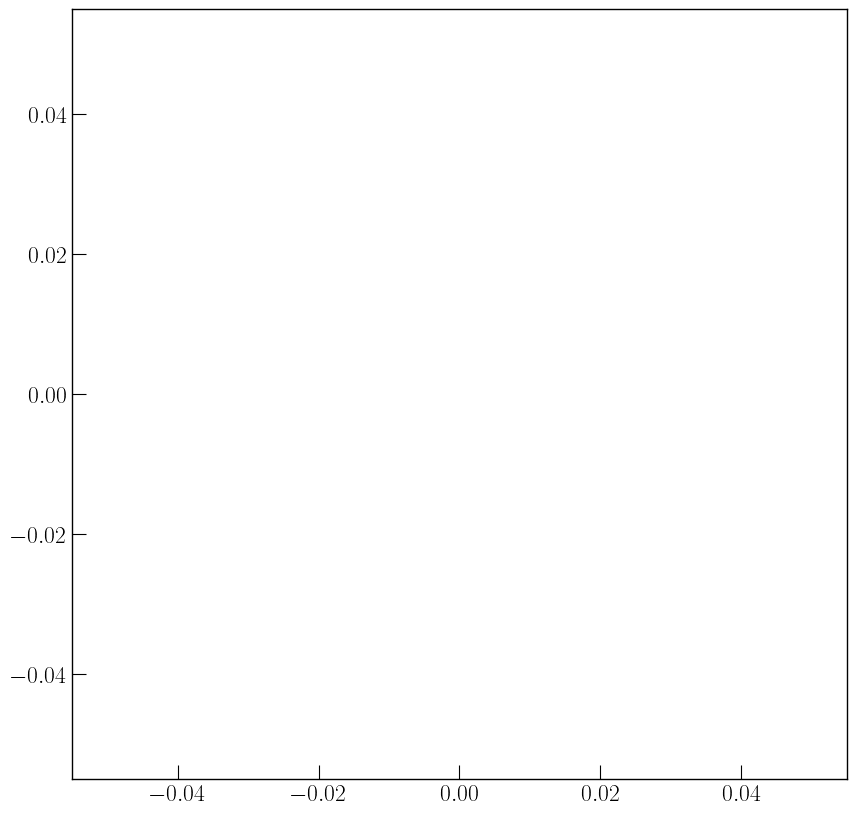

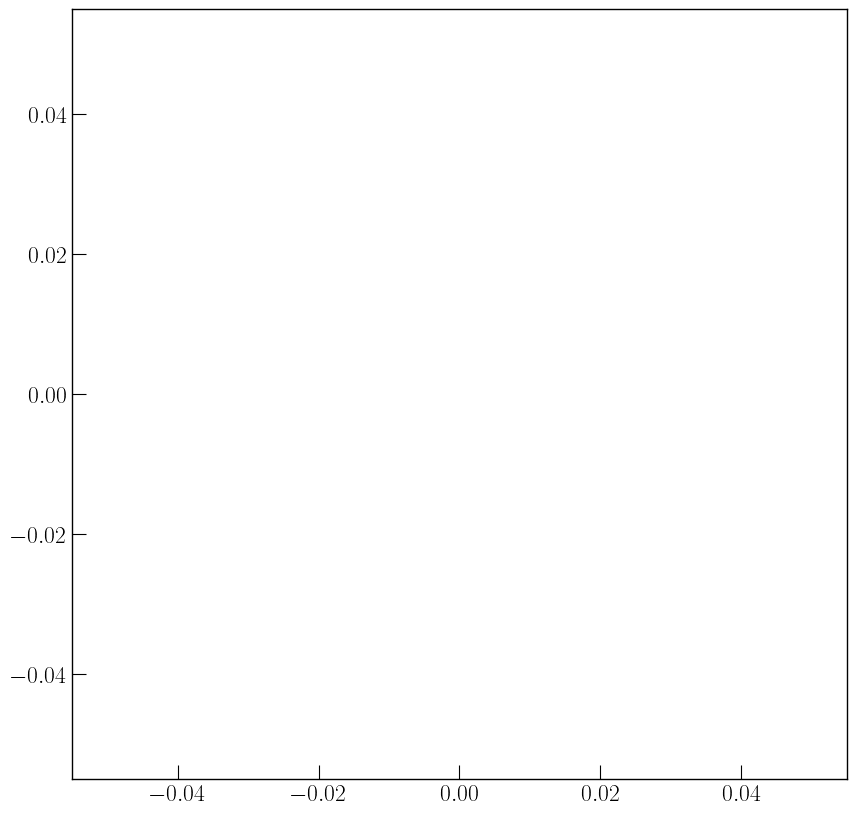

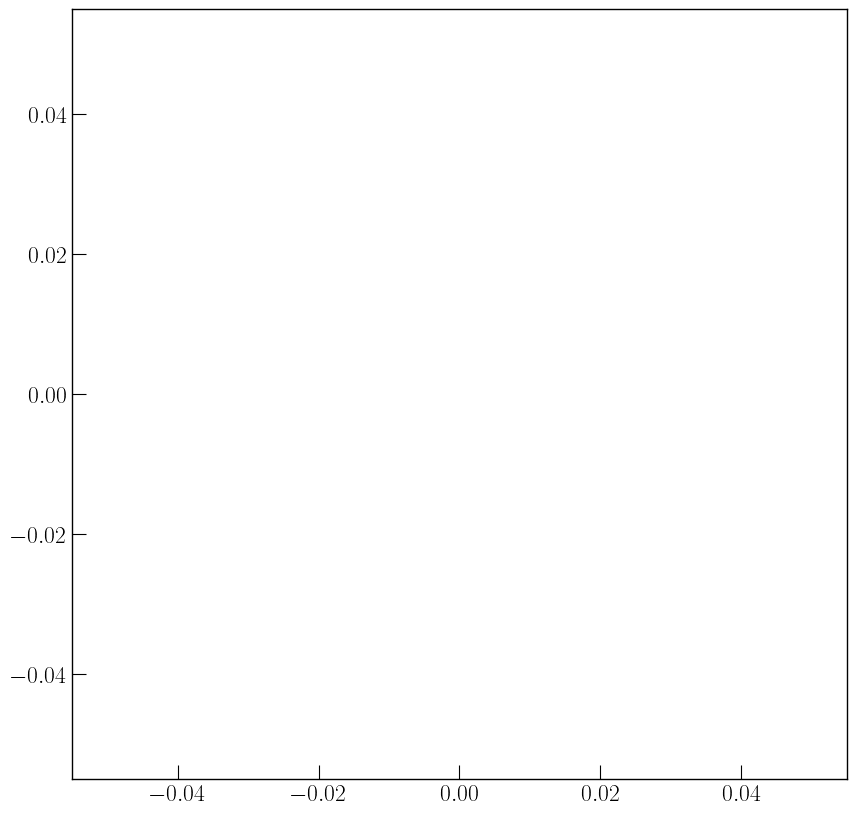

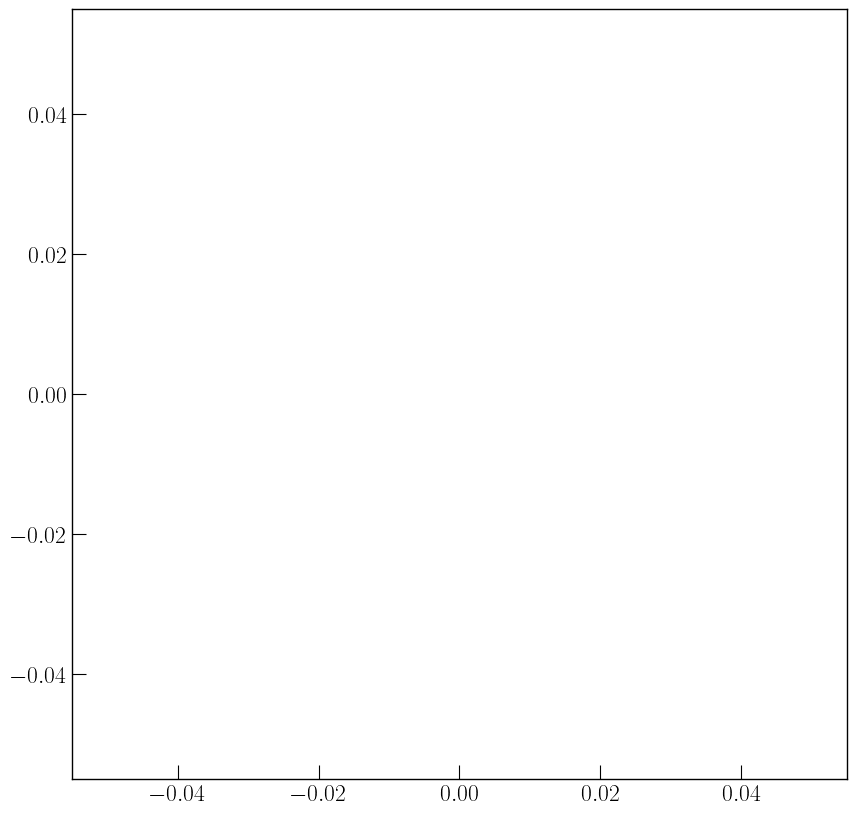

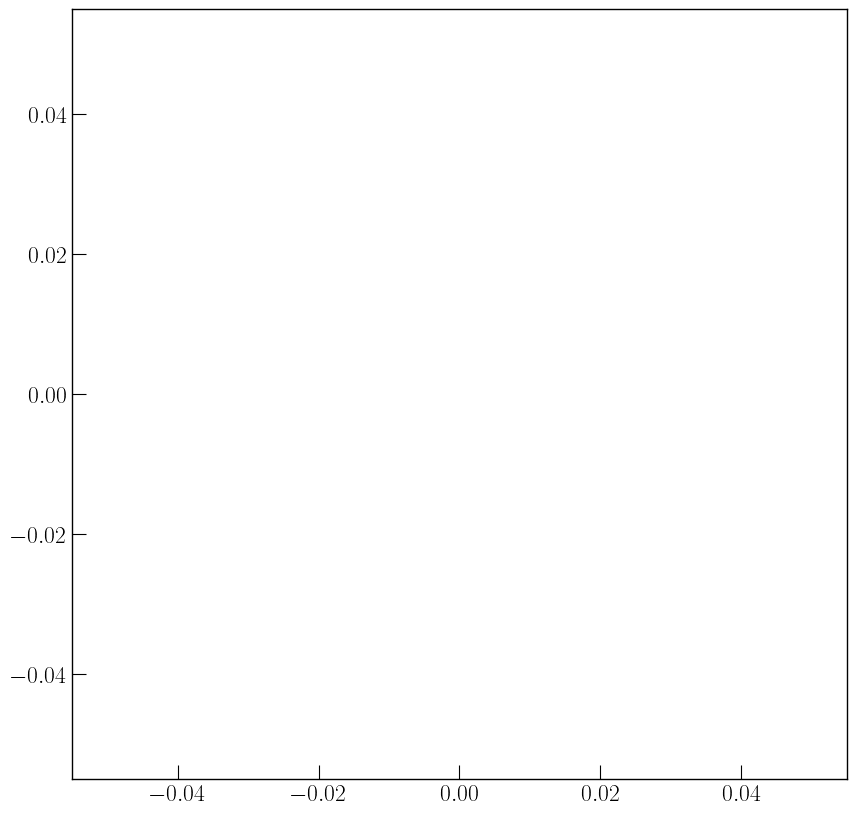

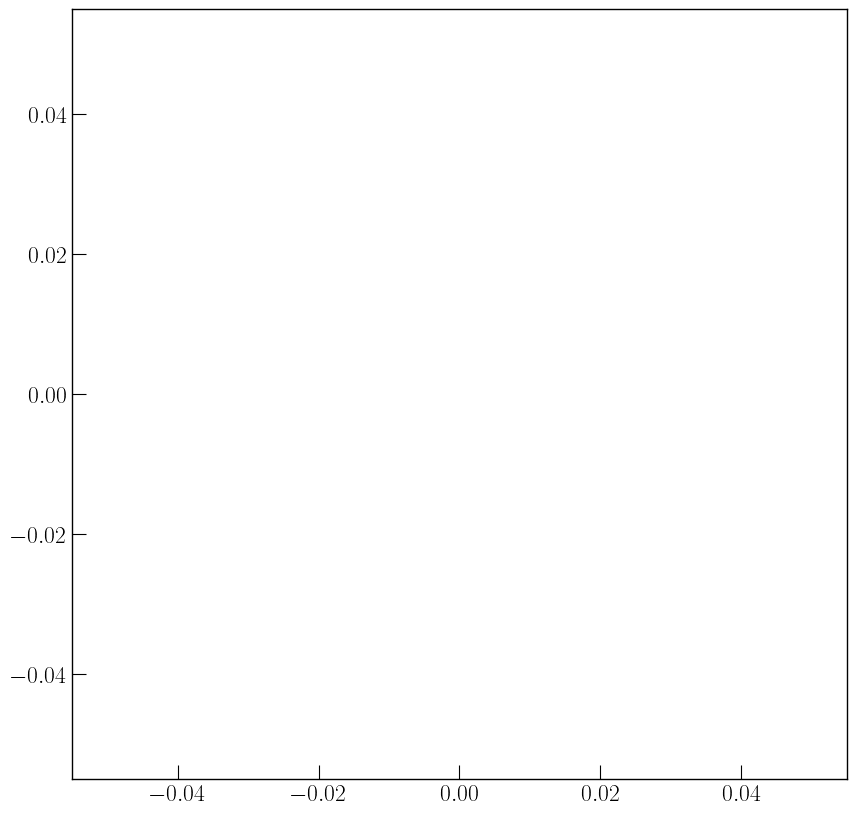

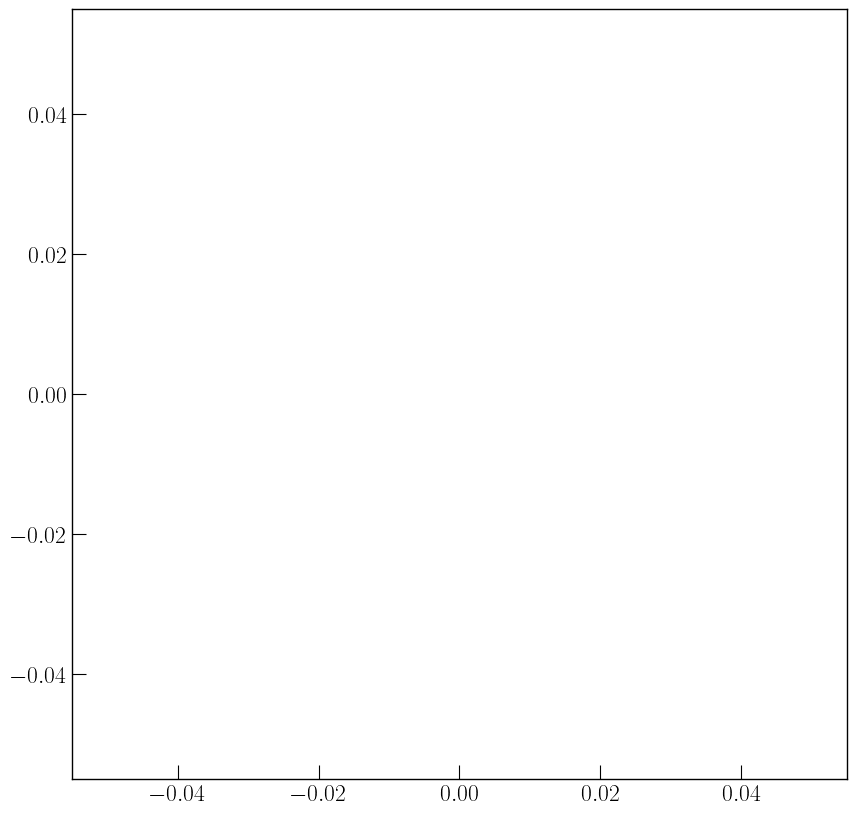

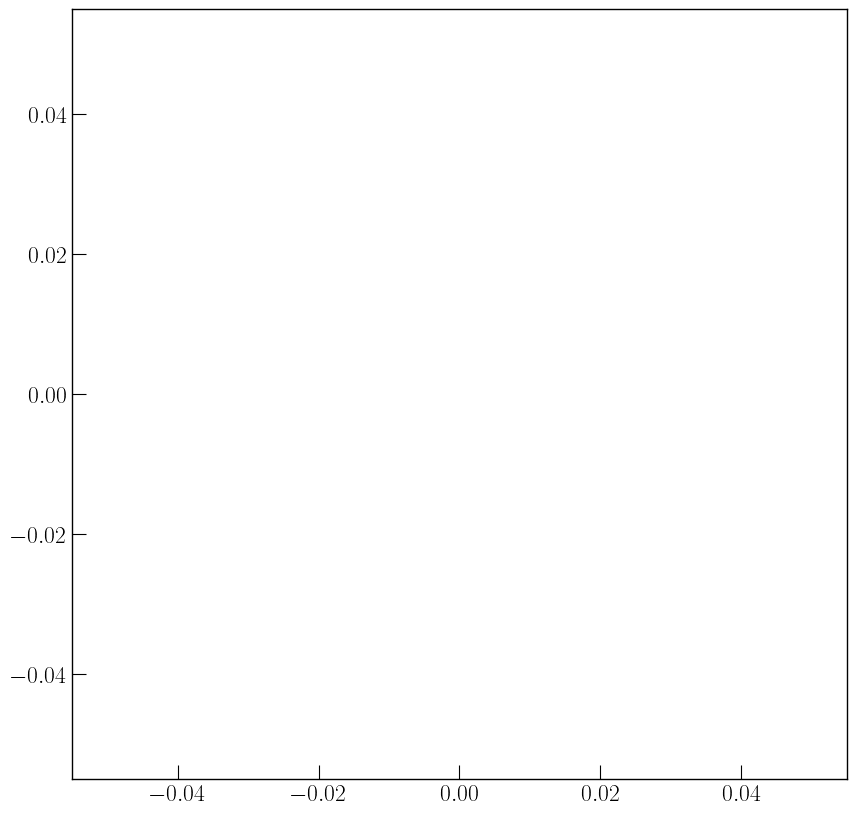

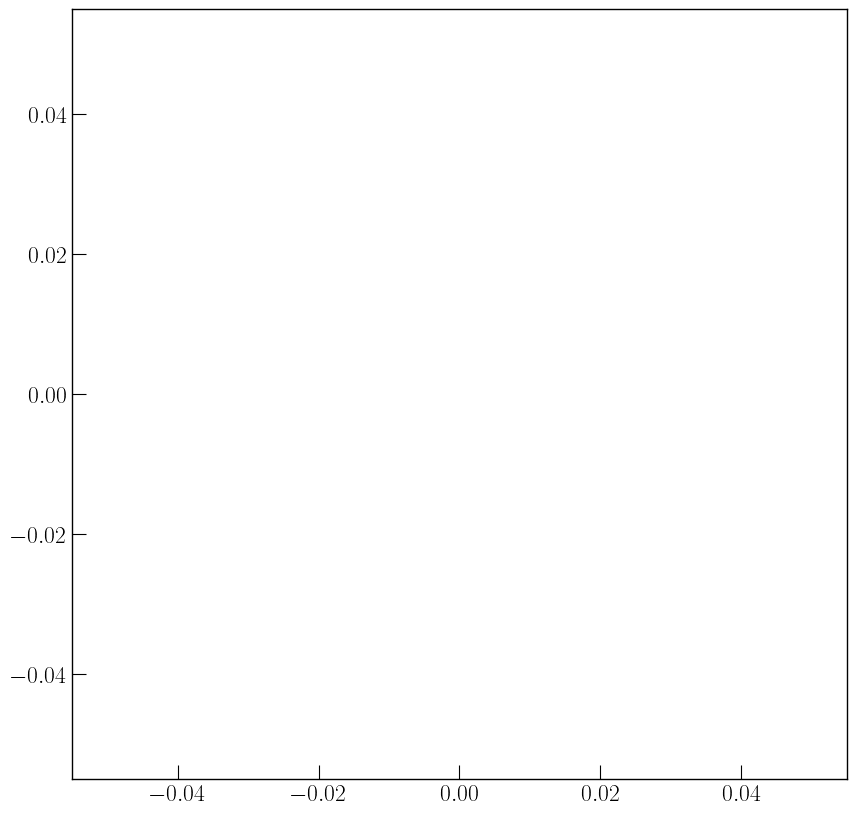

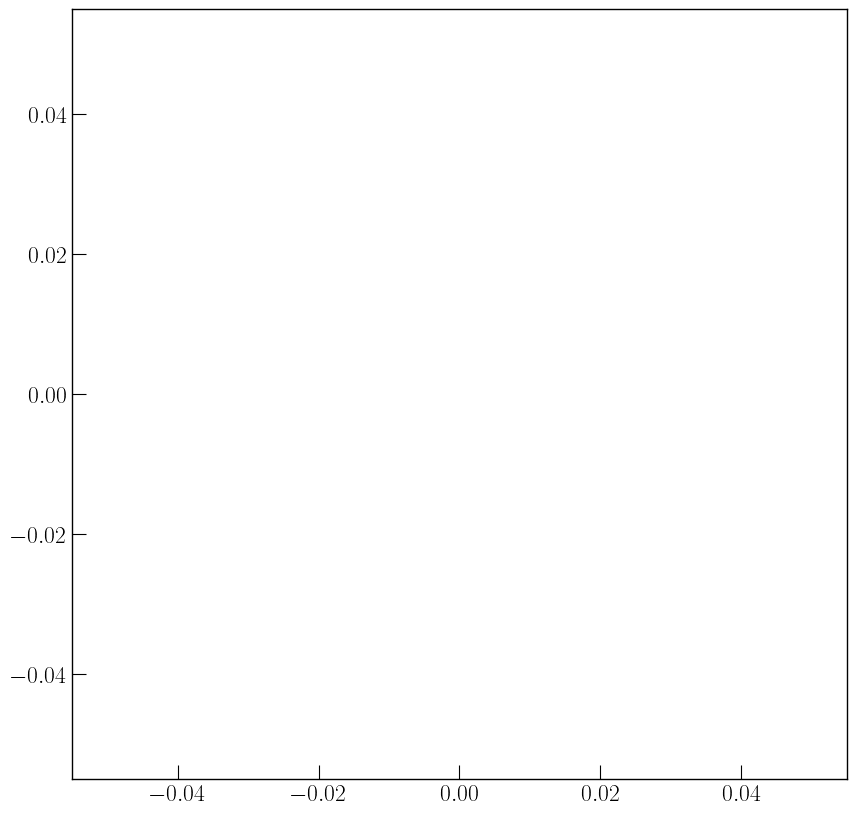

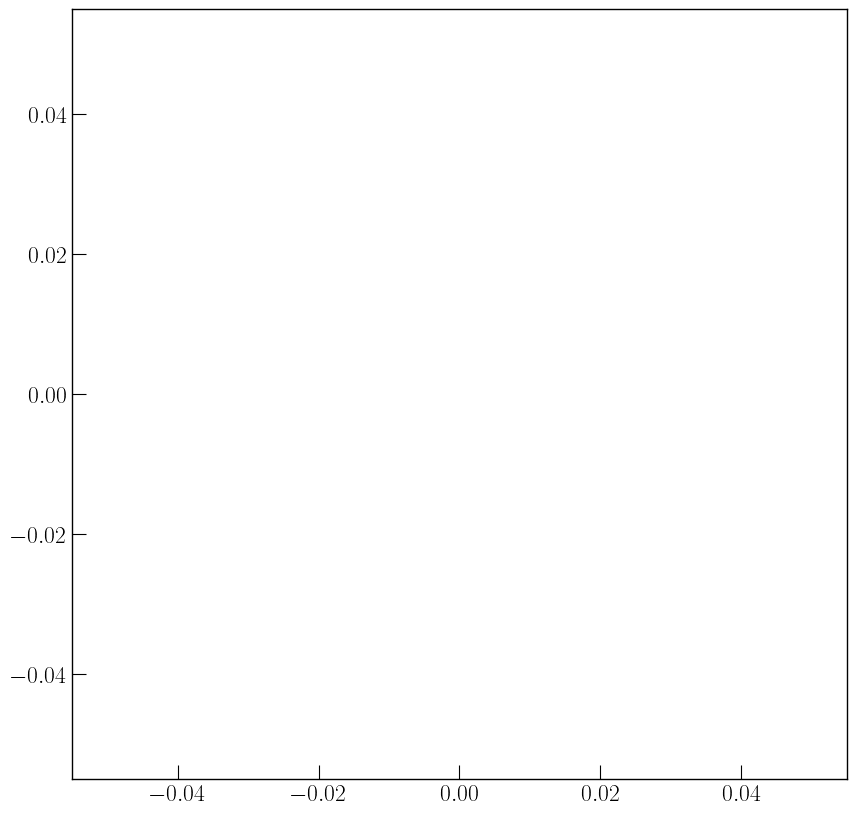

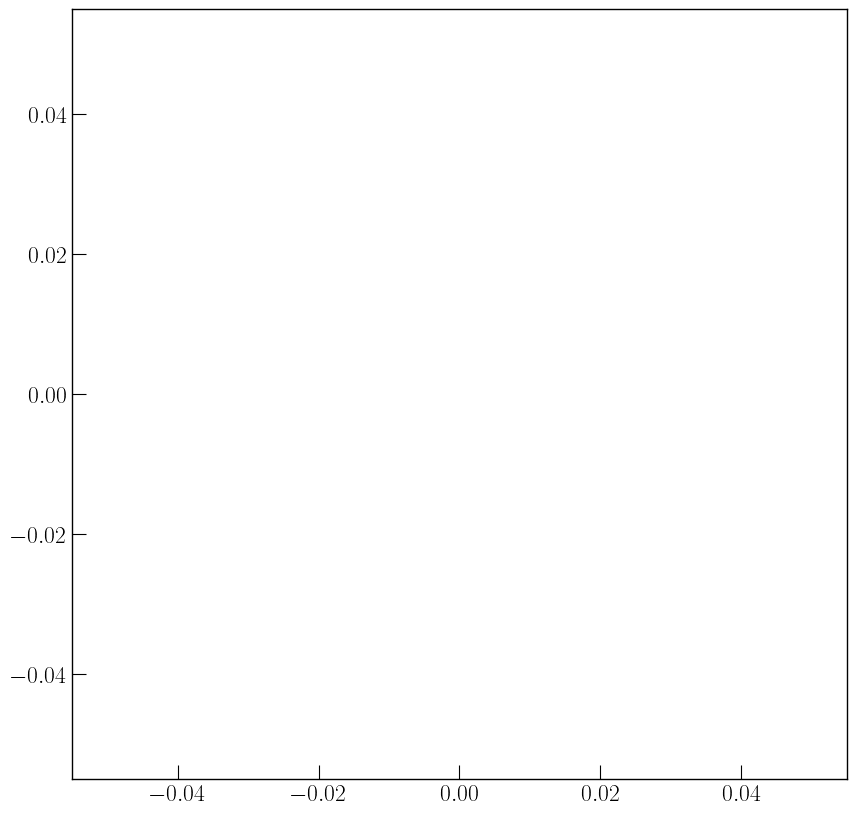

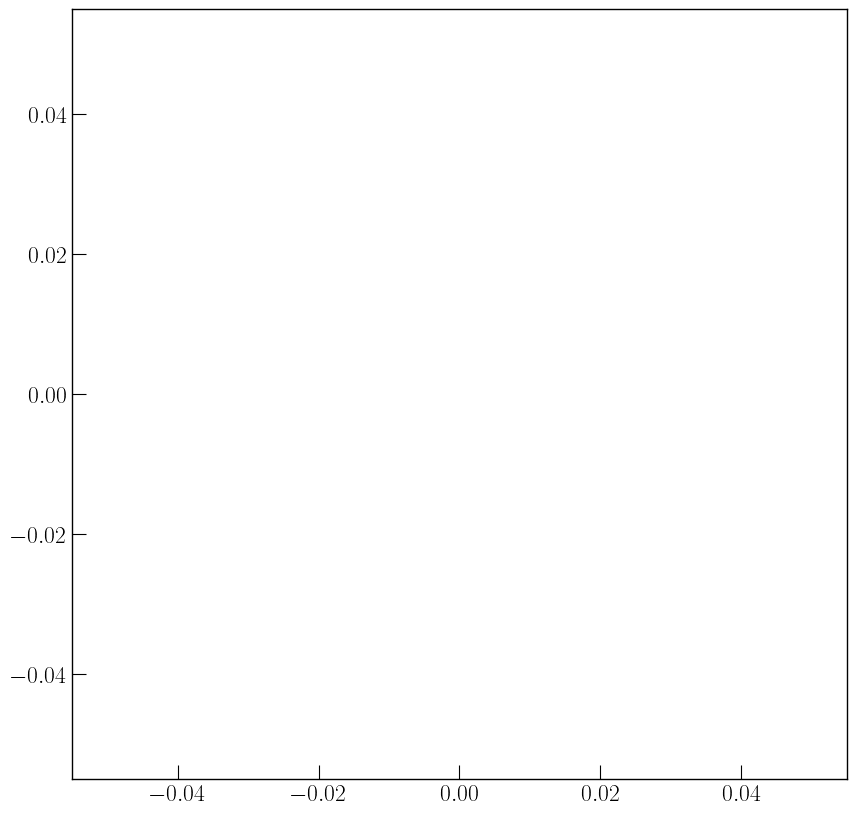

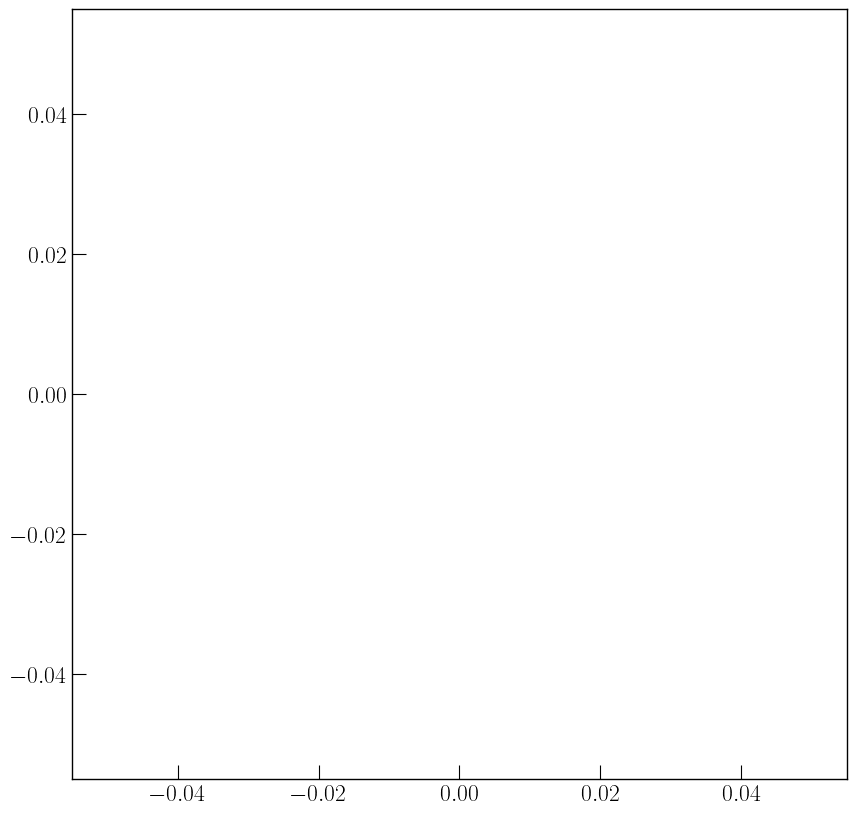

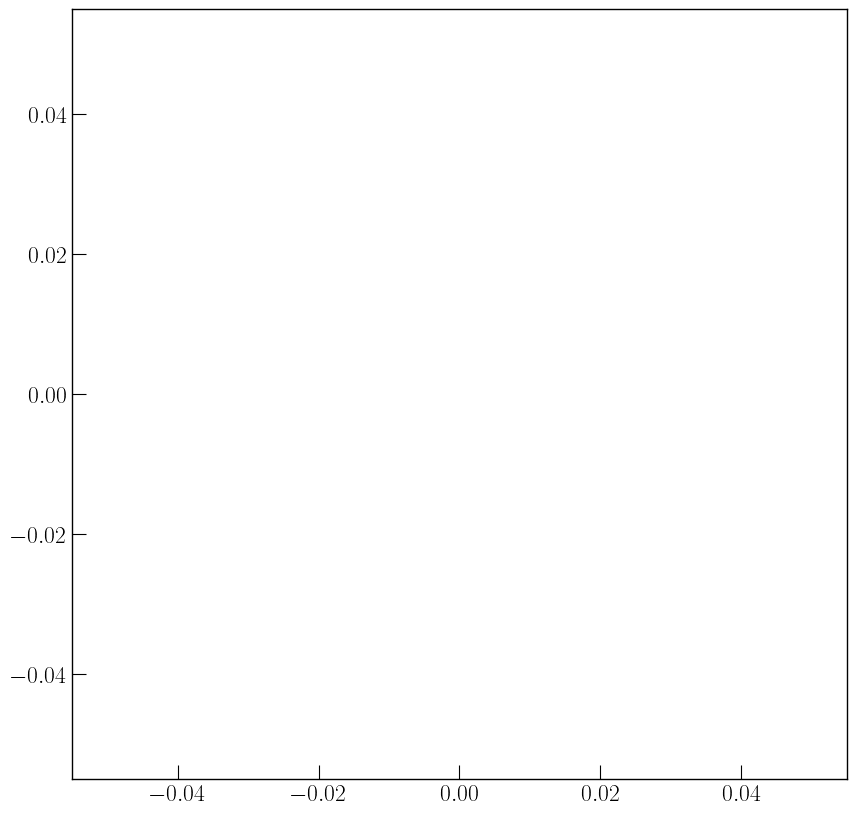

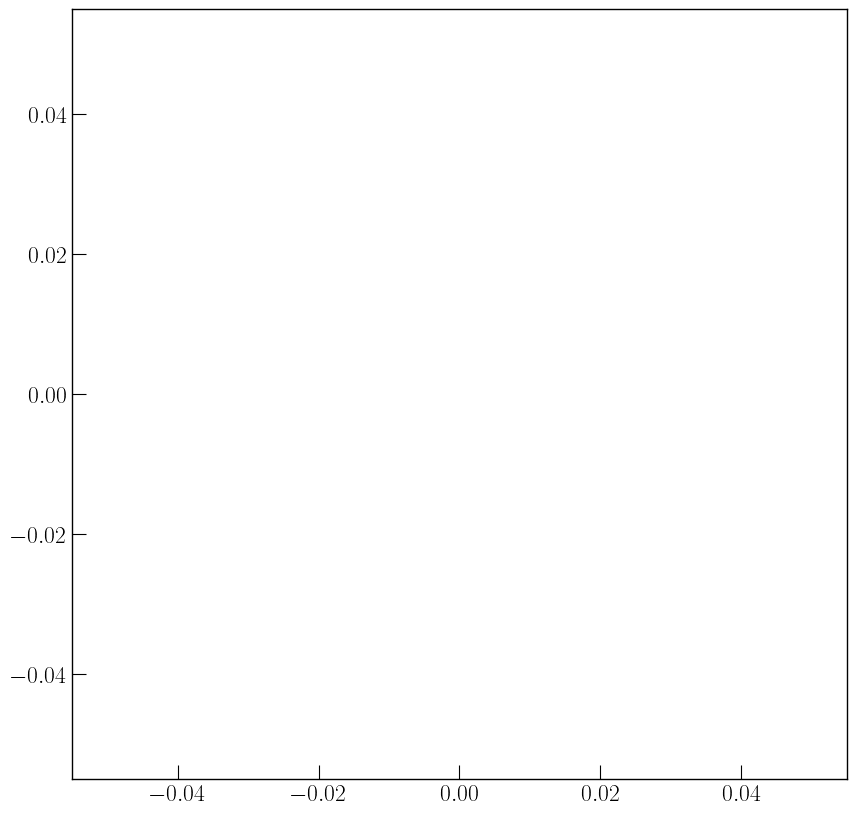

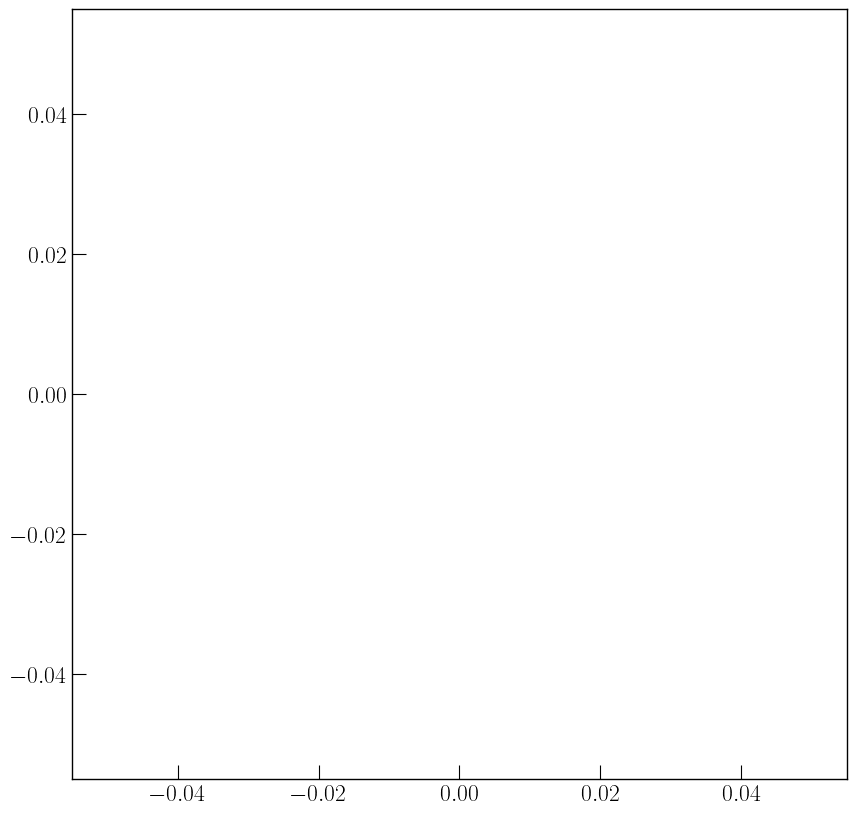

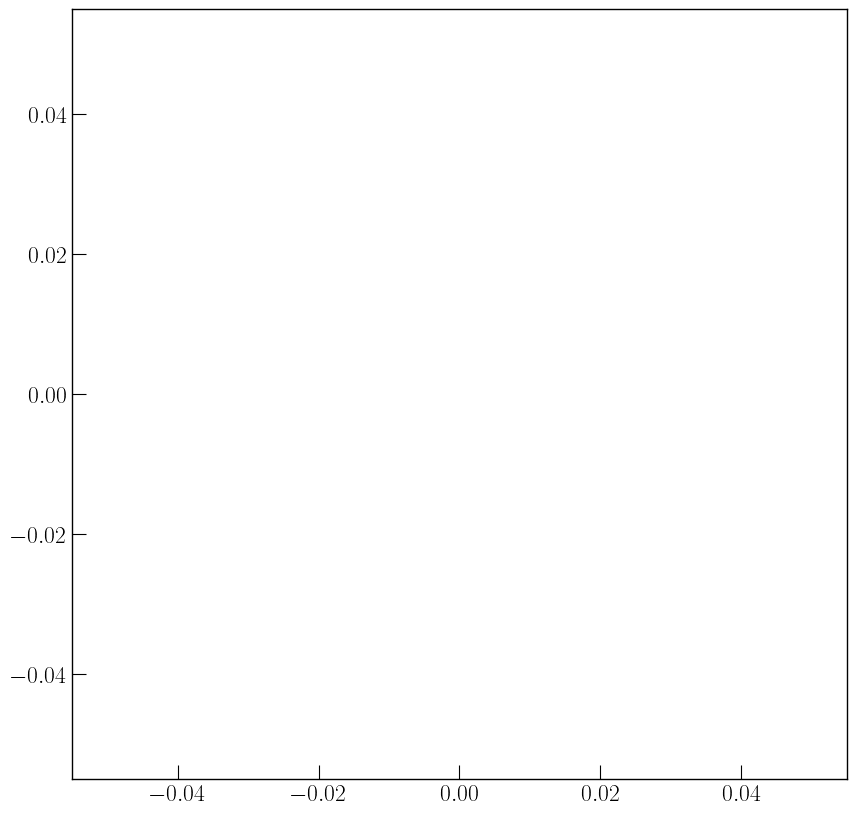

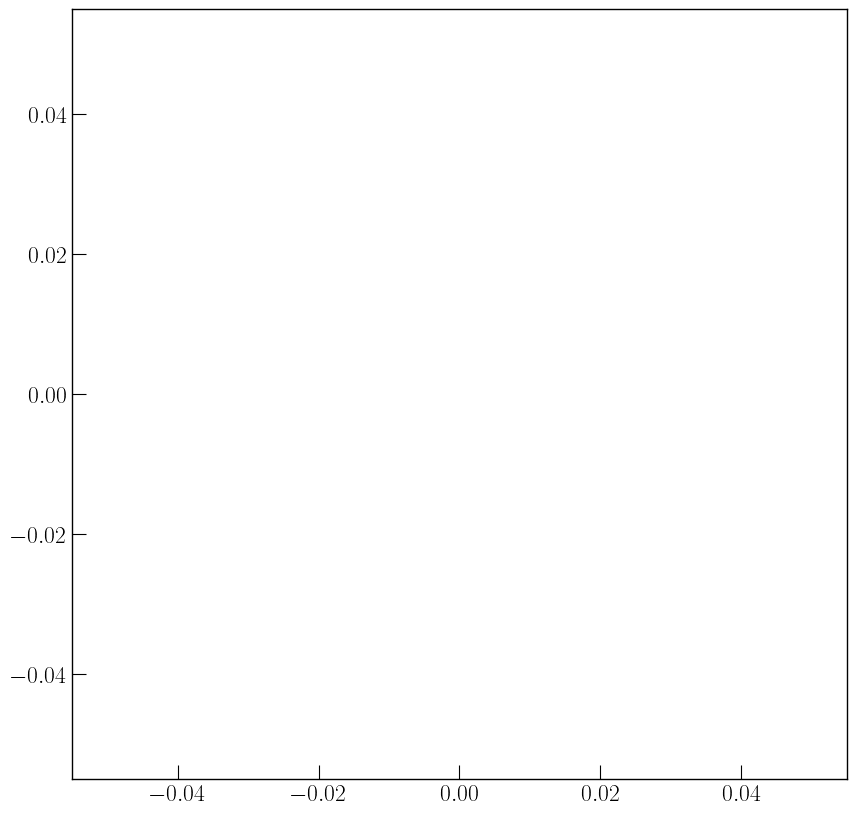

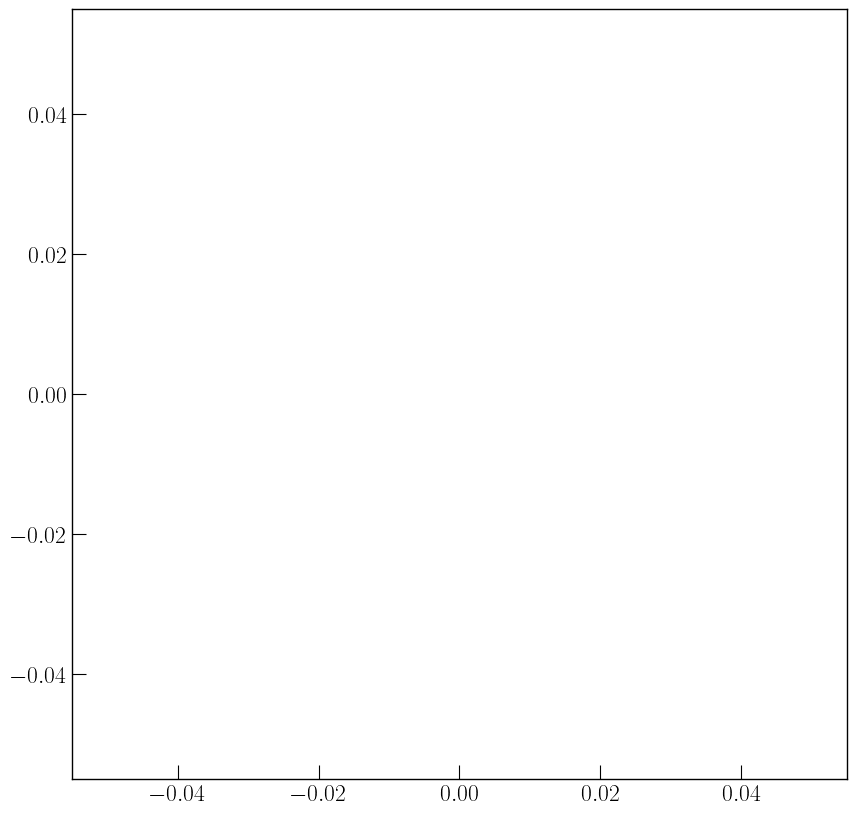

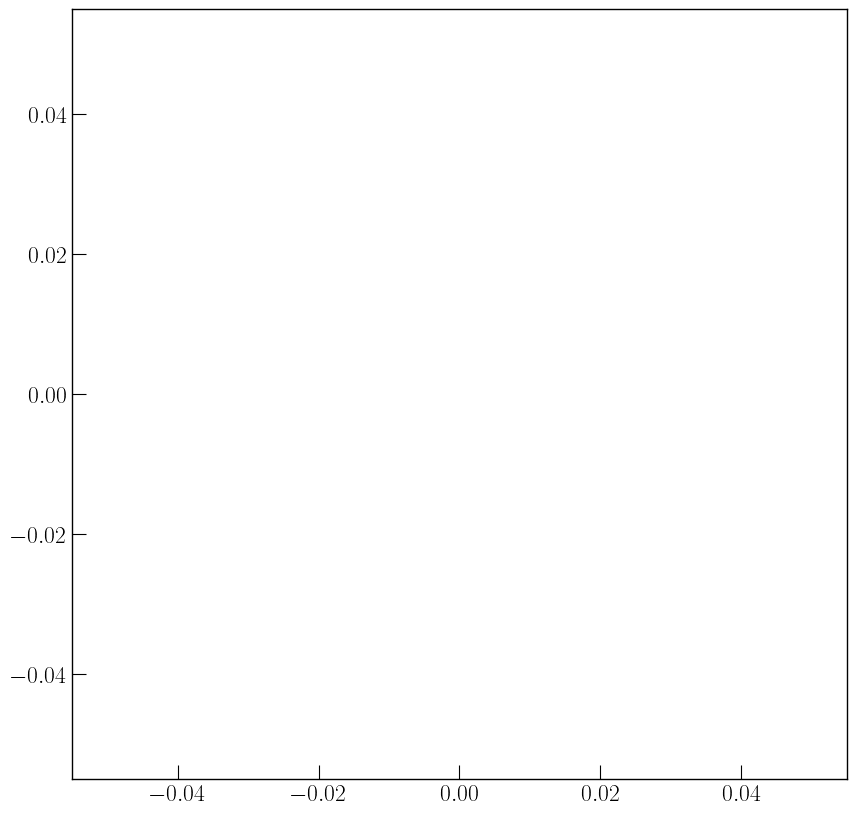

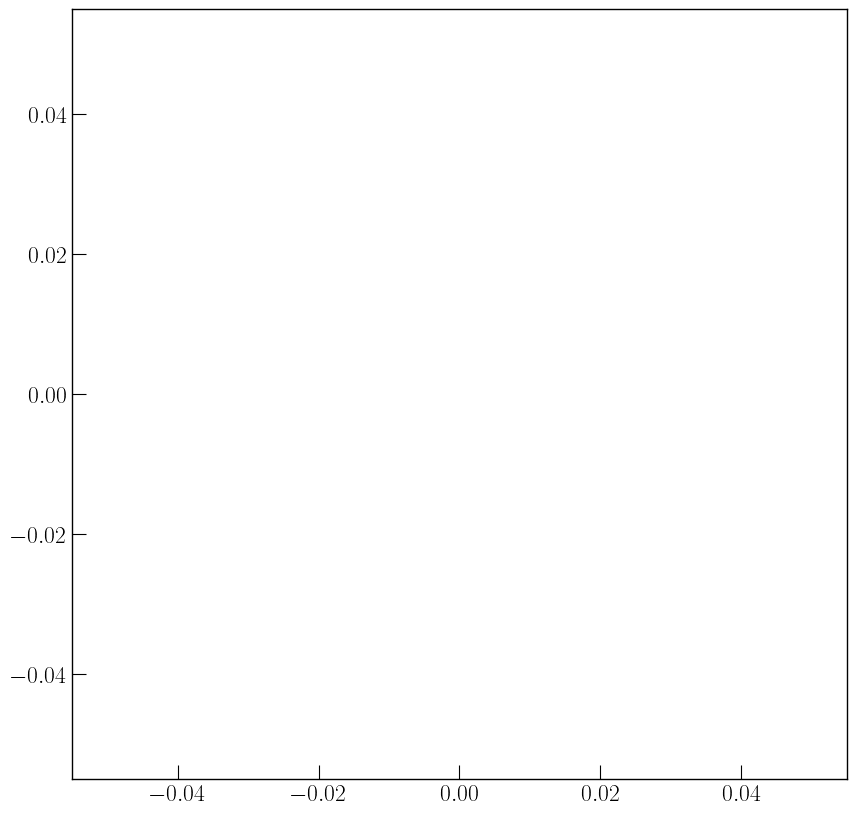

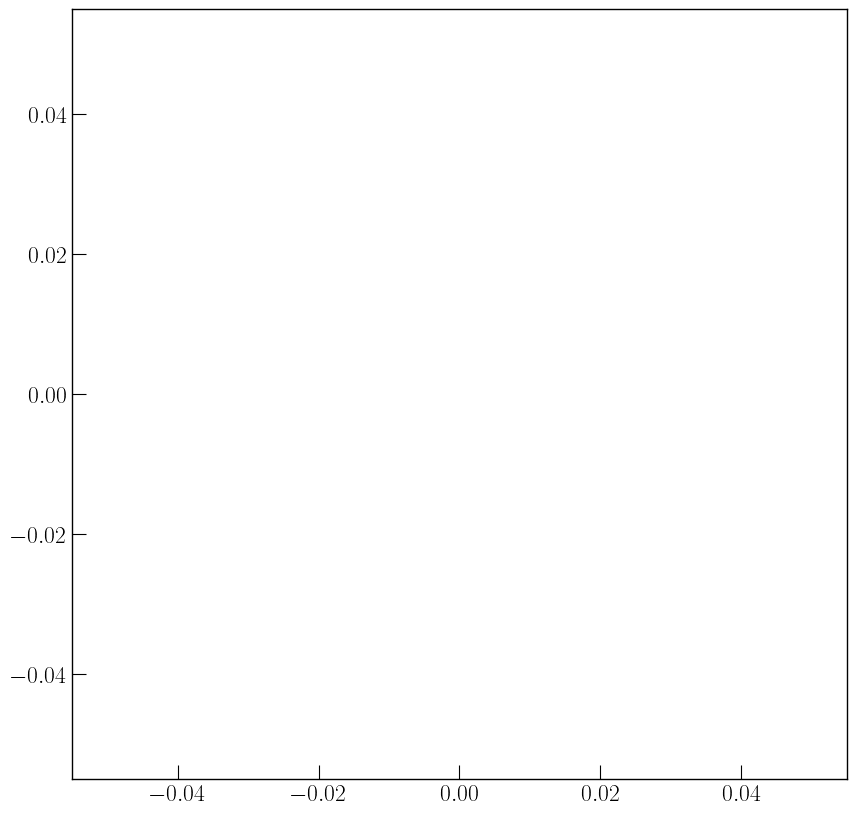

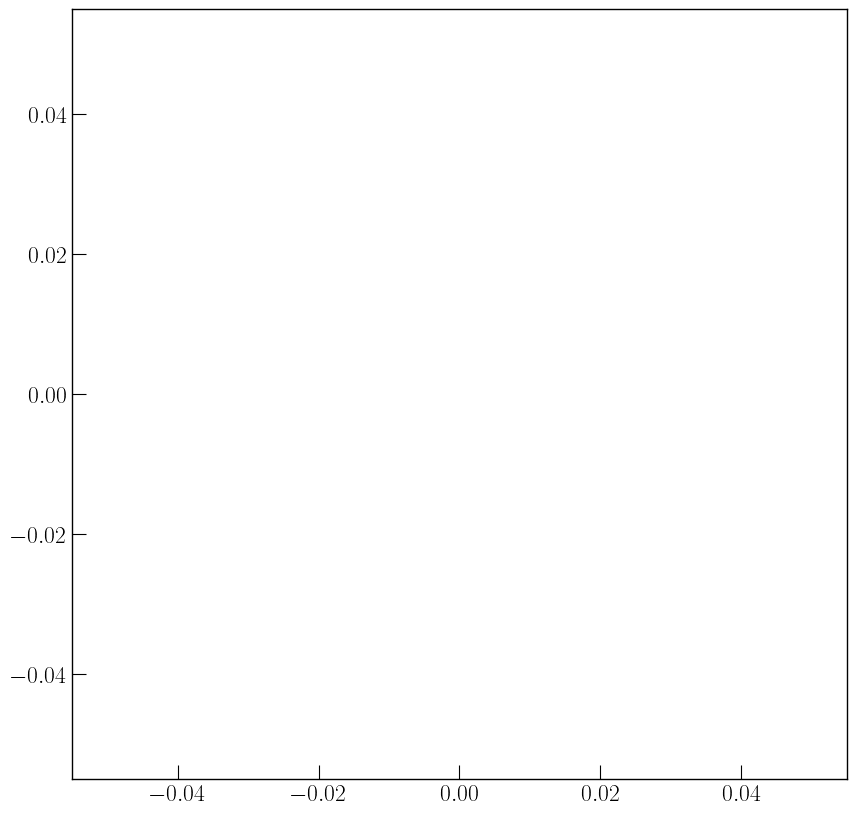

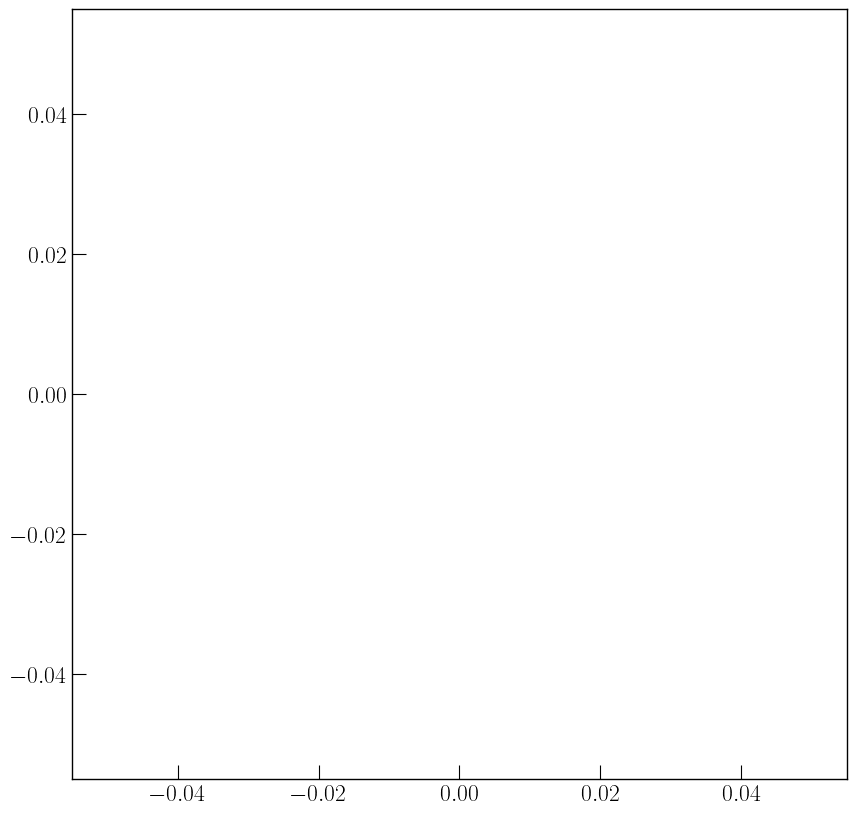

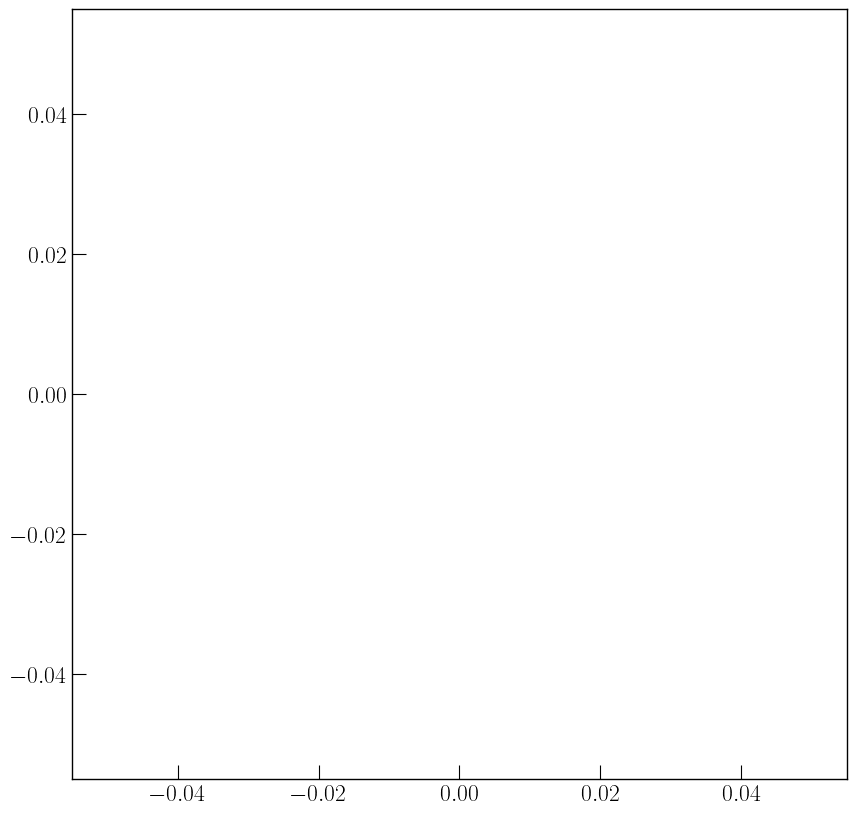

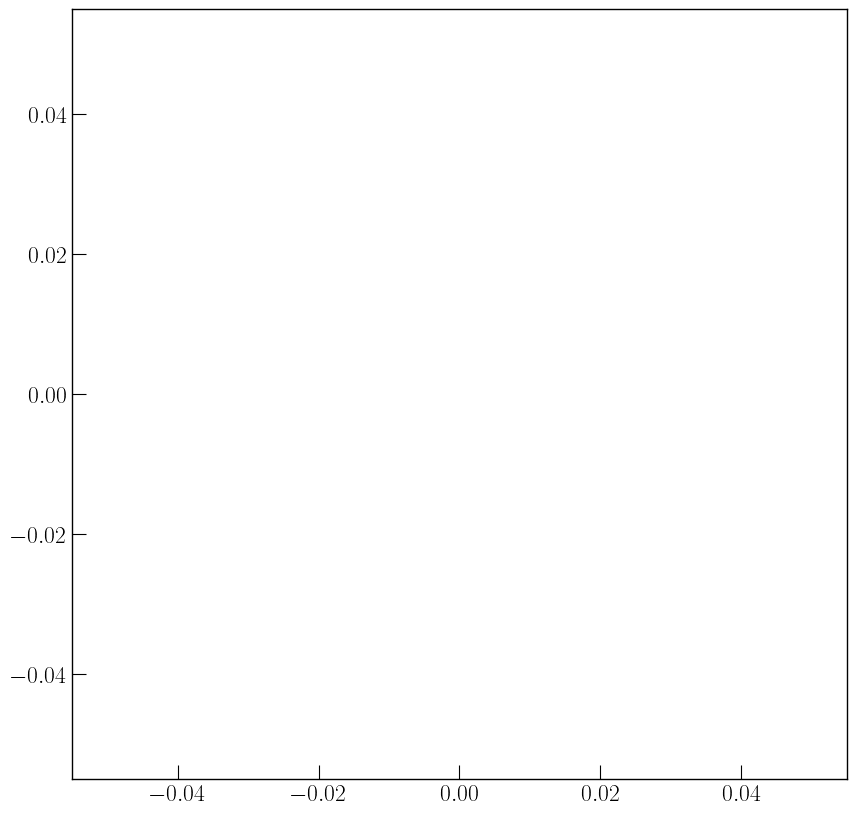

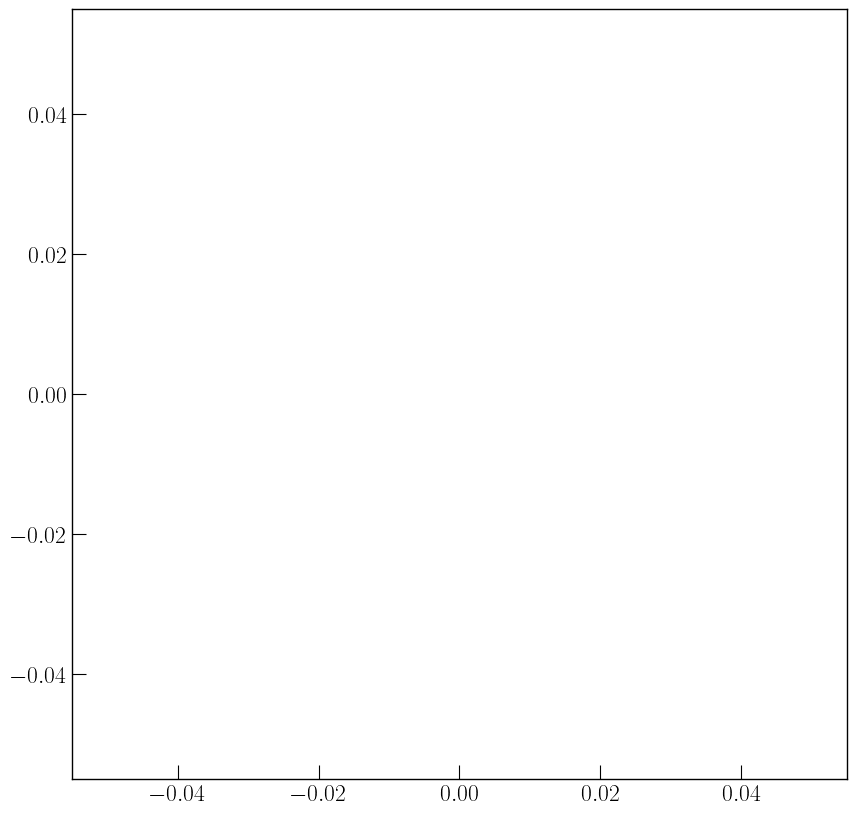

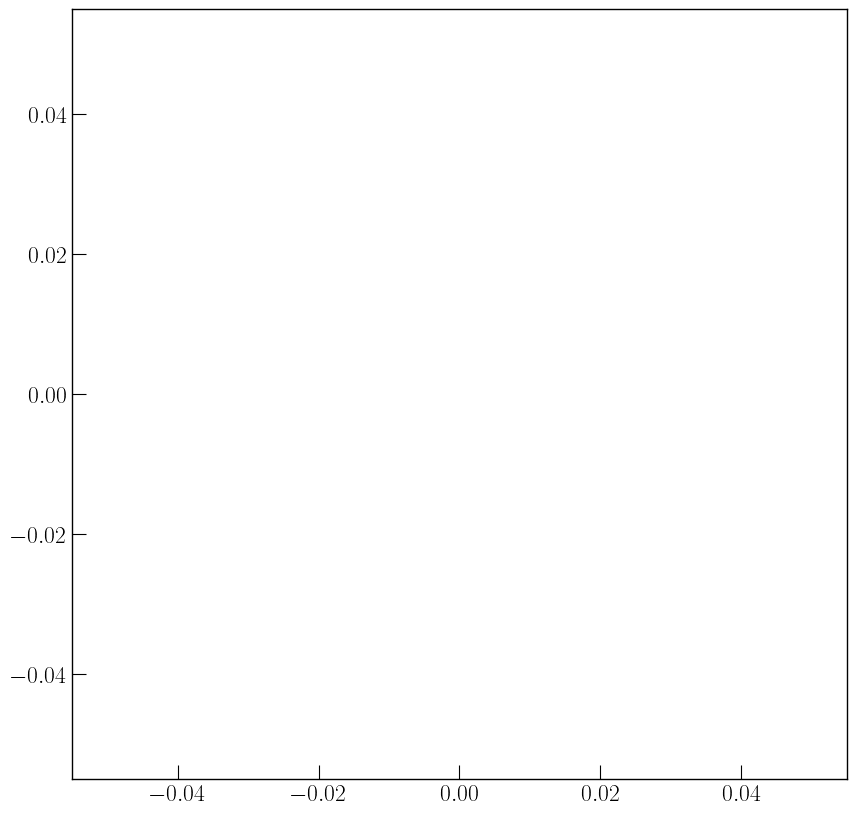

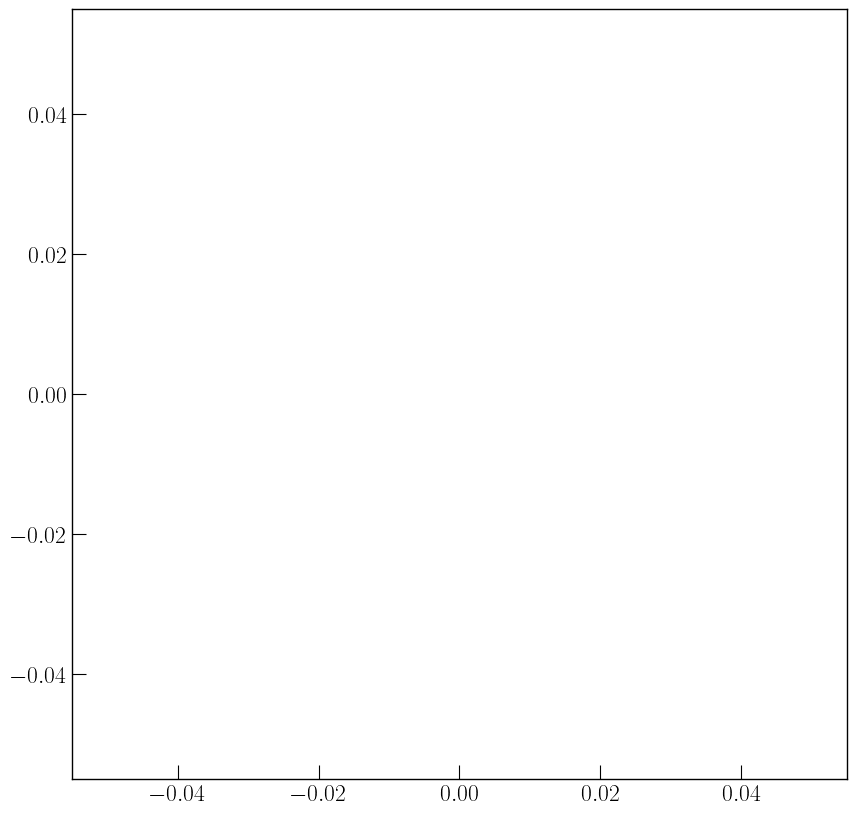

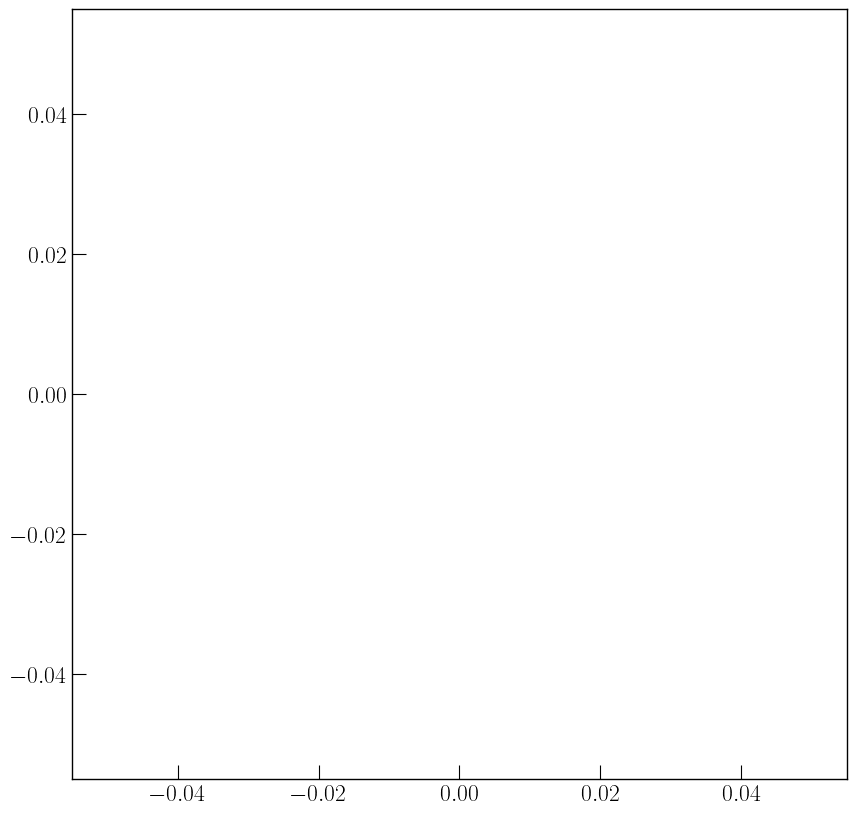

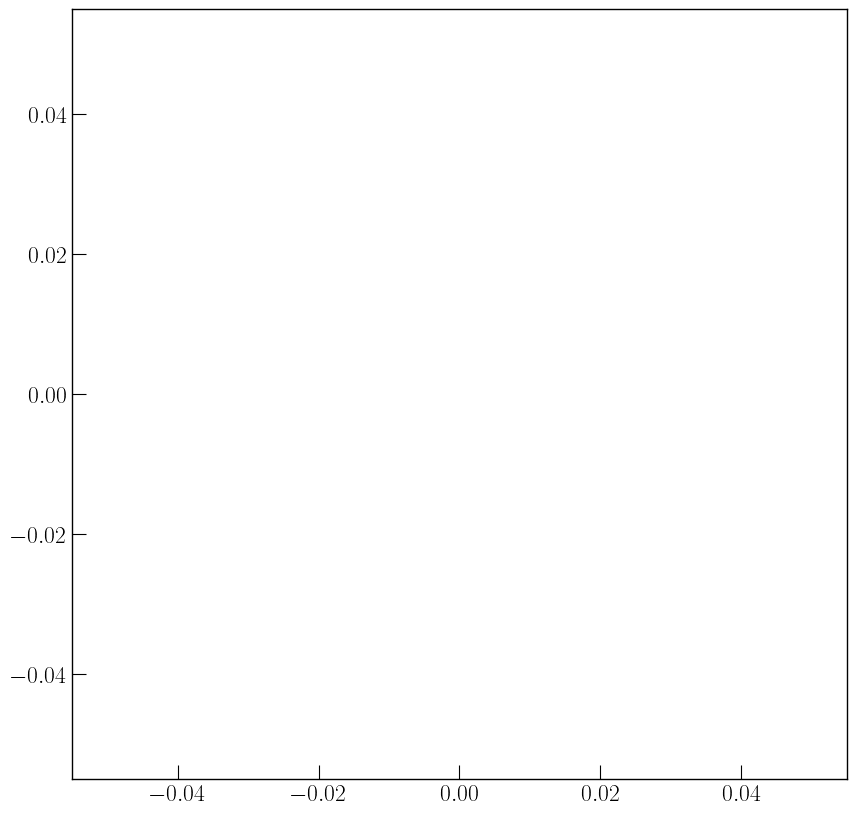

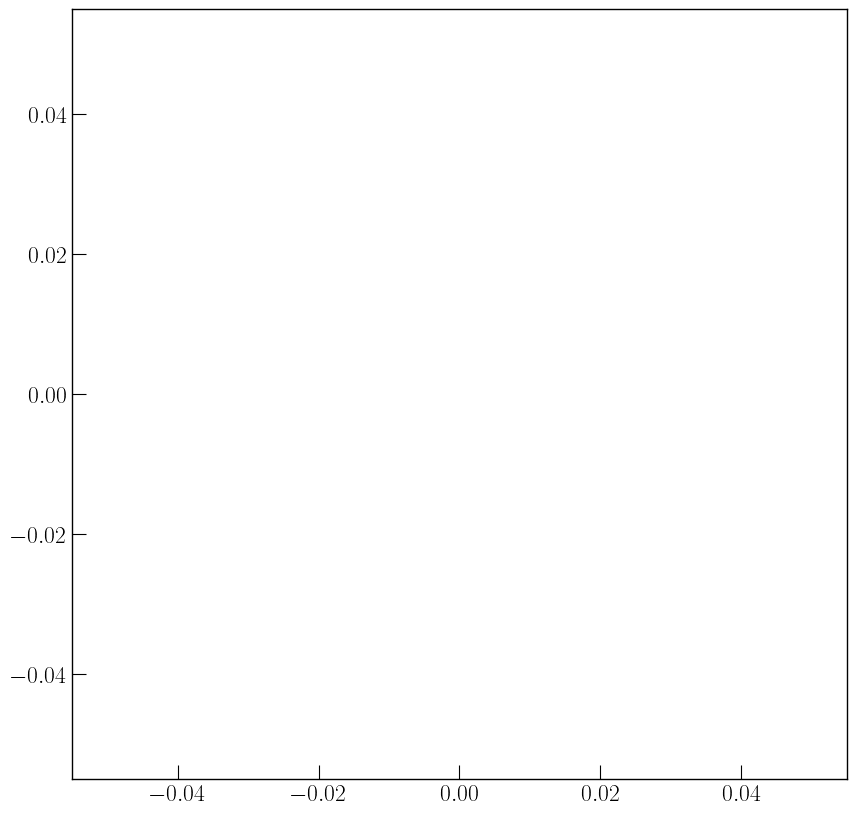

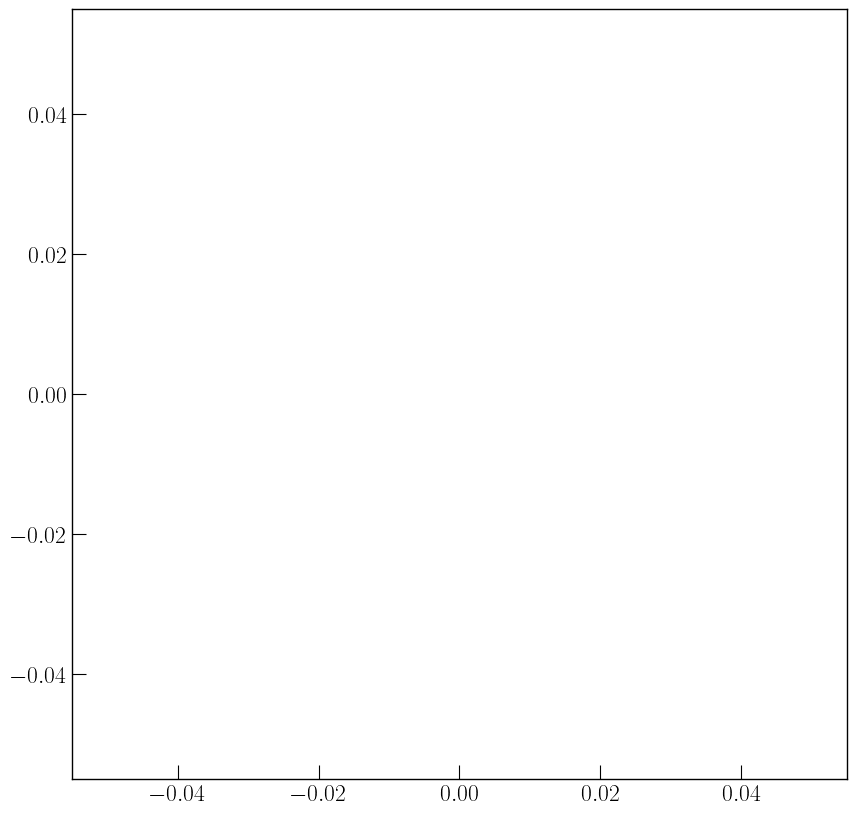

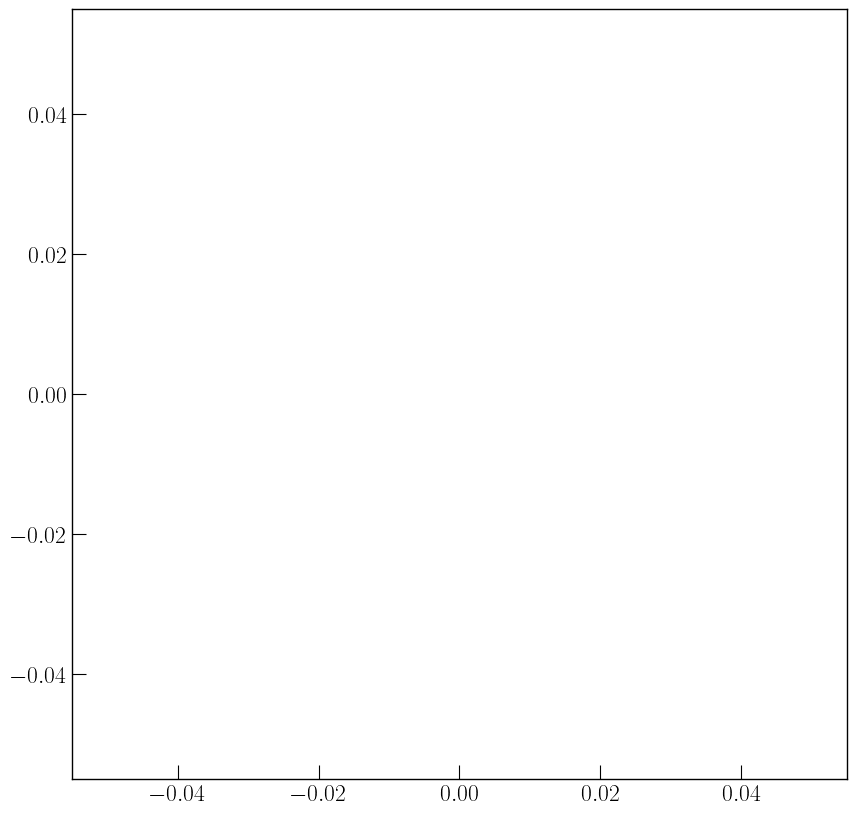

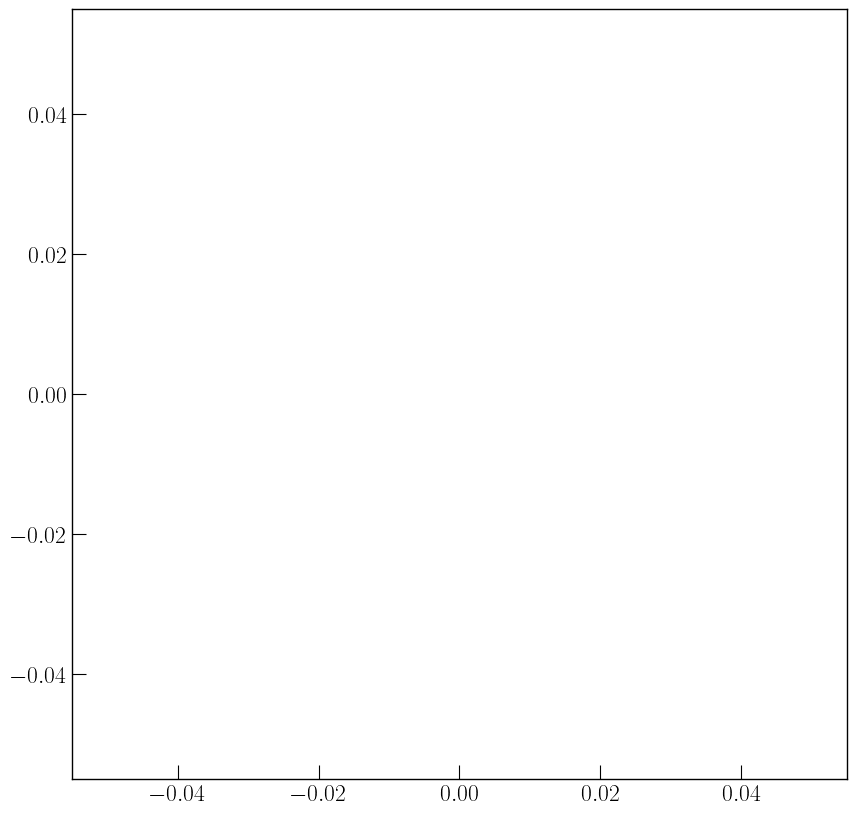

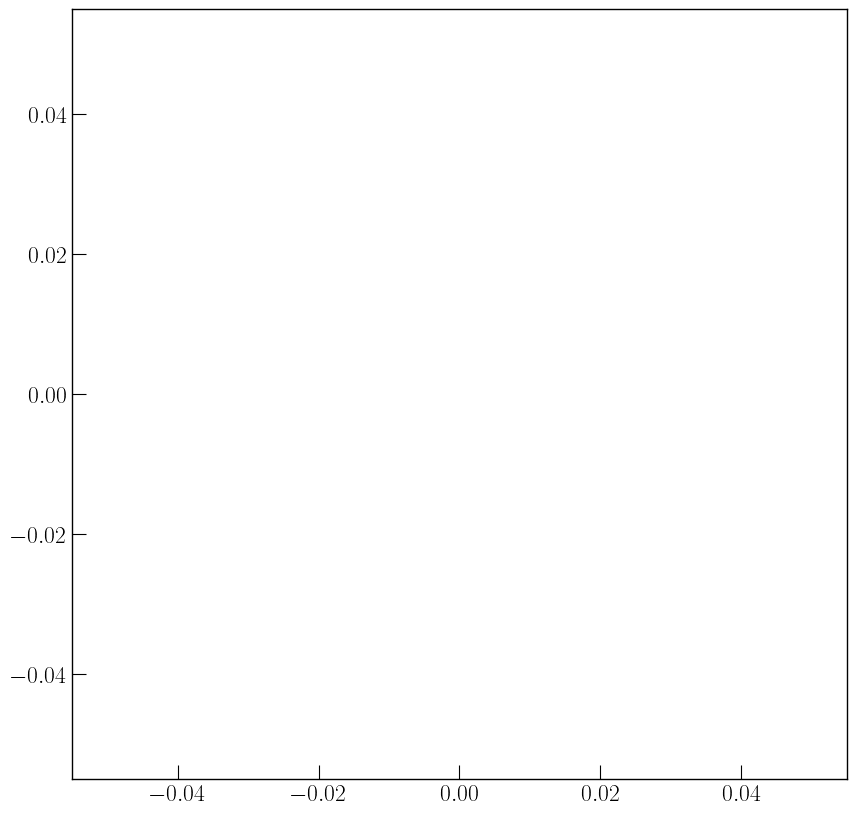

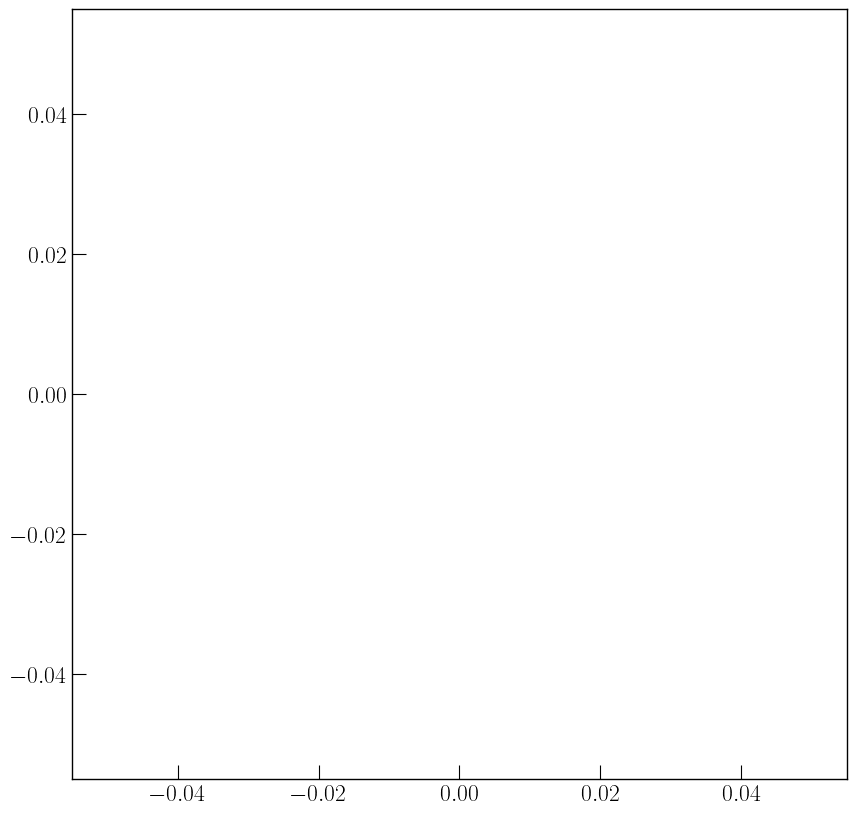

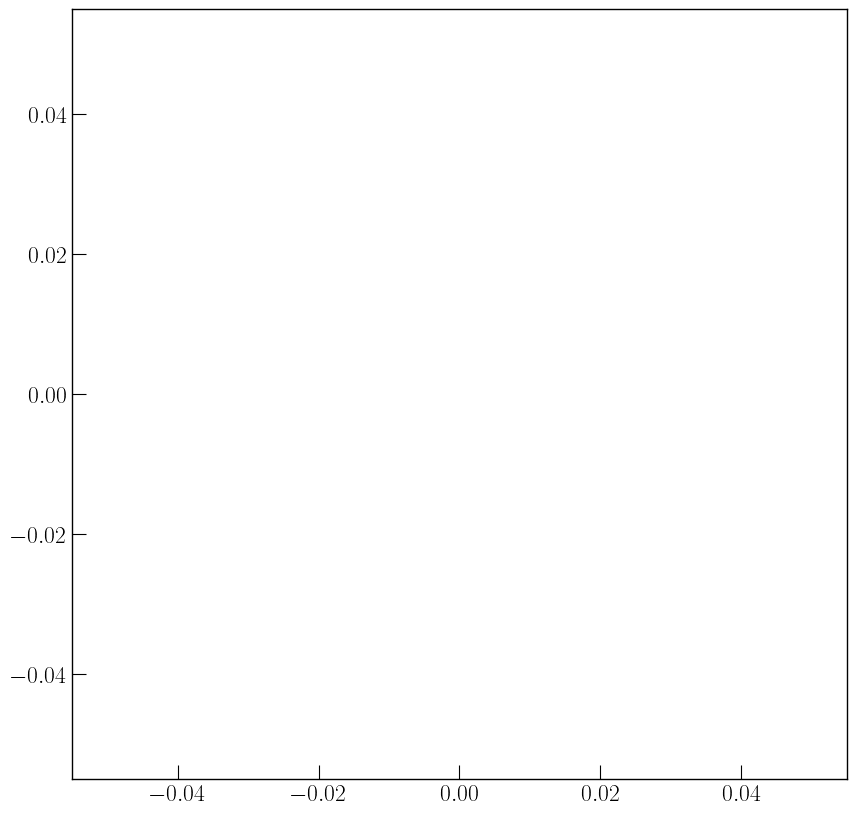

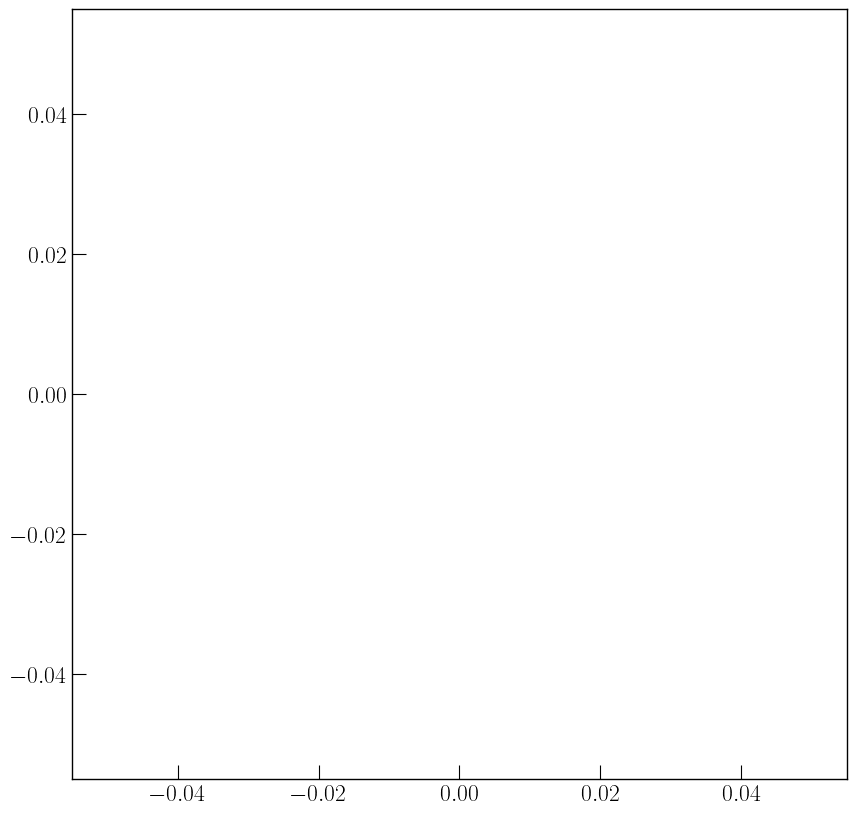

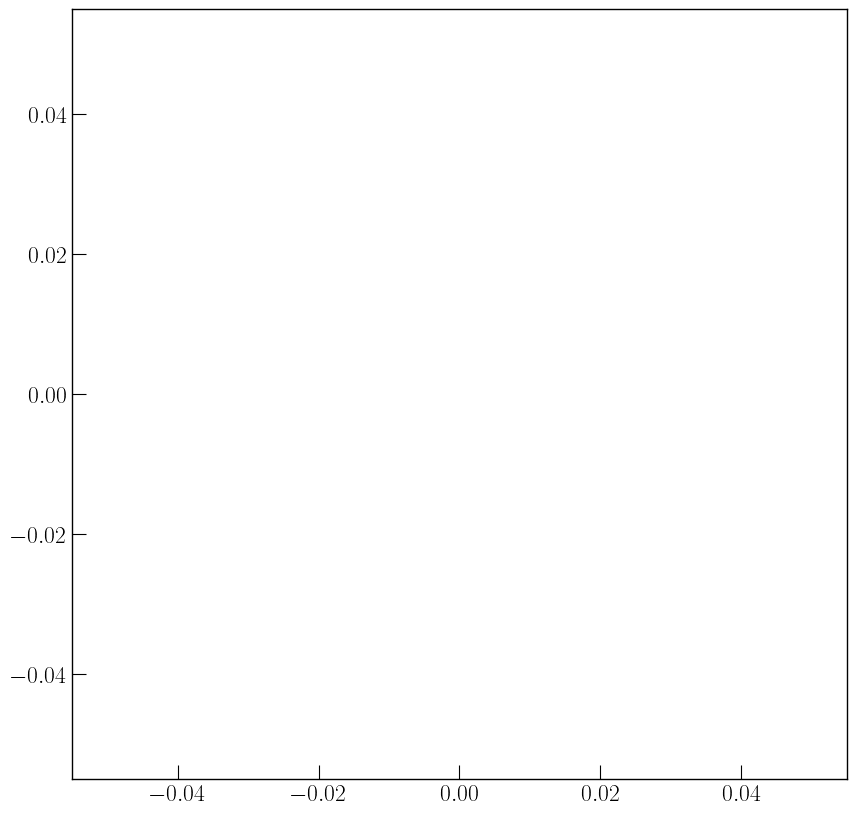

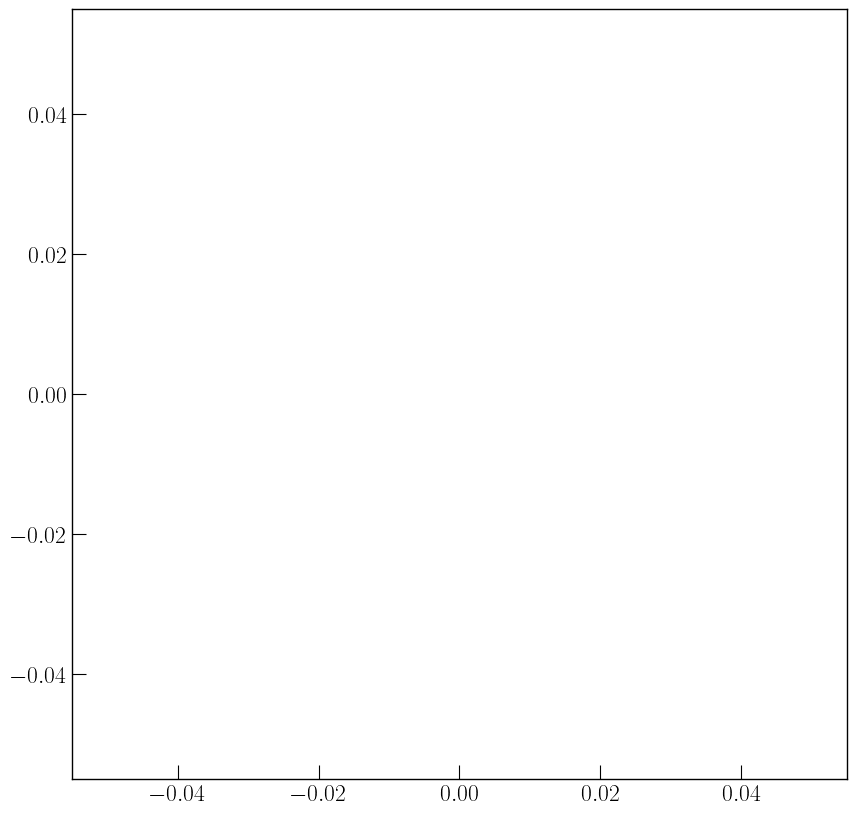

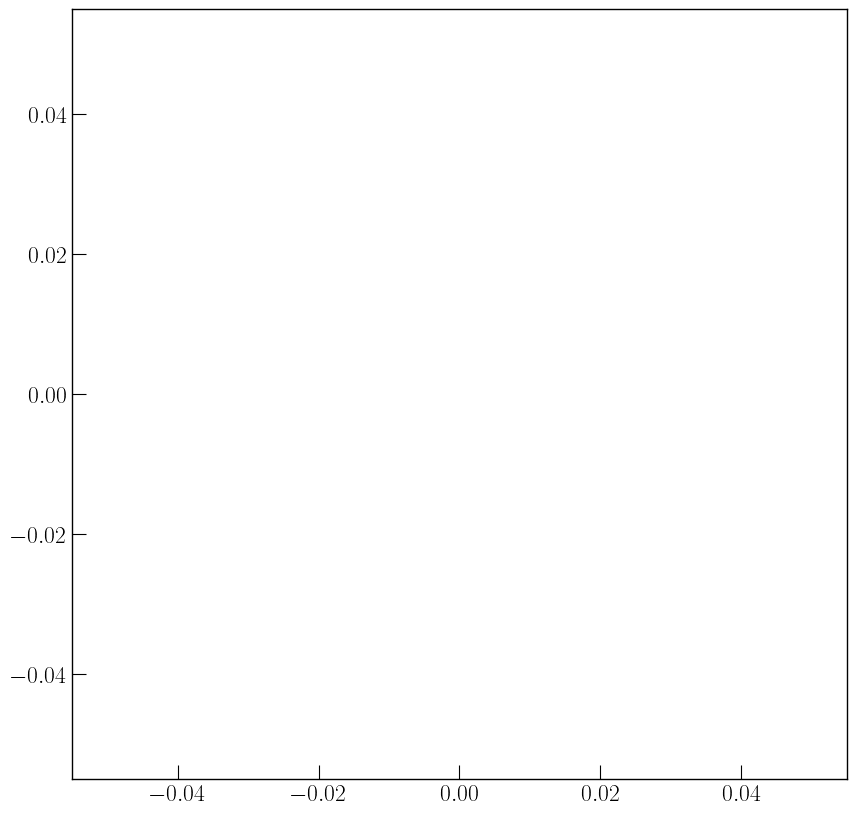

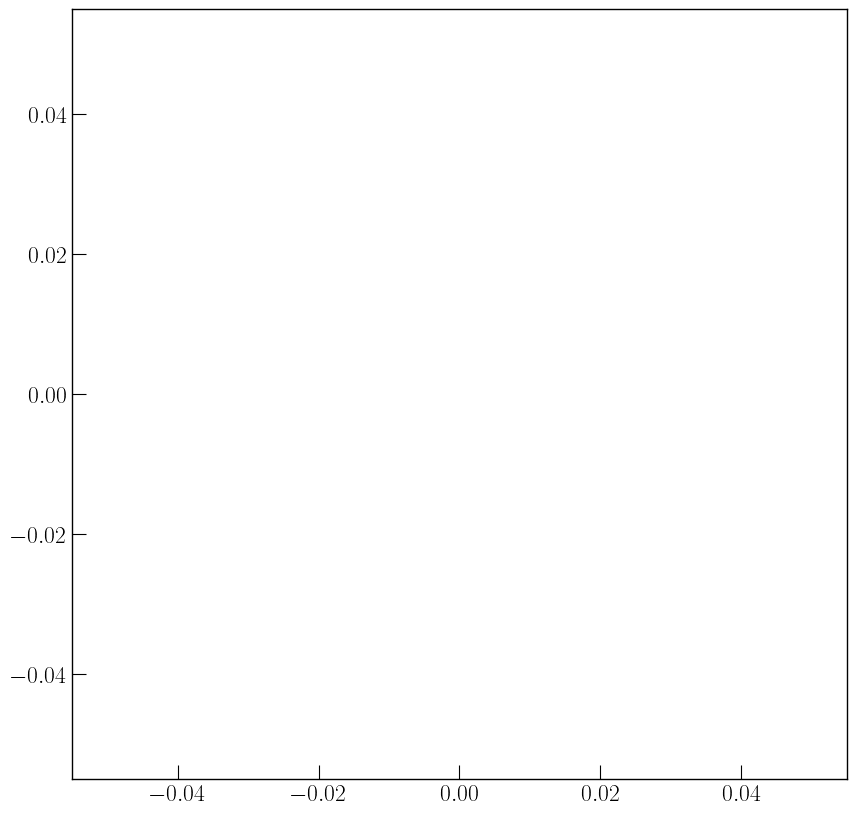

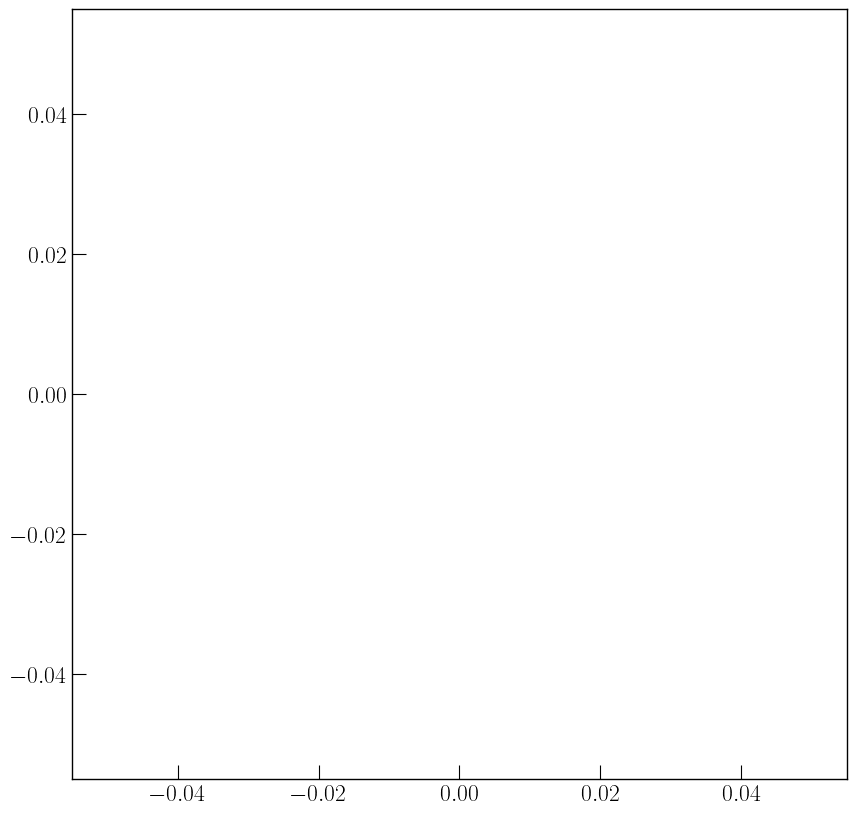

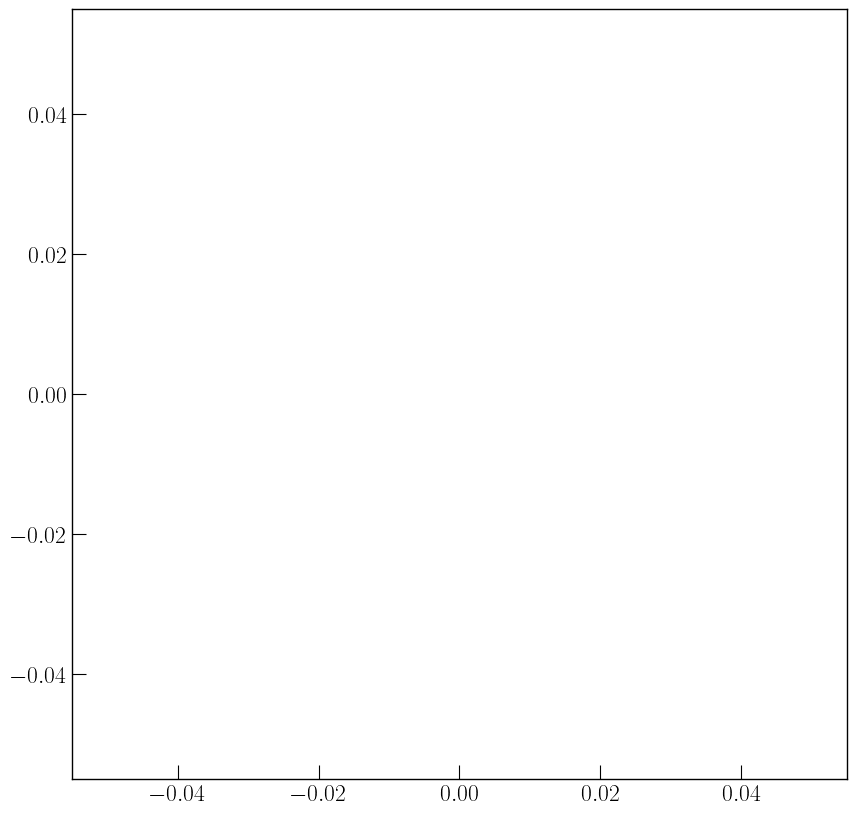

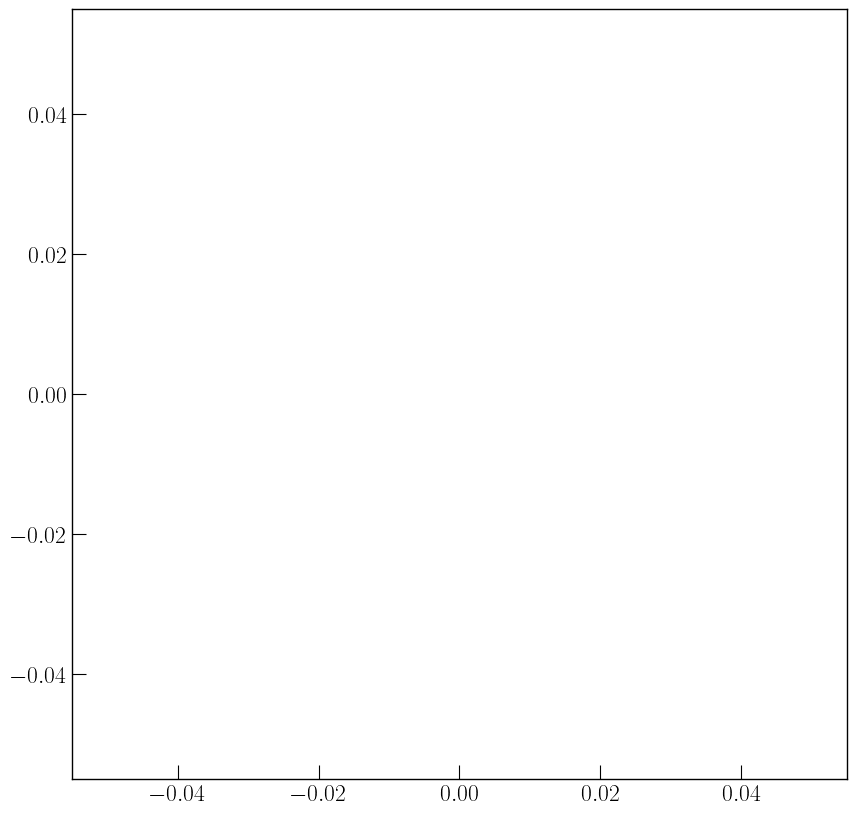

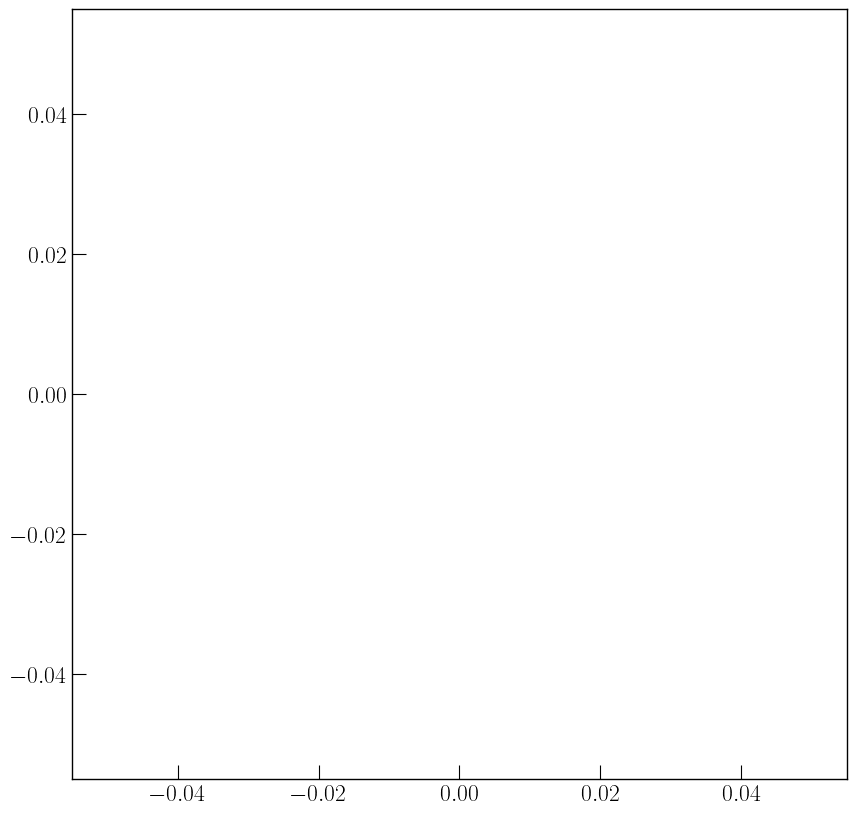

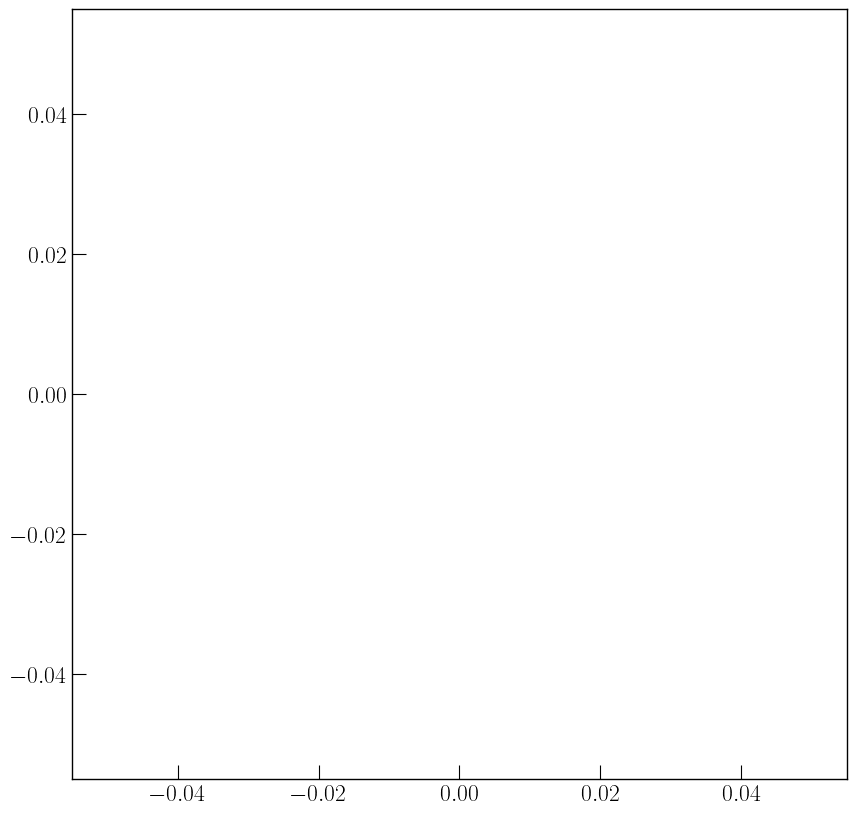

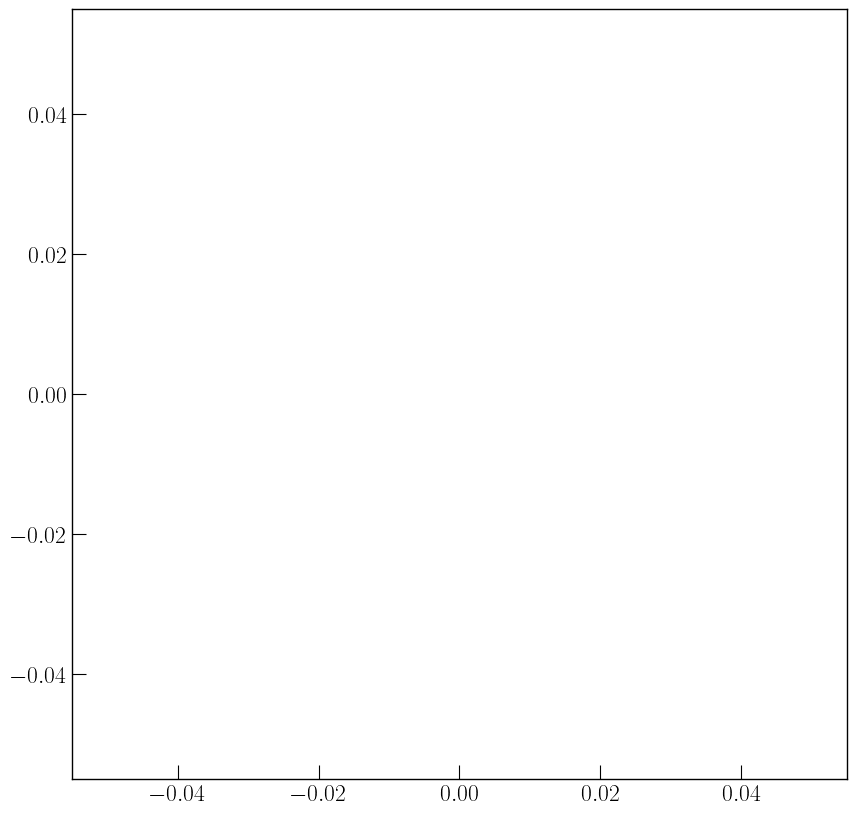

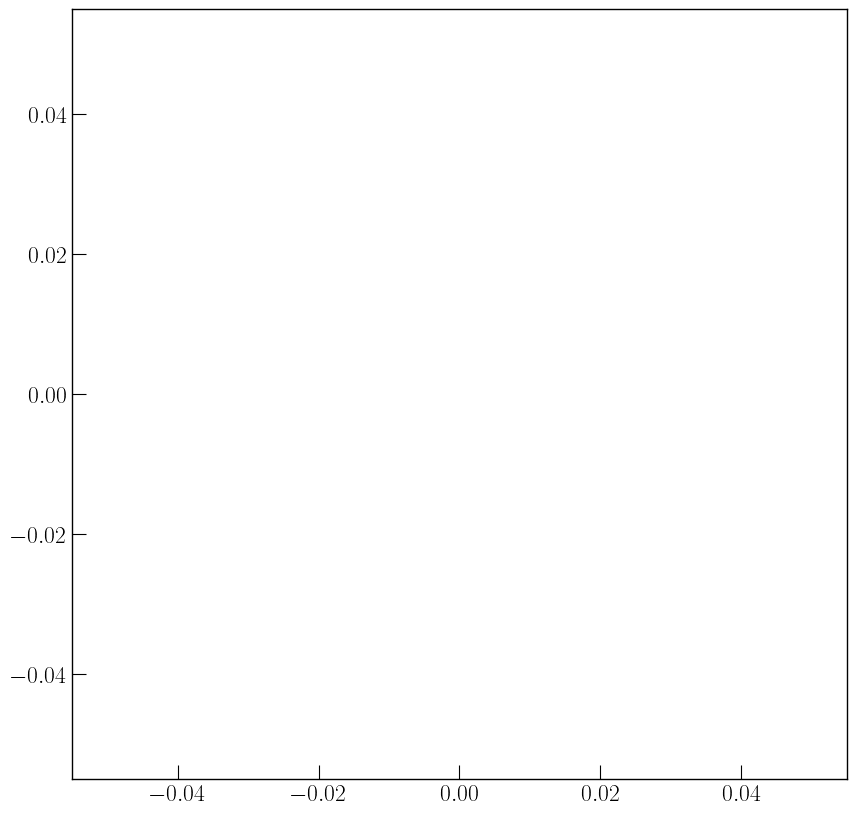

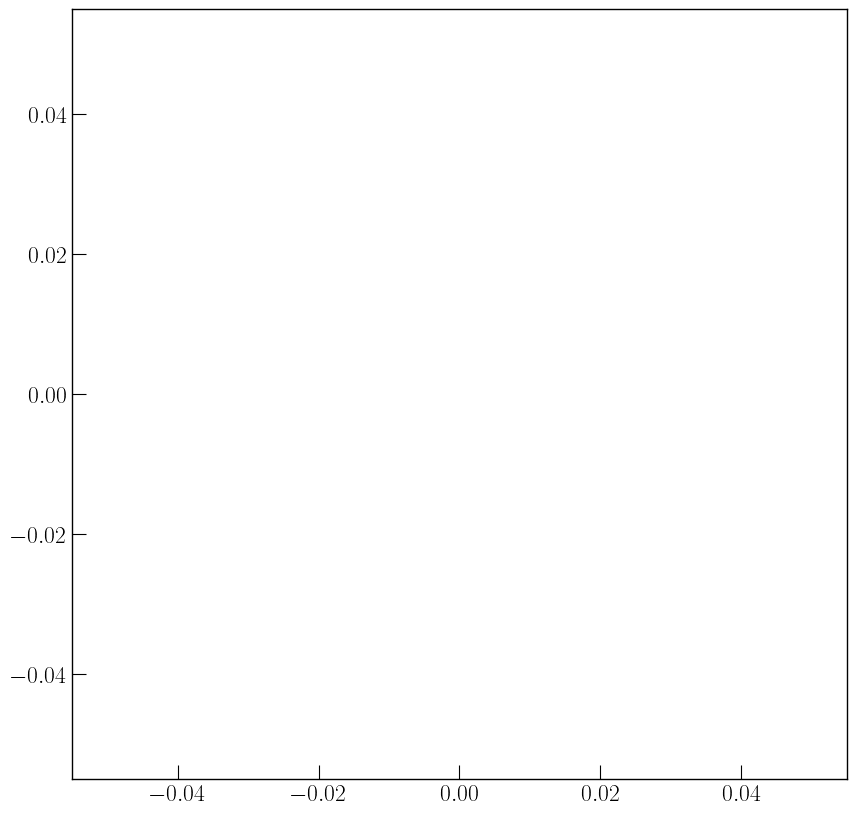

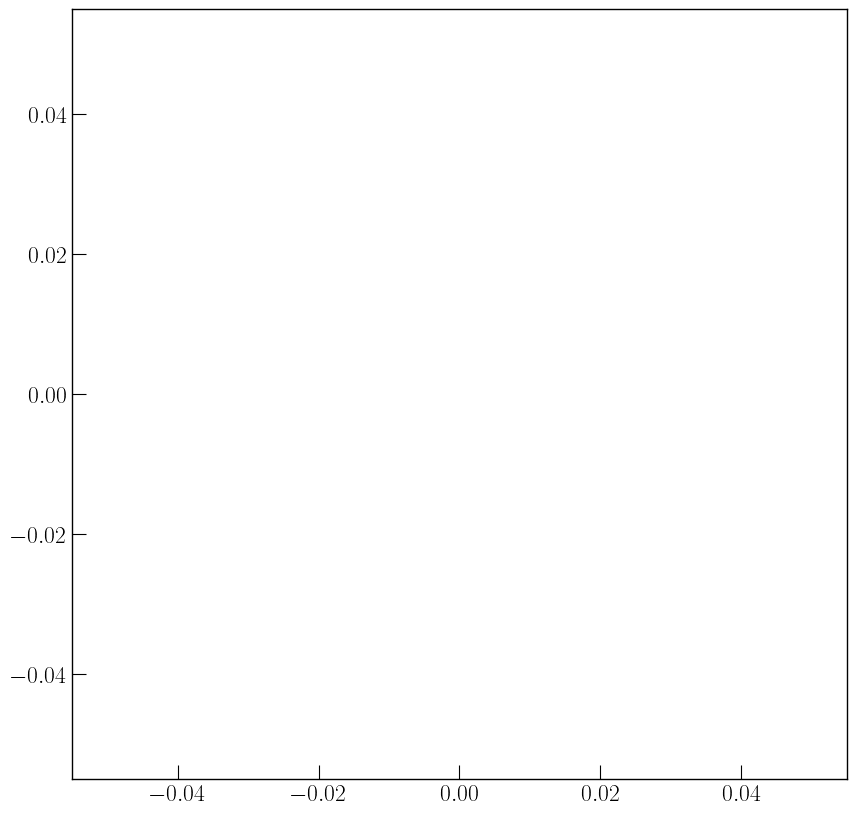

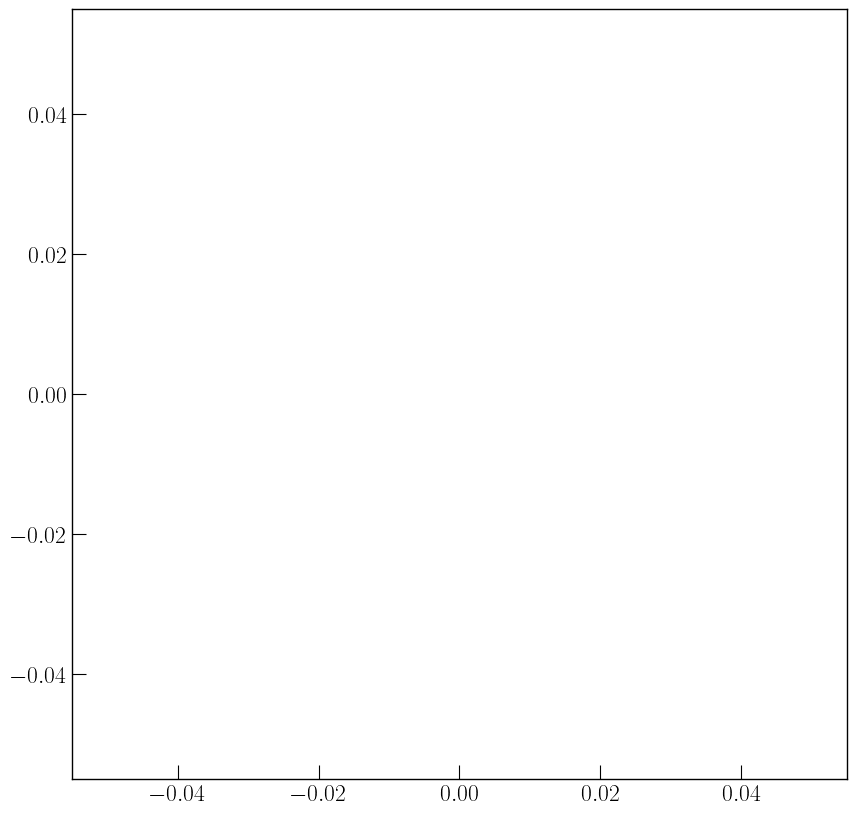

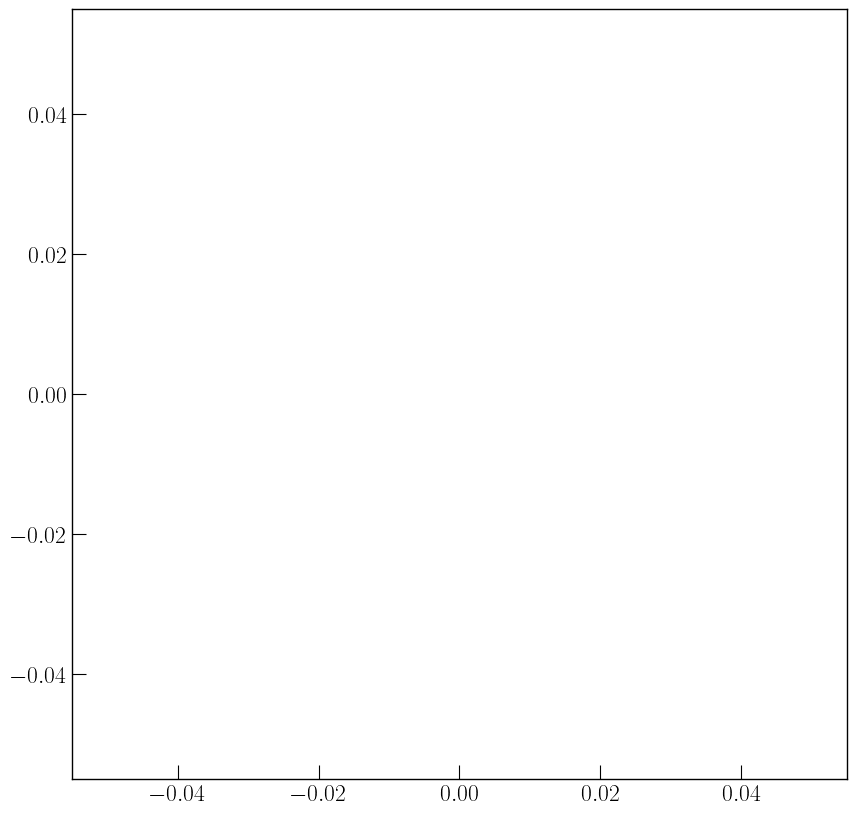

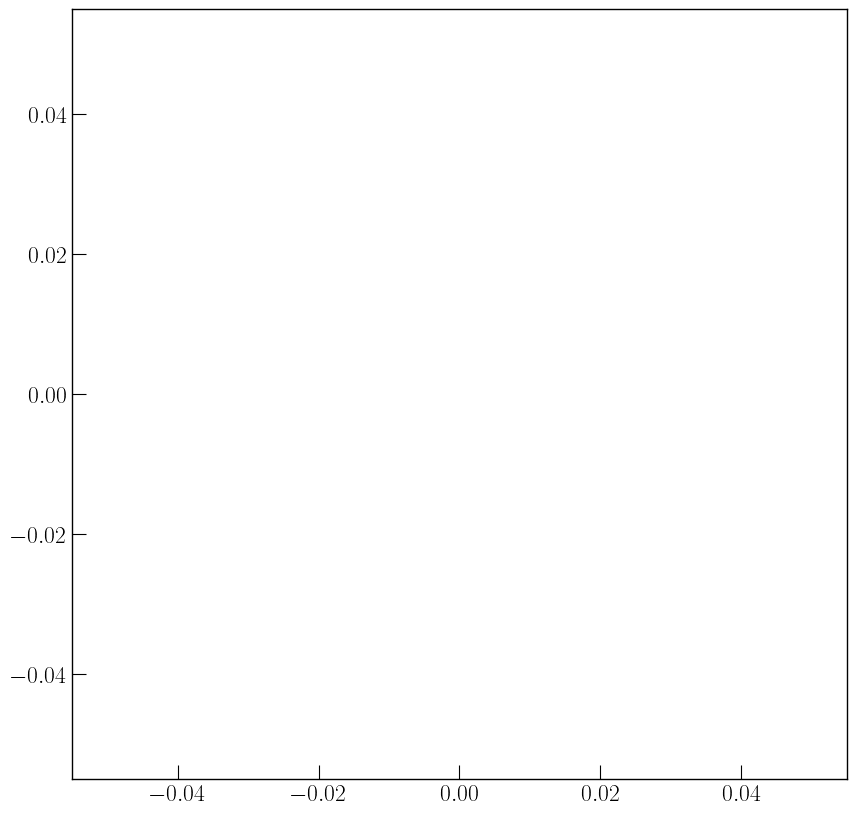

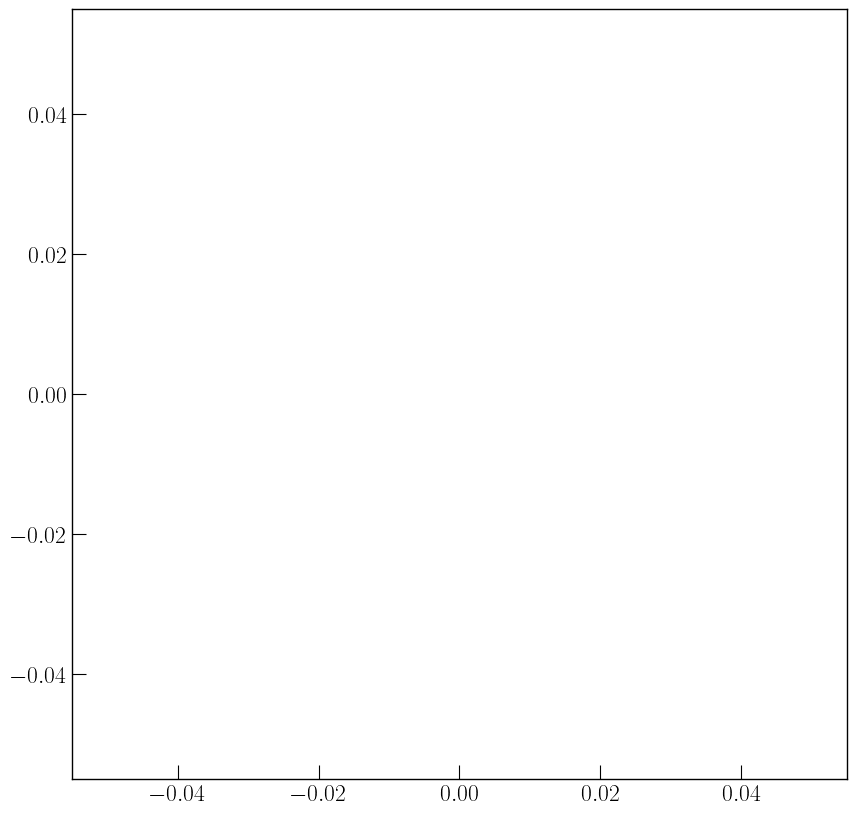

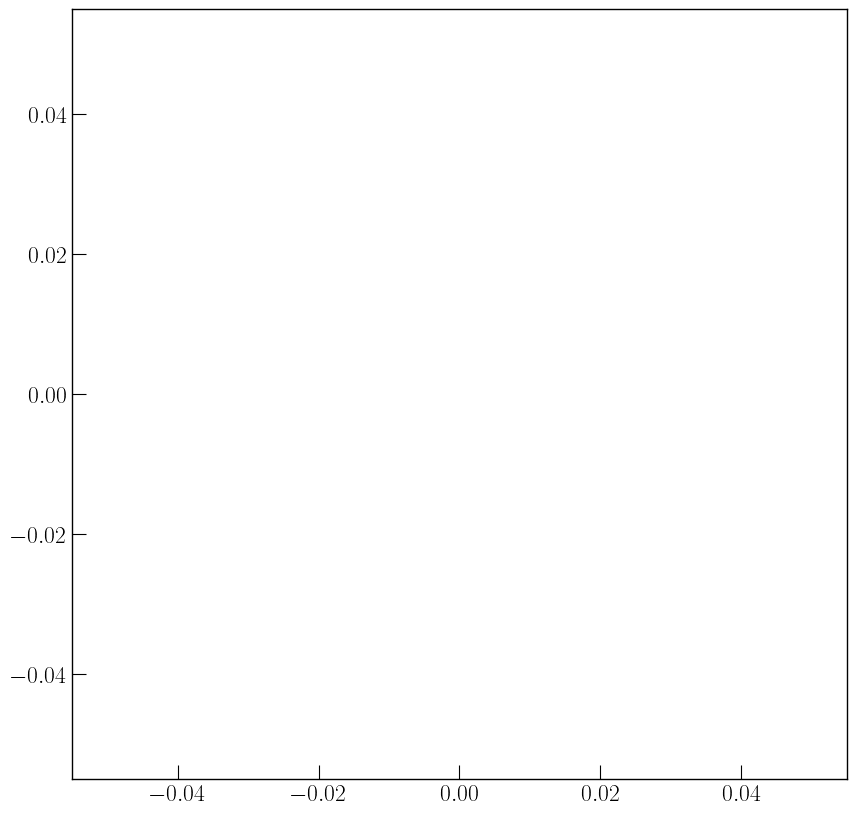

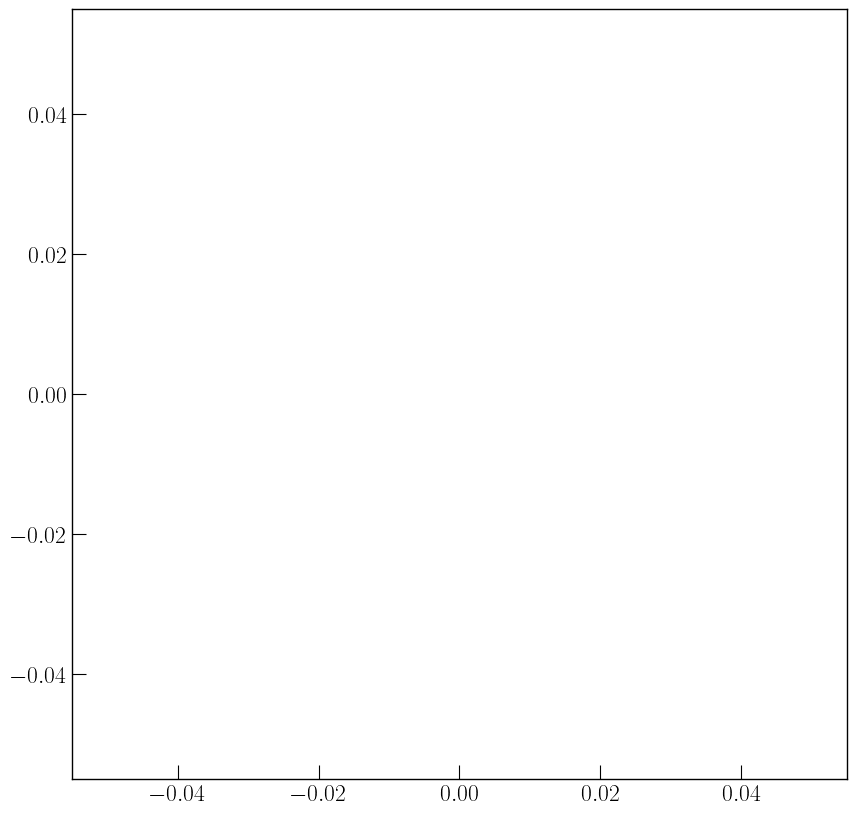

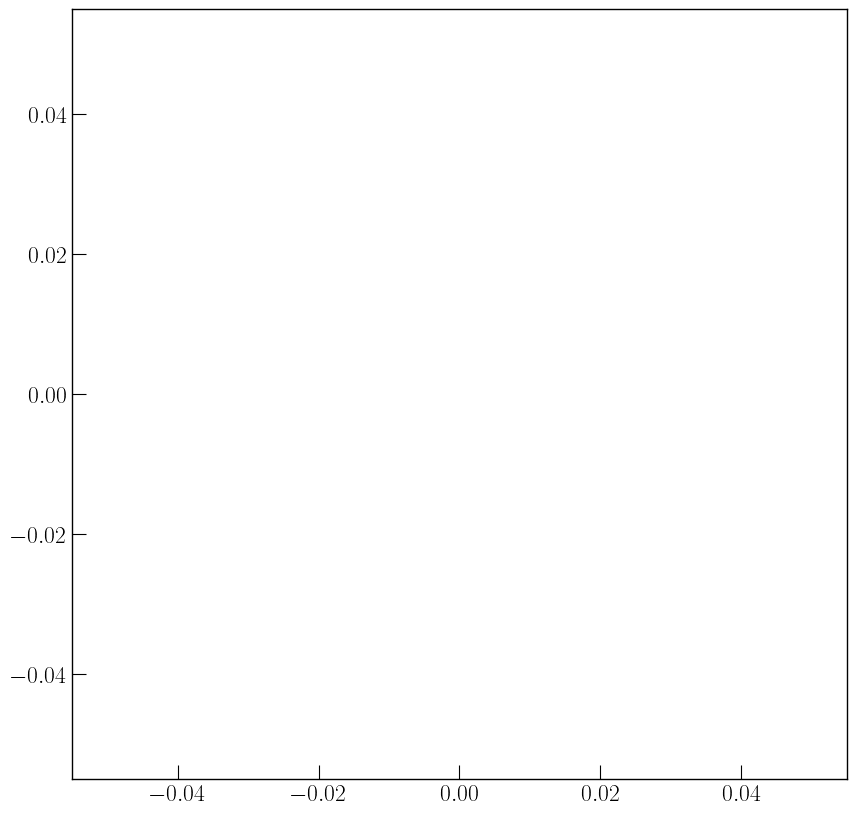

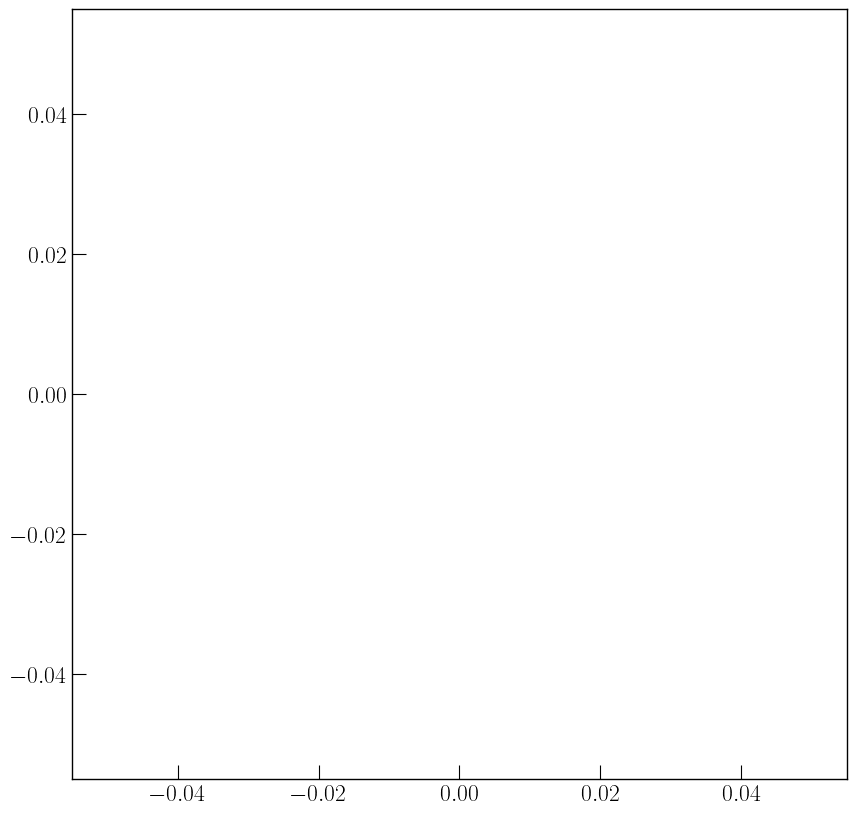

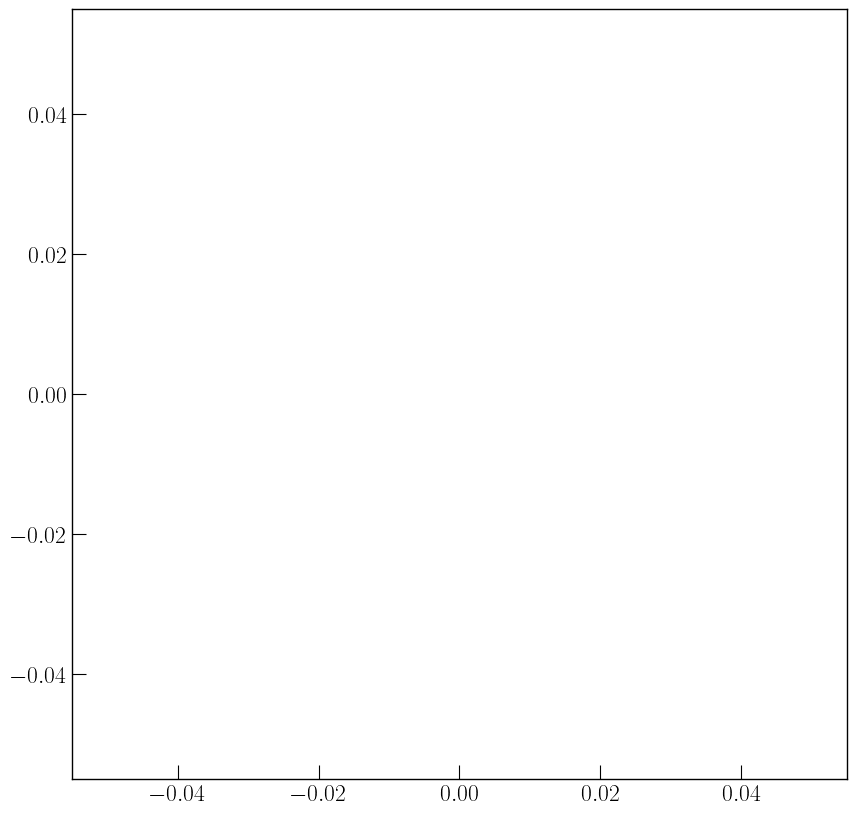

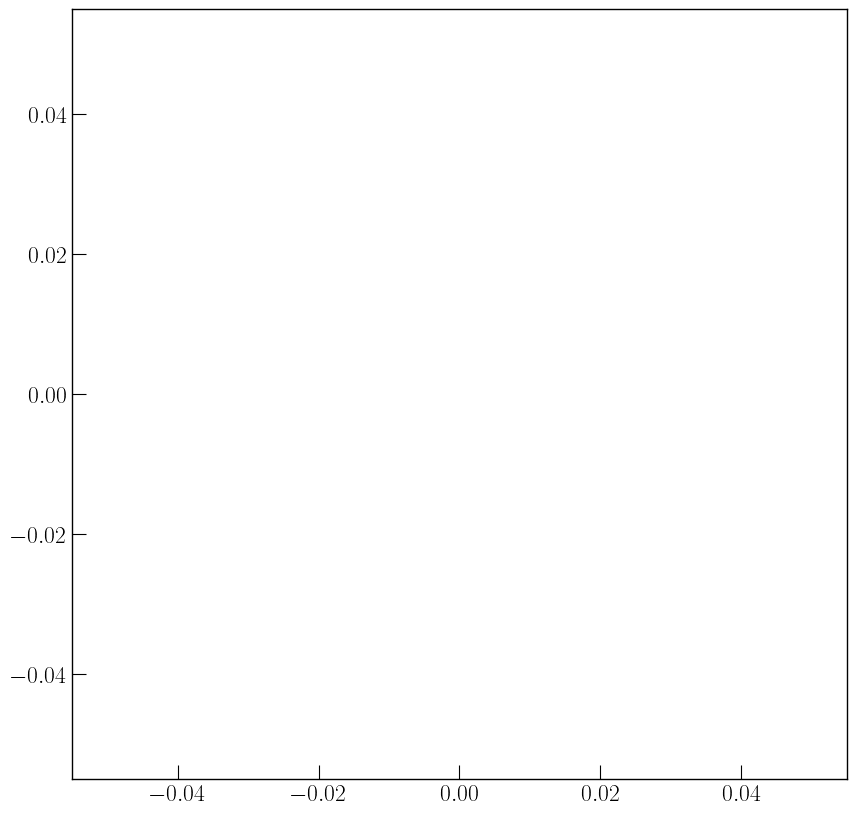

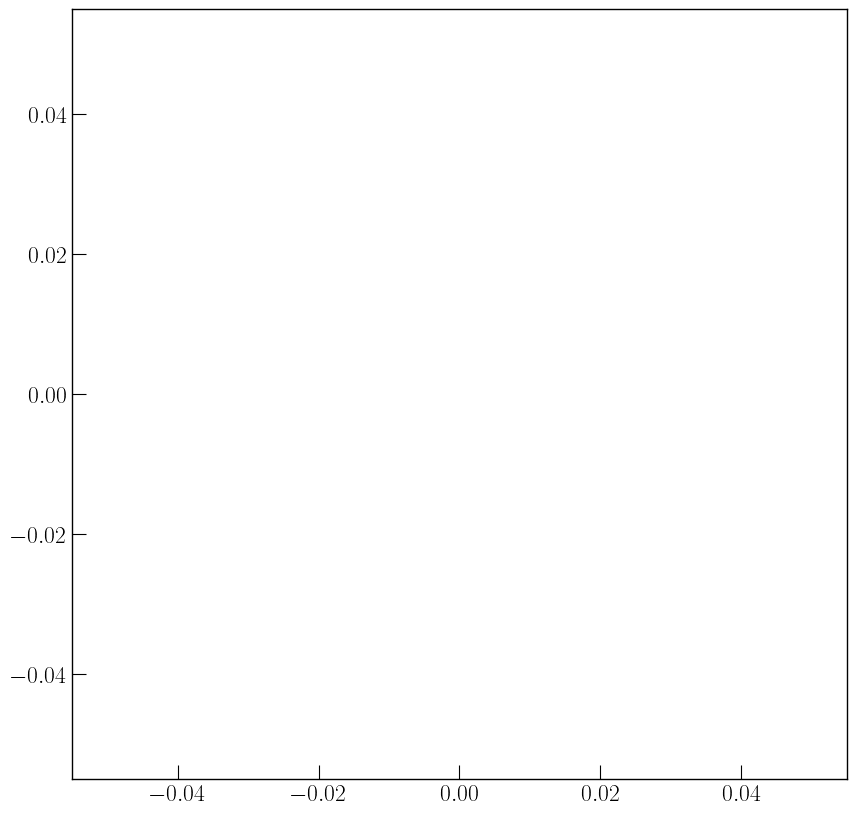

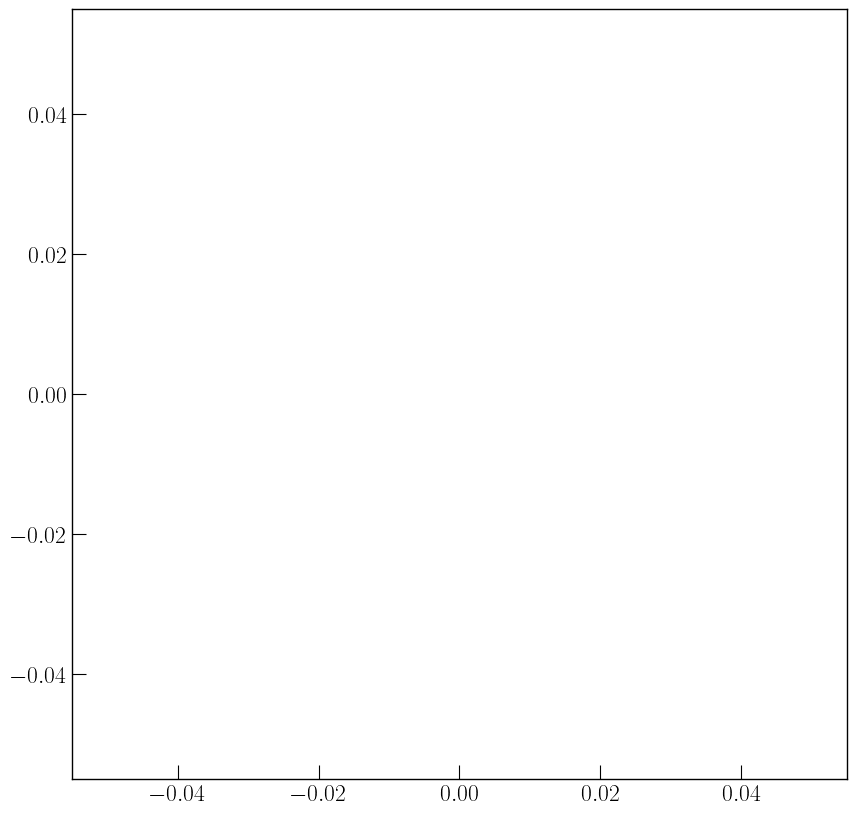

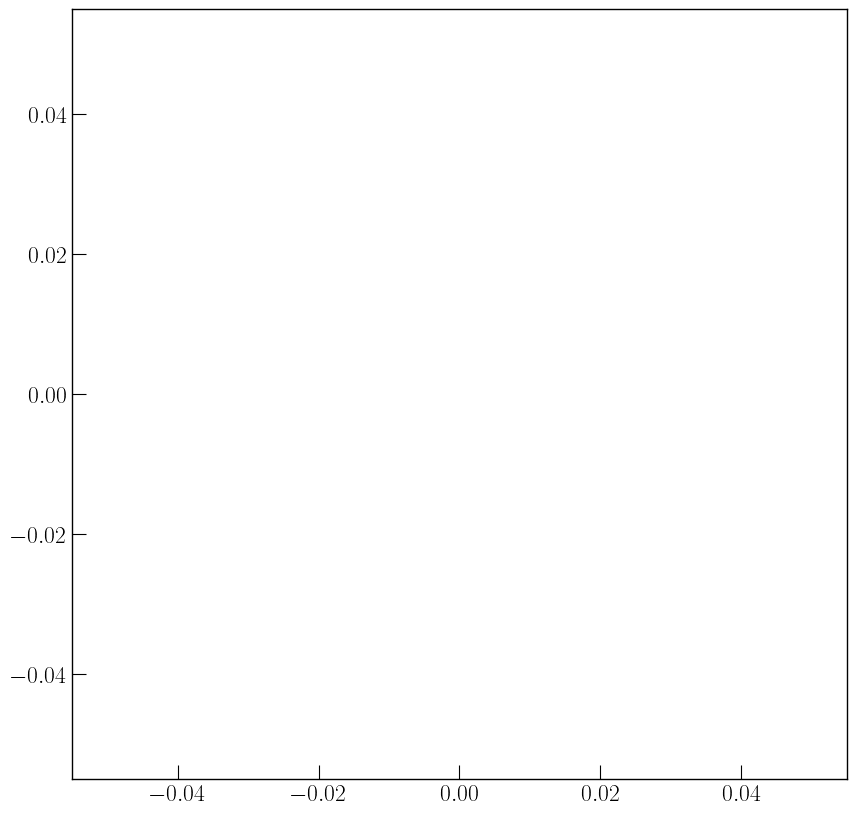

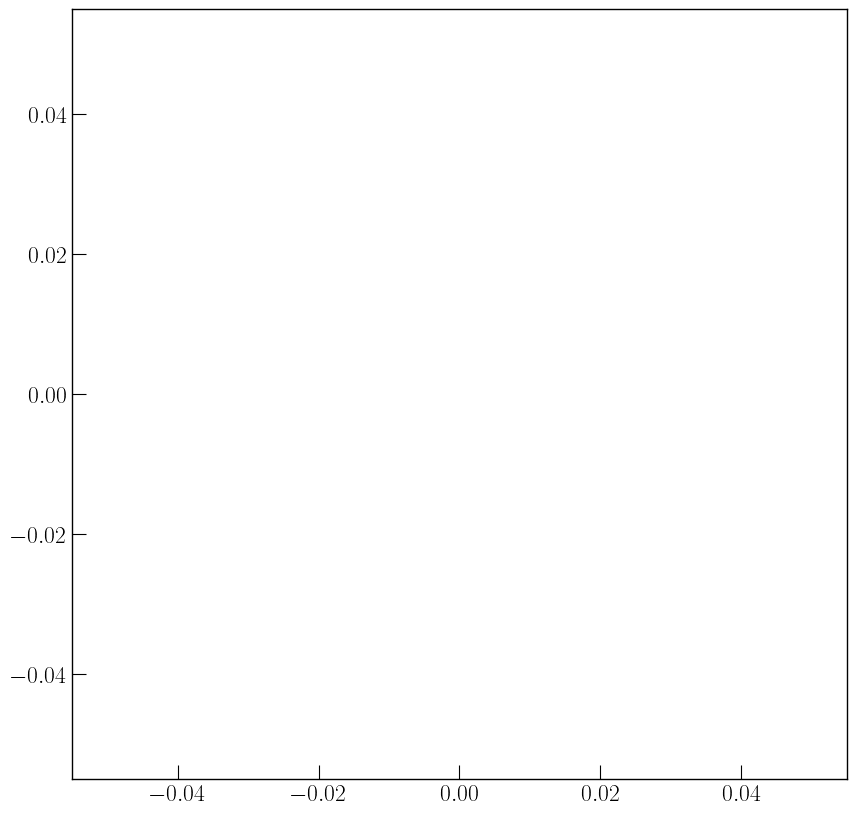

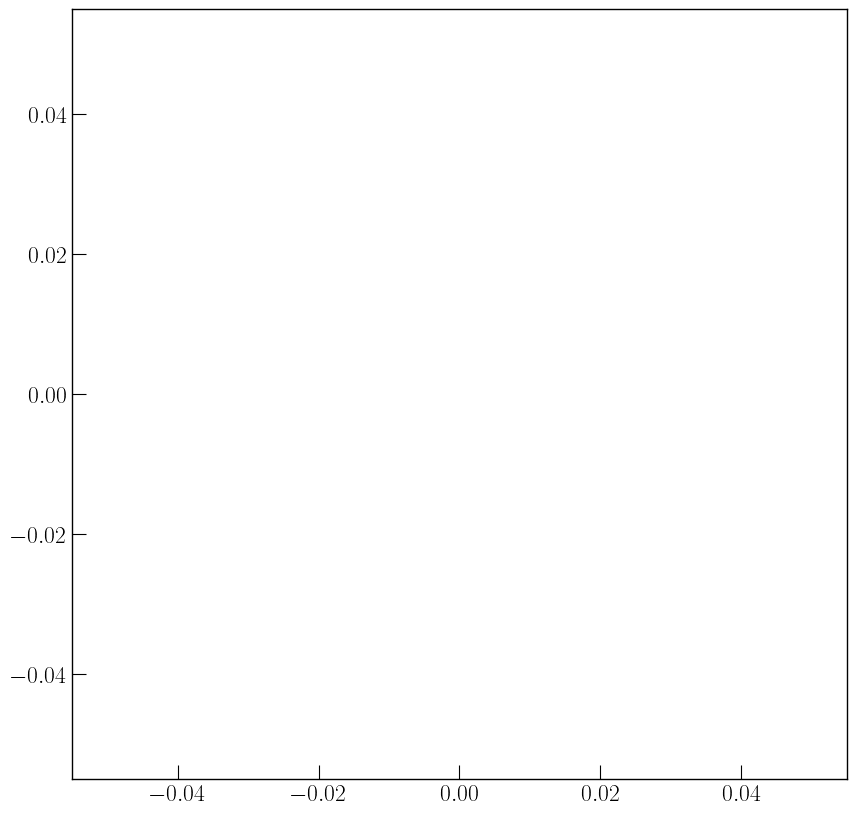

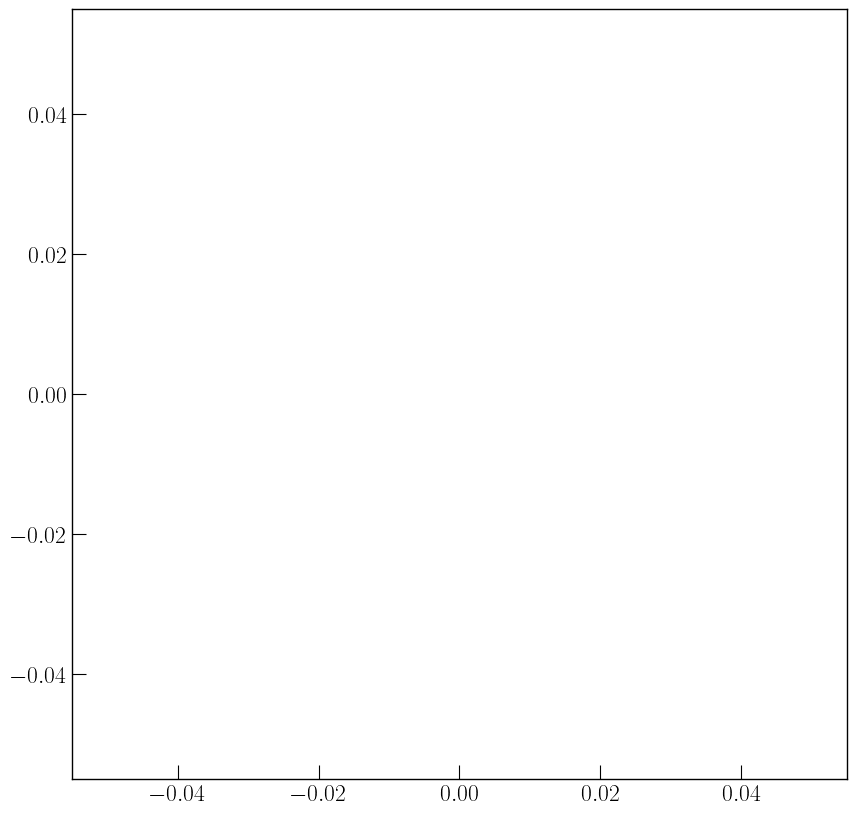

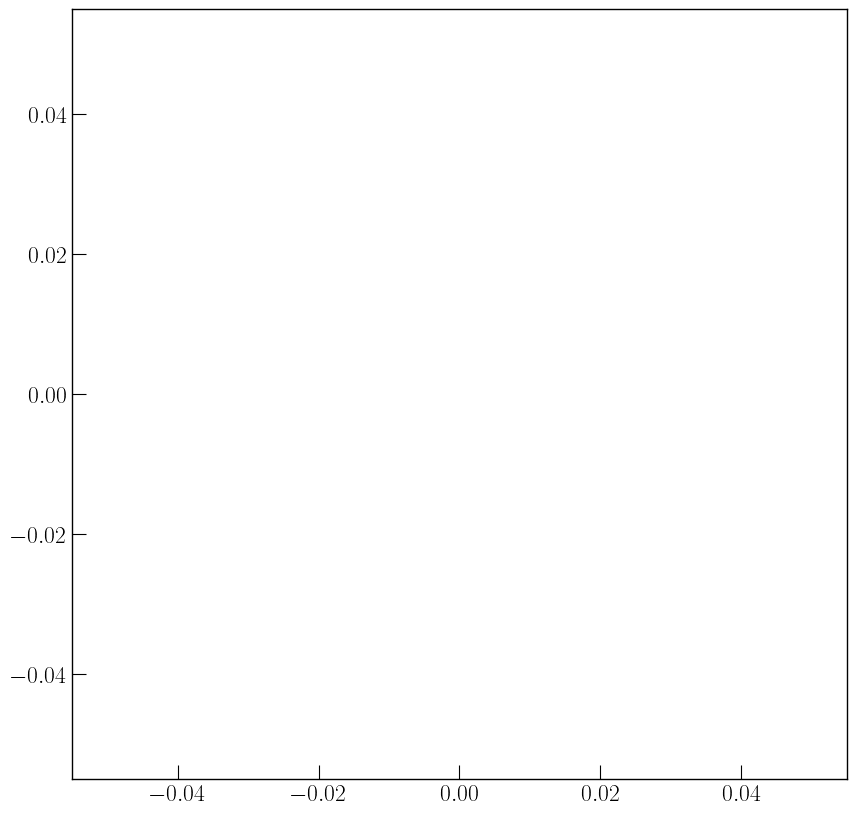

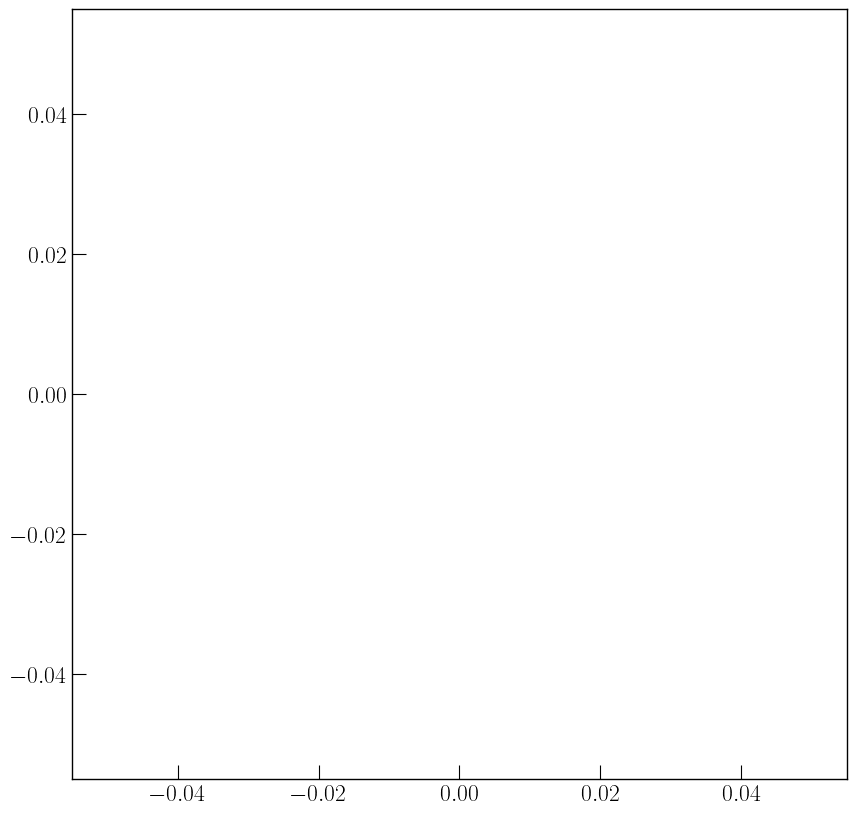

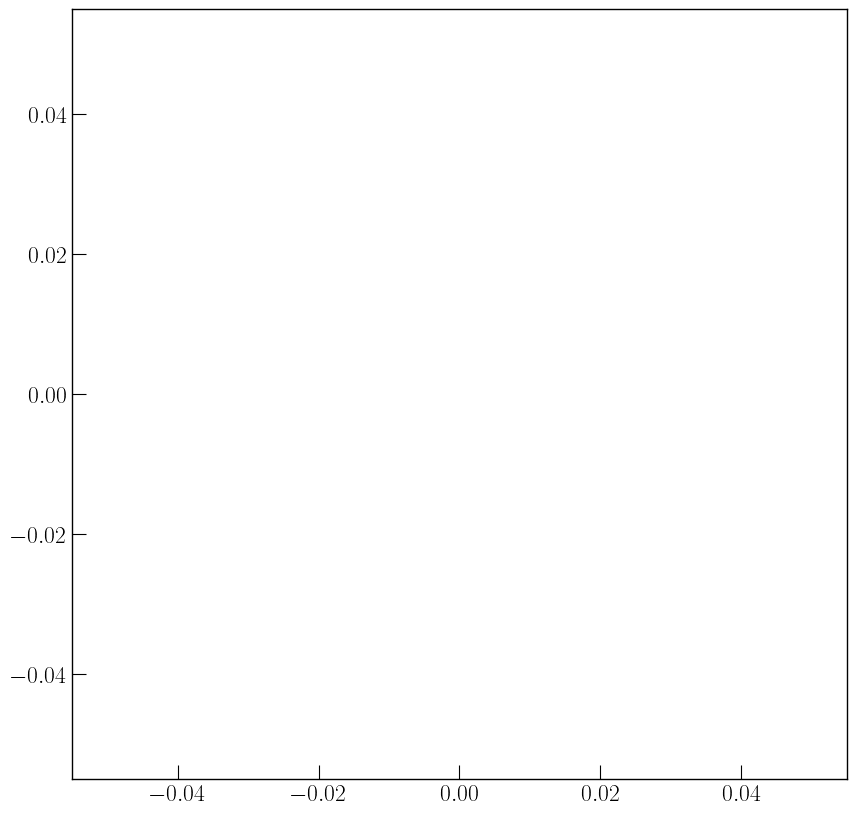

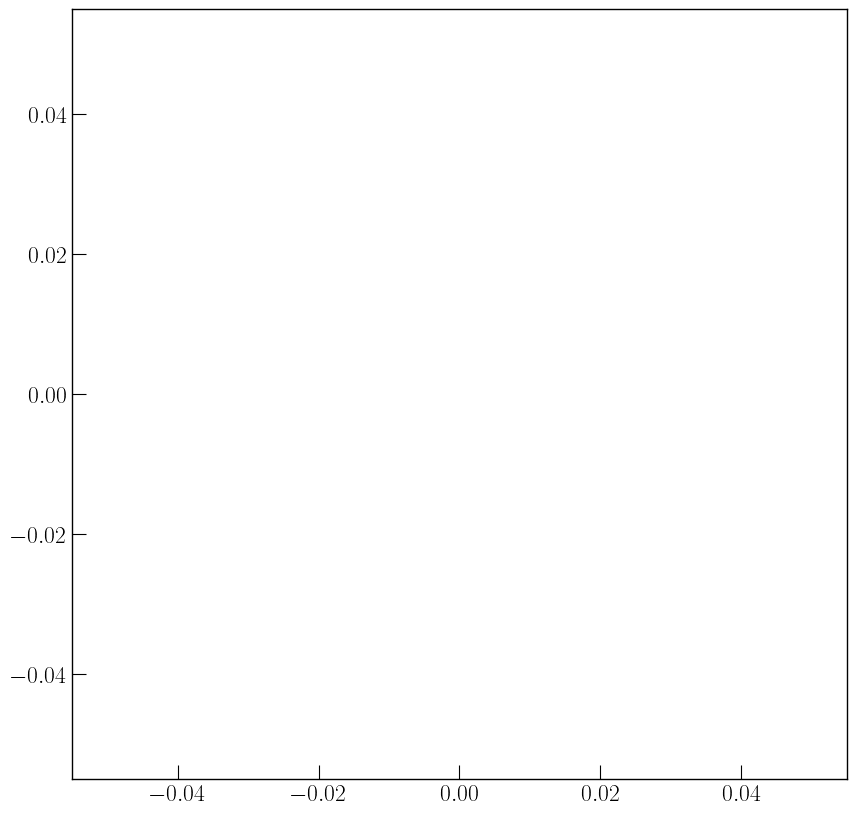

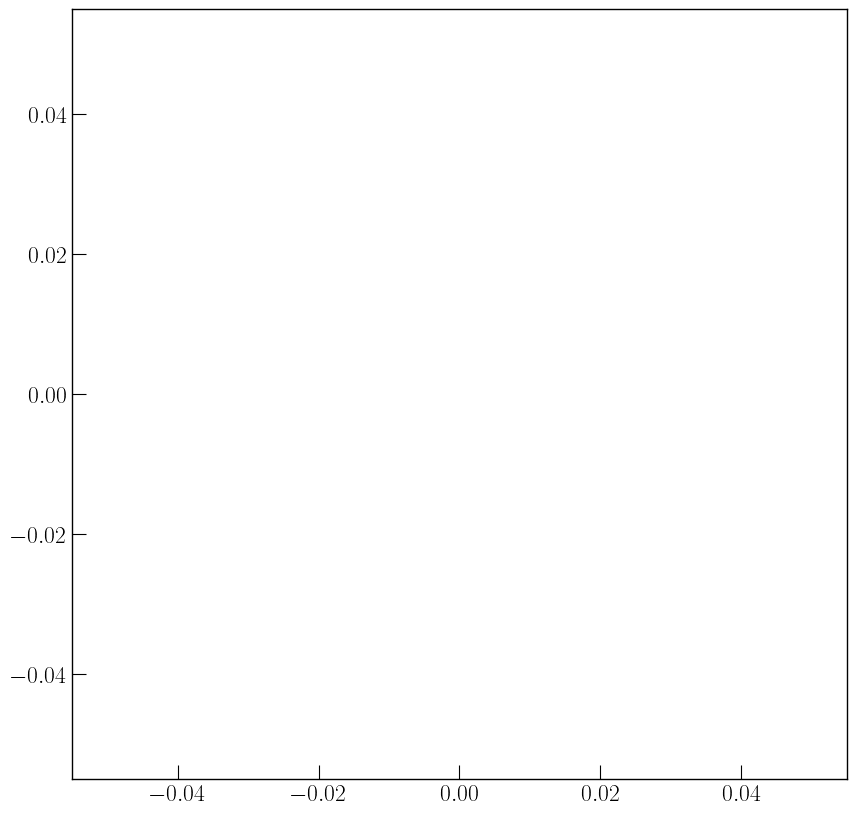

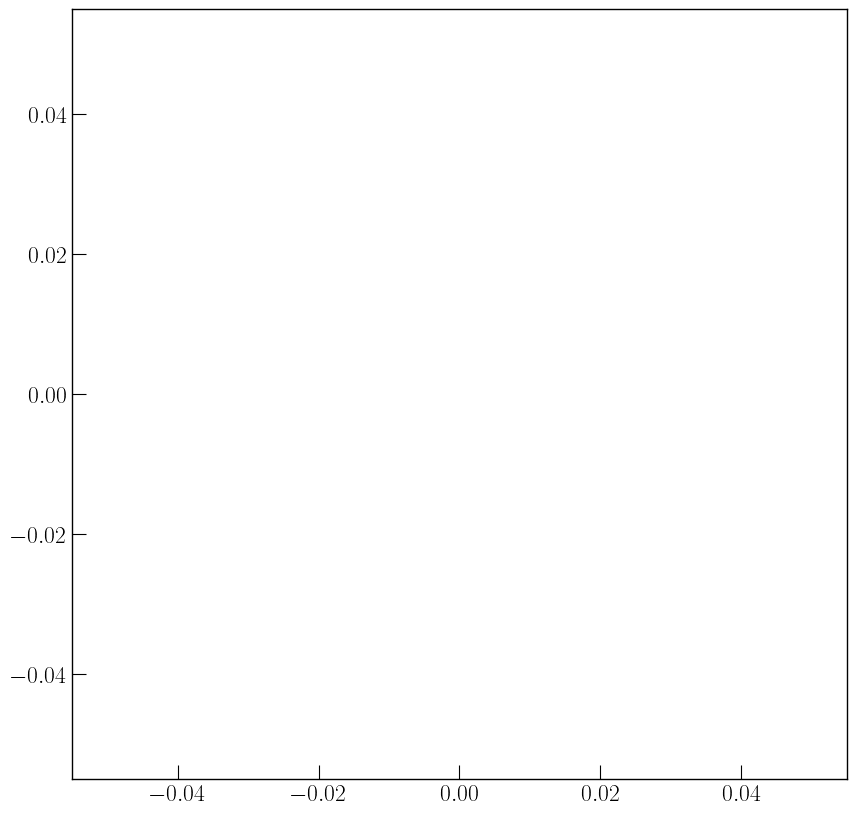

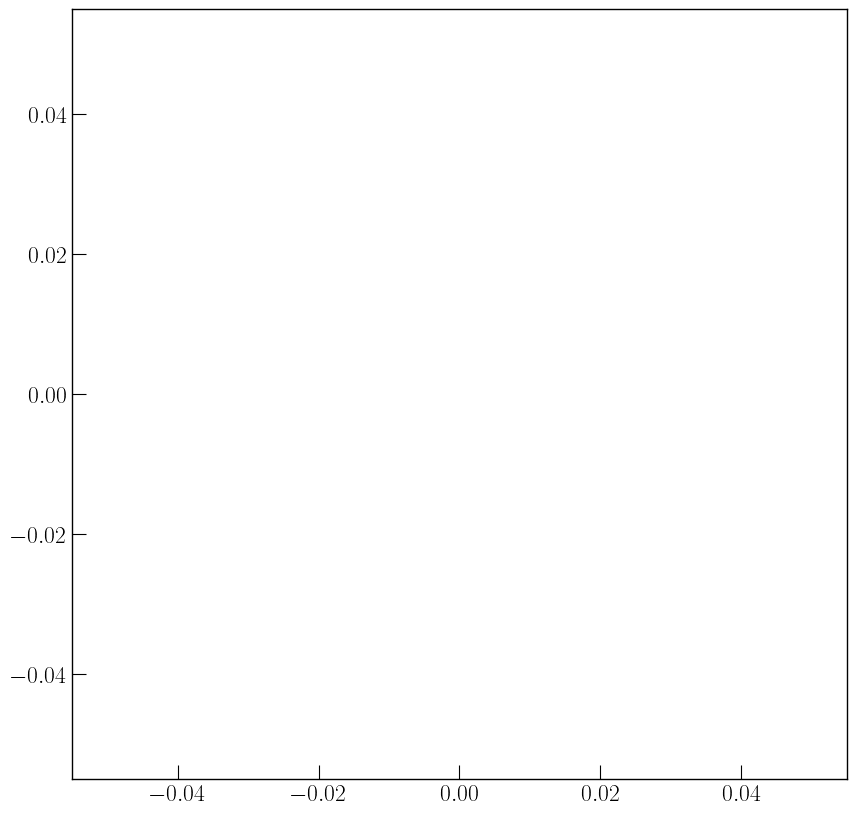

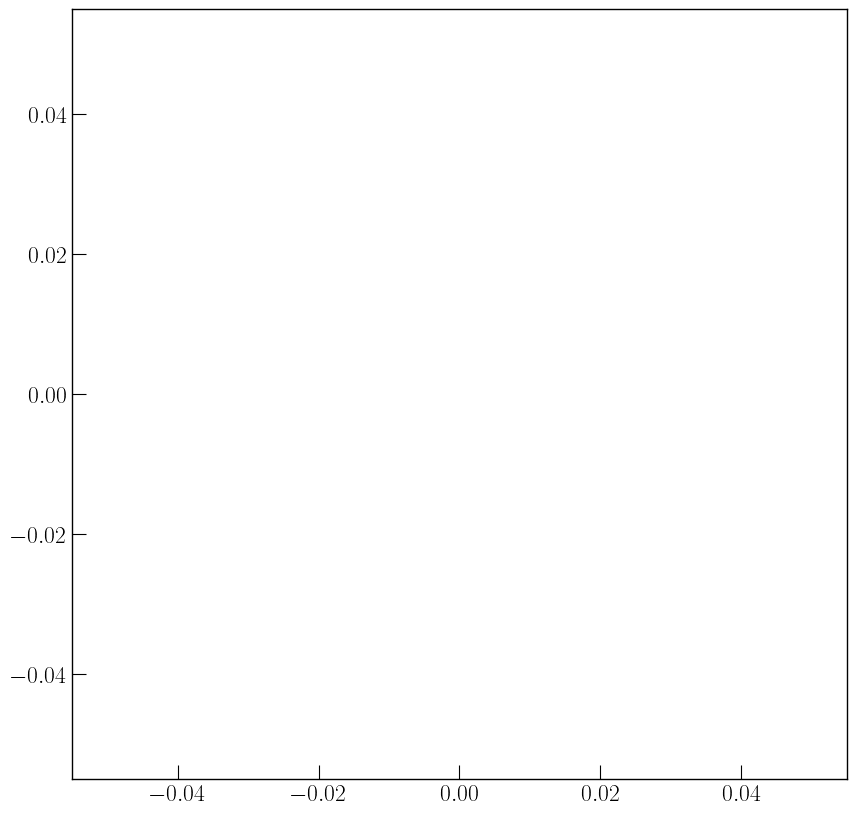

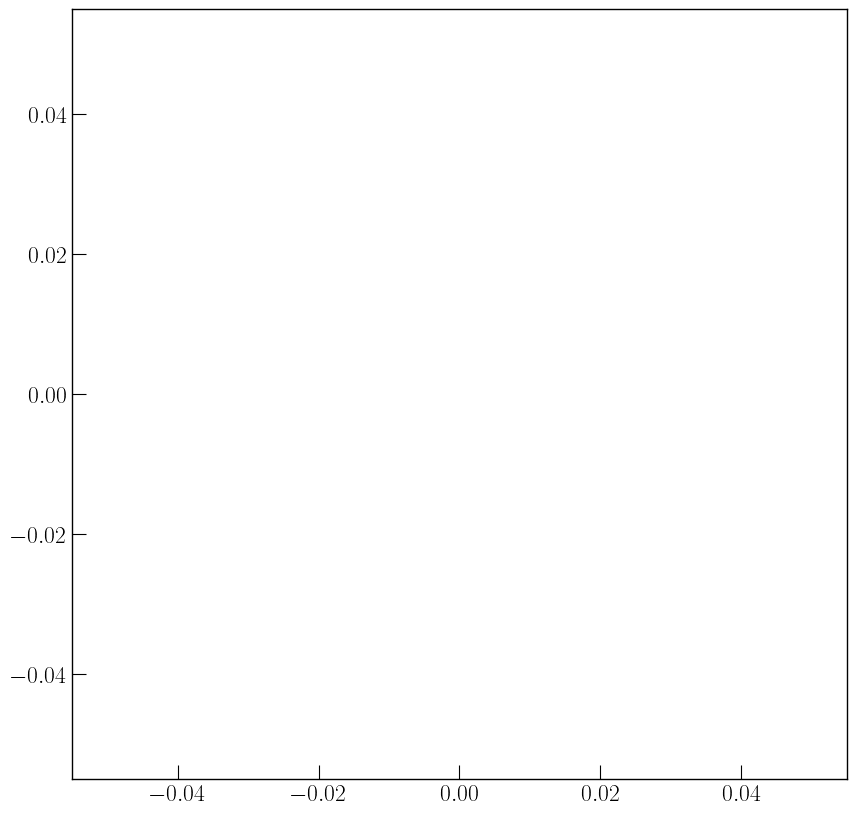

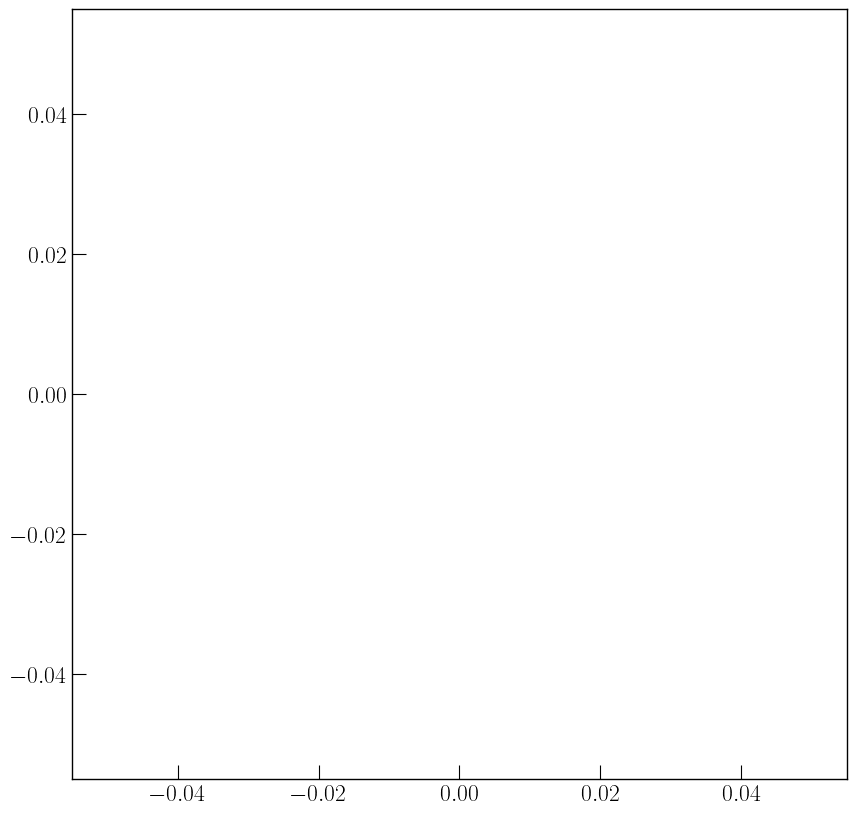

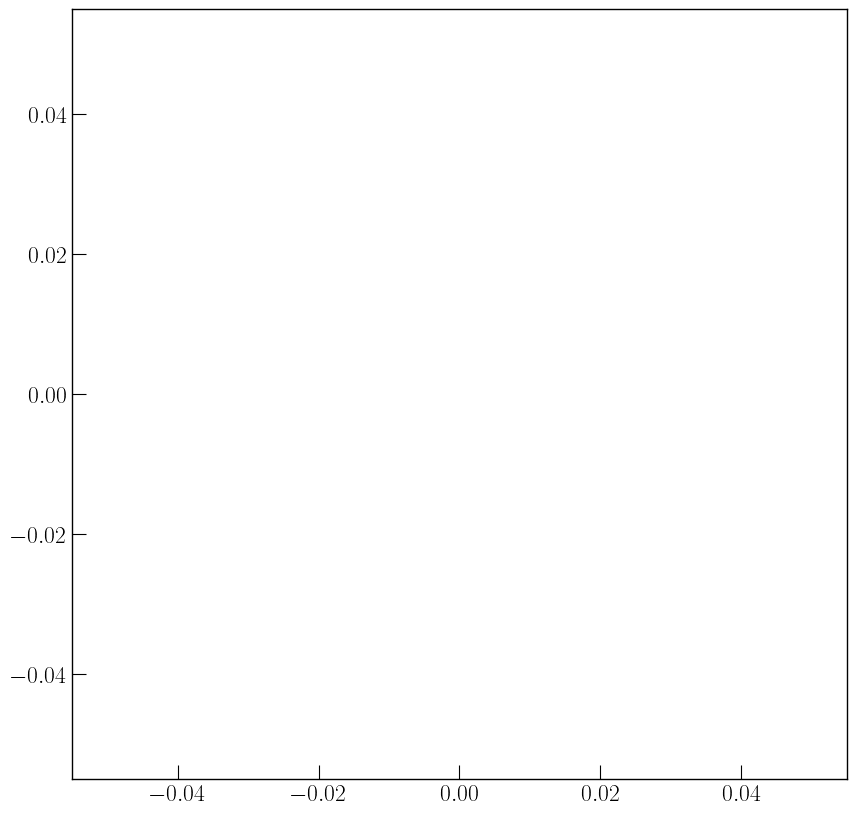

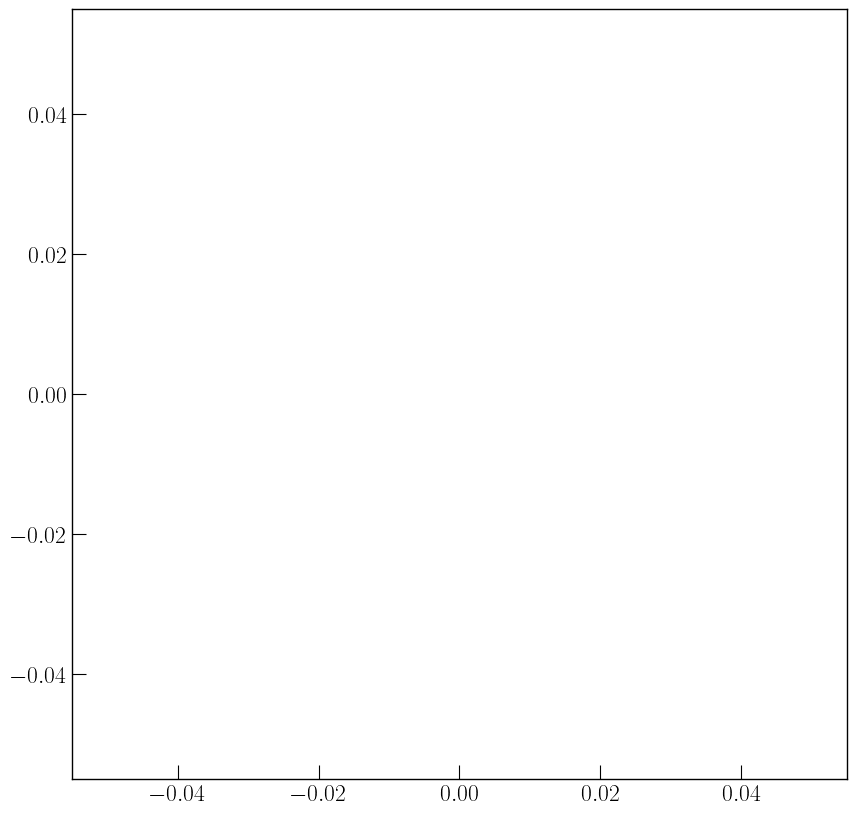

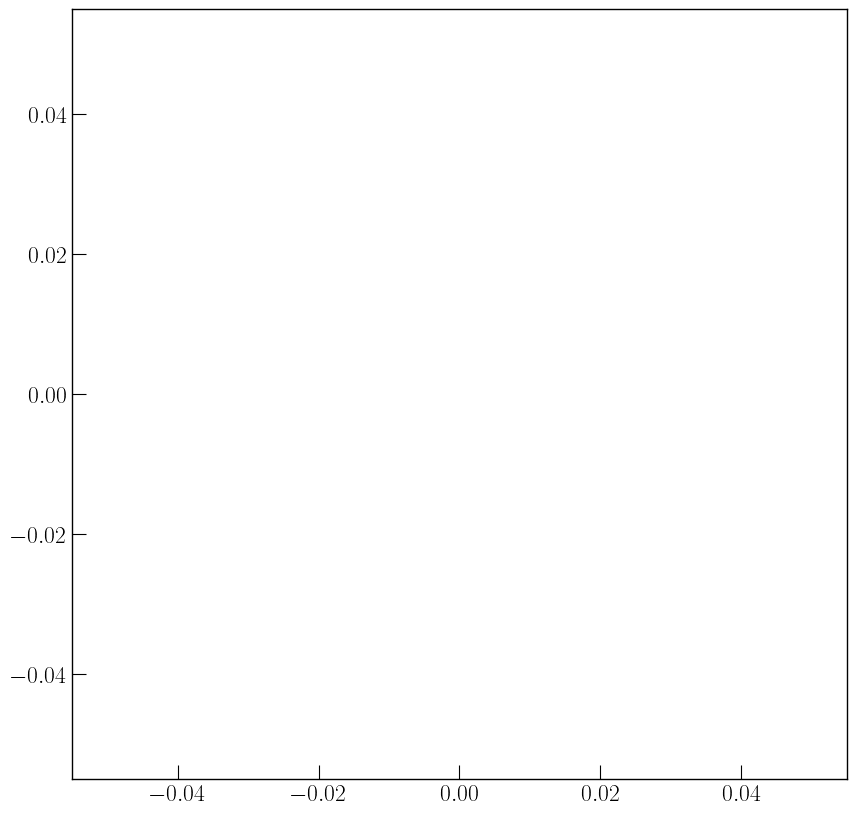

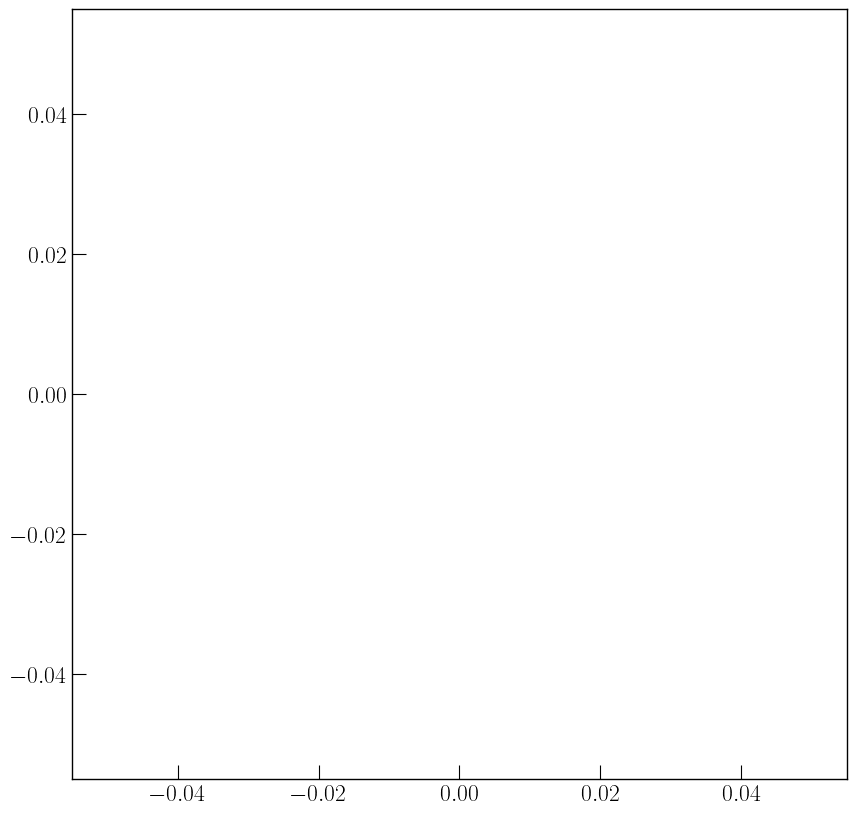

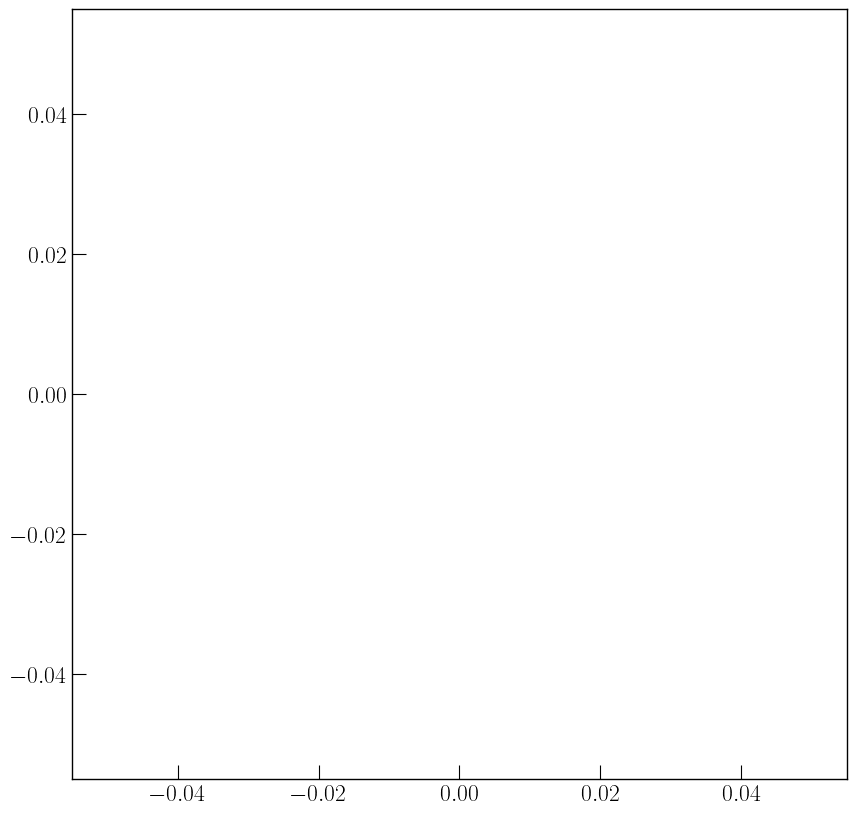

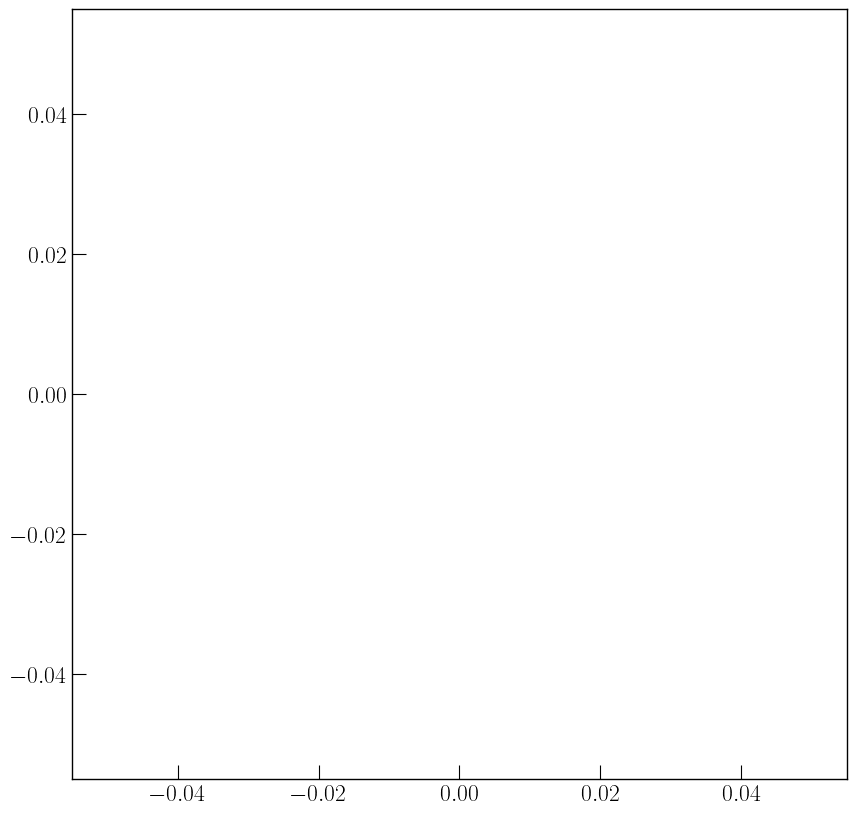

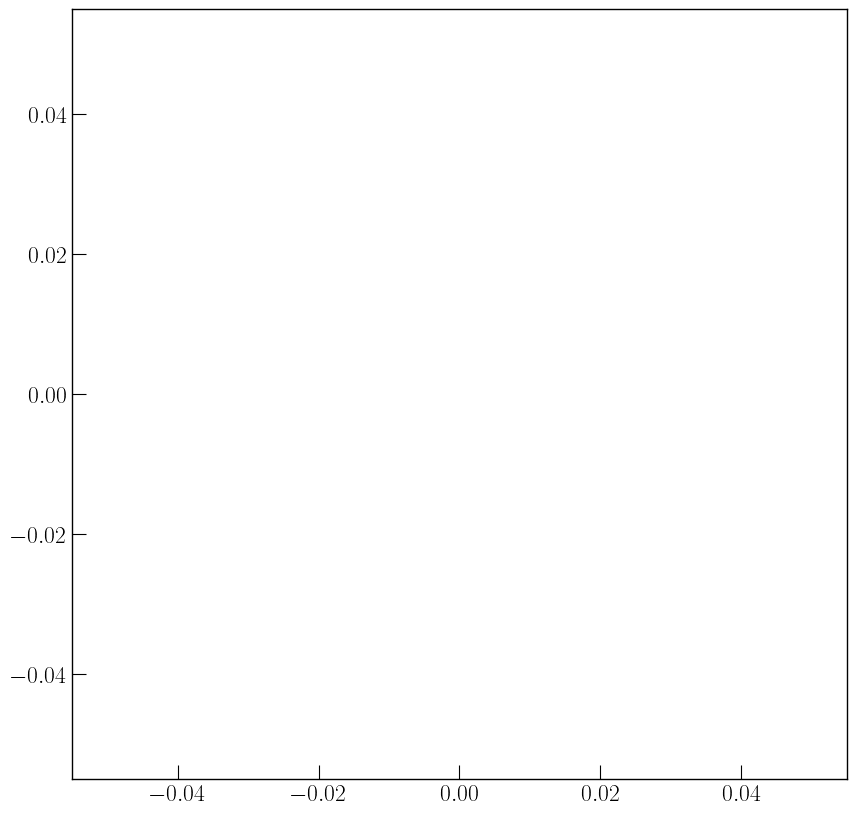

In [6]:
for _ in range(100): plt.plot(); plt.show()

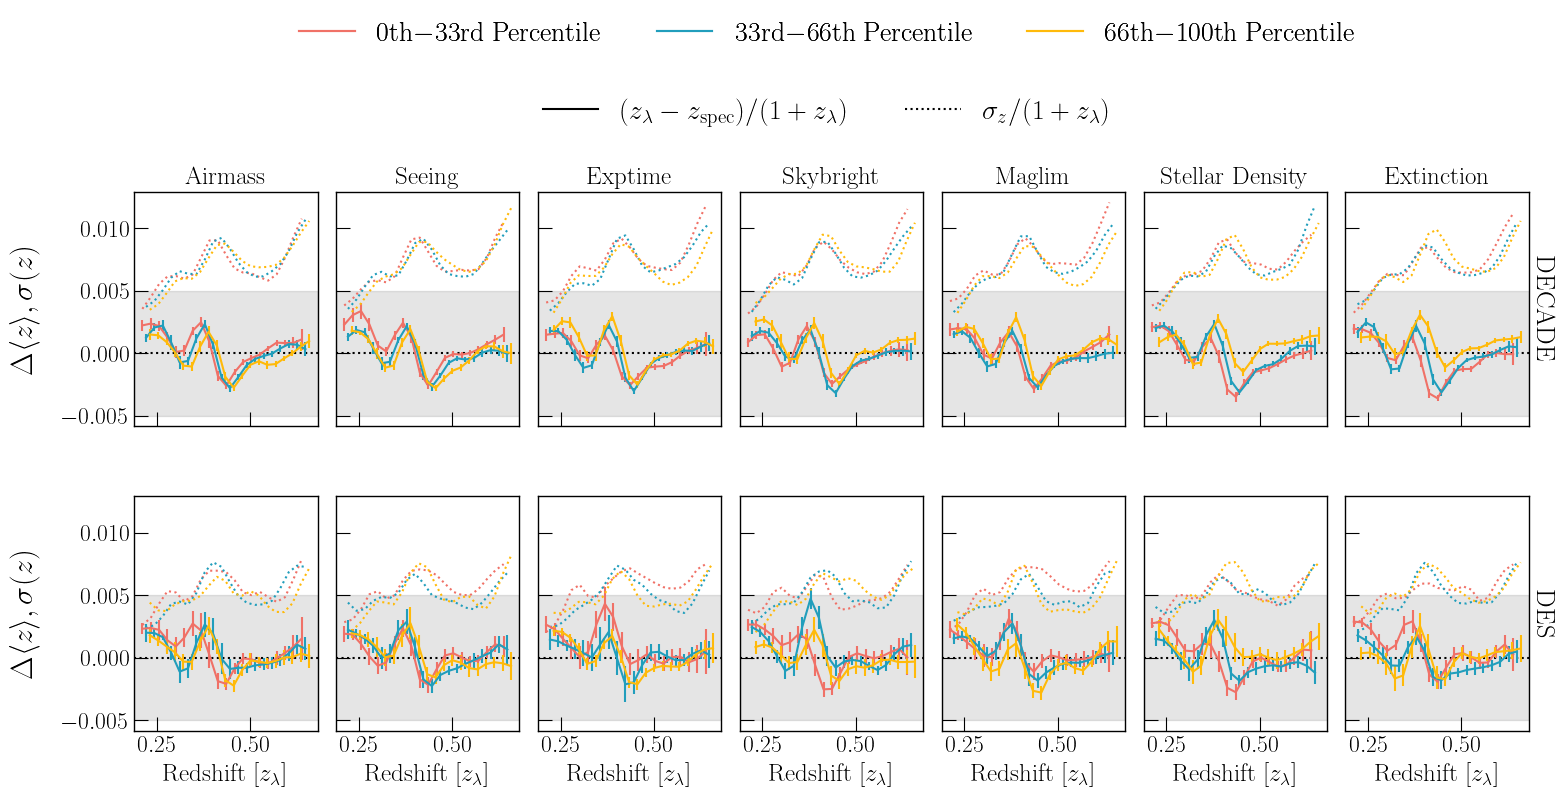

In [16]:
fig, ax = plt.subplots(2, 7, figsize = (18, 7), sharex = True, sharey = True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.1)

zbs   = np.linspace(0.2, 0.65, 20 + 1)
zcn   = (zbs[1:] + zbs[:-1])/2
bands = 'i'
Nsys  = 3

label = {'airmass' : 'Airmass',
         'fwhm' : 'Seeing',
         'exptime' : 'Exptime',
         'skybrite' : 'Skybright',
         'maglim'   : 'Maglim',
         'stellar_density'   : 'Stellar Density',
         'extinction'        : 'Extinction'}

for r, data, data_sys in zip([0, 1], [decade, des], [decade_sys, des_sys]):
    
    msk = (data['cg_spec_z'] > -1) & (np.abs(data['z_lambda'] - data['cg_spec_z']) / data['cg_spec_z'] < 0.15)
    
    data     = data.copy()[msk]
    data_sys = data_sys.copy()[msk]
    
    for i, sys in enumerate(['airmass', 'fwhm', 'exptime', 'skybrite', 'maglim', 'stellar_density', 'extinction']):
        
        b_i = 0
        N   = f'{sys}_{bands[b_i]}' if i < 5 else sys
        per = np.percentile(data_sys[N], np.linspace(0, 100, Nsys + 1))

        for p_i in range(Nsys):
            sym = (data_sys[N] >= per[p_i]) & (data_sys[N] < per[p_i+1])
            med, avg, std, err = run(sym, data)
            ax[r,i].errorbar(zcn + 0.01 * p_i, np.median(med, axis = 0), yerr = np.std(med, axis = 0), 
                             color = f'C{p_i}', label = bands[b_i])
            ax[r,i].plot(zcn + 0.01 * p_i, std, color = f'C{p_i}', ls = ':')
            
        if r == 0: ax[r,i].set_title(label[sys], size = 18)

                
[a.axhline(0, color = 'k', ls = ":", zorder = -1000) for a in ax.flat]
[a.axhspan(-0.005, 0.005, color = 'k', alpha = 0.1, zorder = -1000) for a in ax.flat]


[a.set_ylabel(r'$\Delta \langle z \rangle, \sigma(z)$', size = 22, labelpad = 15) for a in ax[:, 0]]
[a.set_xlabel(r'Redshift [$z_{\lambda}$]', size = 18) for a in ax[1]]


lg = fig.legend([plt.plot([], [])[0] for _ in range(3)], 
                [r'0th$-$33rd Percentile', r'33rd$-$66th Percentile', r'66th$-$100th Percentile'],
                fontsize = 20, ncol = 3, loc = 'upper center', bbox_to_anchor = (0.51, 1.16))


fig.legend([plt.plot([], [], ls = '-', color = 'k')[0], plt.plot([], [], ls = ':', color = 'k')[0]], 
           [r'$(z_\lambda - z_{\rm spec})/(1 + z_\lambda)$', r'$\sigma_{z}/(1 + z_\lambda)$'],
           fontsize = 20, ncol = 2, loc = 'upper center', bbox_to_anchor = (0.51, 1.05))

fig.add_artist(lg)


ax[0, -1].text(
    1.08, 0.5, "DECADE",
    transform=ax[0, -1].transAxes,
    rotation=270,
    va="center",
    ha="center",
    fontsize=19,
    fontweight="bold"
)

ax[1, -1].text(
    1.08, 0.5, "DES",
    transform=ax[1, -1].transAxes,
    rotation=270,
    va="center",
    ha="center",
    fontsize=19,
    fontweight="bold"
)

plt.savefig('./redshift_systematic.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()

# Richness

In [4]:
def run2(z, data, N = 10):
    
    dz  = data['lambda_ce']
    dm  = data['lambda_c']
    zbs = np.linspace(*np.nanpercentile(z, [5, 95]), N + 1)
    zc  = (zbs[1:] + zbs[:-1])/2
    
    ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
    med = [stats.binned_statistic(z[m], dm[m], statistic = 'median', bins = zbs)[0] for m in ind]
    avg = [stats.binned_statistic(z[m], dm[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
    std = [stats.binned_statistic(z[m], dm[m], statistic = 'std',    bins = zbs)[0] for m in ind]
    err = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]

    std = [np.interp(zc, zc[~np.isnan(m)], m[~np.isnan(m)]) for m in std]
    med = [np.interp(zc, zc[~np.isnan(m)], m[~np.isnan(m)]) for m in med]
    avg = [np.interp(zc, zc[~np.isnan(m)], m[~np.isnan(m)]) for m in avg]
    
    std = [gaussian_filter1d(m, sigma = 1) for m in std]
    med = [gaussian_filter1d(m, sigma = 1) for m in med]
    avg = [gaussian_filter1d(m, sigma = 1) for m in avg]
    
    
    return med, avg, std, err, zc

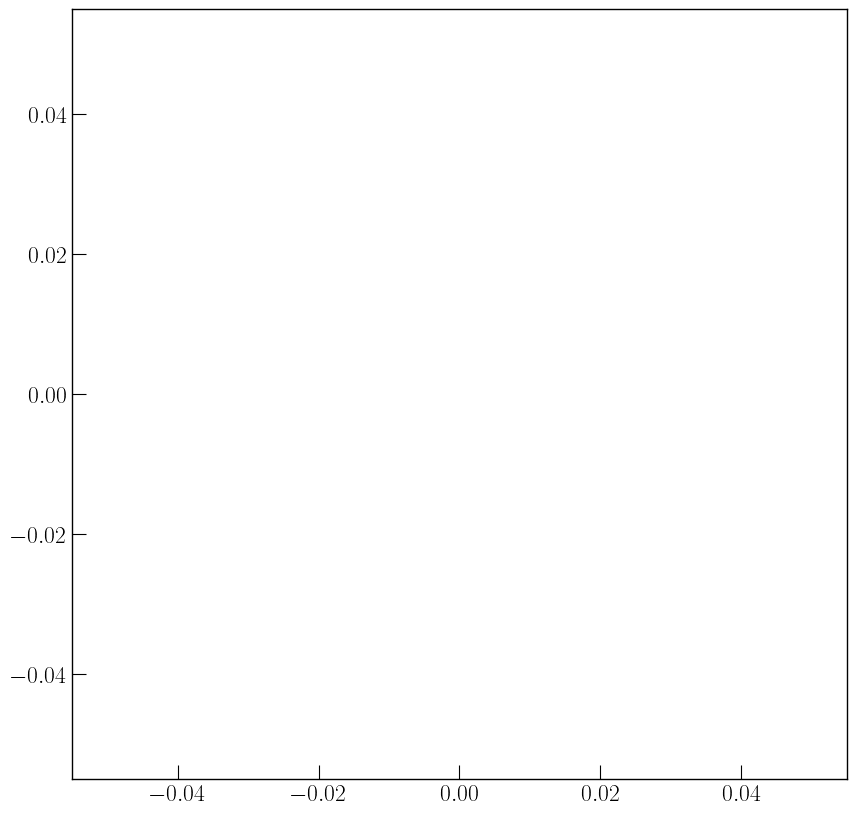

In [7]:
plt.plot(); plt.show()

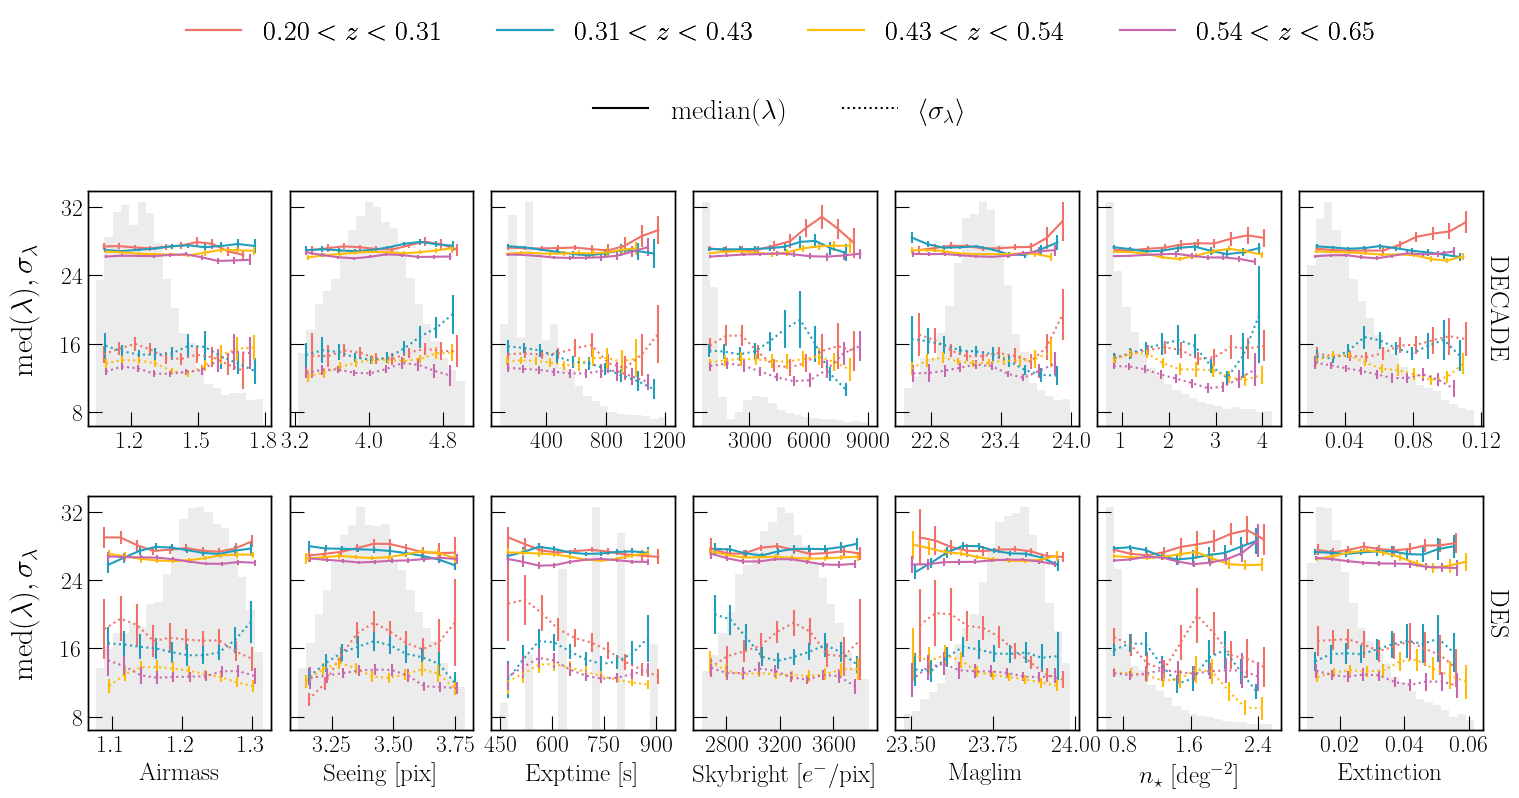

In [26]:
fig, ax = plt.subplots(2, 7, figsize = (18, 7), sharex = False, sharey = True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.1)


Nz    = 4
zbins = np.linspace(0.2, 0.65, Nz + 1)
bands = 'i'
label = {'airmass' : 'Airmass',
         'fwhm' : 'Seeing [pix]',
         'exptime' : 'Exptime [s]',
         'skybrite' : 'Skybright [$e^{-}$/pix]',
         'maglim'   : 'Maglim',
         'stellar_density'   : r'$n_\star$ [deg$^{-2}$]',
         'extinction'        : 'Extinction'}

for r, data, data_sys in zip([0, 1], [decade, des], [decade_sys, des_sys]):
    
    for i, sys in enumerate(['airmass', 'fwhm', 'exptime', 'skybrite', 'maglim', 'stellar_density', 'extinction']):

        b_i = 0
        N = f'{sys}_{bands[b_i]}' if i < 5 else sys
        
        mmax, mmin = 0, np.inf
        for z_i in range(Nz):
            msk  = (data['z_lambda'] > zbins[z_i]) & (data['z_lambda'] < zbins[z_i+1])
            vals = np.nanpercentile(data_sys[N][msk], [5, 95])
            
            mmin = min(mmin, vals[0])
            mmax = max(mmax, vals[1])
            
            
        bins = np.linspace(mmin, mmax, 21)

        hax = ax[r,i].twinx()
        hax.set_zorder(0); ax[r,i].set_zorder(1); ax[r,i].patch.set_alpha(0)
        hax.set_yticks([]); hax.set_ylabel('')
        
        vals = data_sys[N]; vals = vals[np.isfinite(vals)]
        hax.hist(vals, bins=bins, density=True, histtype='stepfilled', color=f'k', alpha=0.075, lw=0)


        for z_i in range(Nz):

            msk  = (data['z_lambda'] > zbins[z_i]) & (data['z_lambda'] < zbins[z_i+1])
            
            med, avg, std, err, zc = run2(data_sys[N][msk], data[msk])

            ax[r,i].errorbar(zc, np.median(med, axis=0), yerr=np.std(med, axis=0),
                             color=f'C{z_i}', label=bands[b_i], zorder=3)

            ax[r,i].errorbar(zc, np.median(std, axis=0), yerr=np.std(std, axis=0),
                             color=f'C{z_i}', ls=':', zorder=3)

            if r == 1: 
                ax[r,i].set_xlabel(label[sys], size = 18)


[a.set_ylabel(r'${\rm med}(\lambda), \sigma_\lambda$', size = 22, labelpad = 15) for a in ax[:, 0]]

lg = fig.legend([plt.plot([], [])[0] for _ in range(Nz)], 
                [fr'${zbins[i]:0.2f} < z < {zbins[i+1]:0.2f}$' for i in range(Nz)],
                fontsize = 20, ncol = Nz, loc = 'upper center', bbox_to_anchor = (0.51, 1.16))


fig.legend([plt.plot([], [], ls = '-', color = 'k')[0], plt.plot([], [], ls = ':', color = 'k')[0]], 
           [r'${\rm median}(\lambda)$', r'$\langle \sigma_\lambda \rangle$'],
           fontsize = 20, ncol = 2, loc = 'upper center', bbox_to_anchor = (0.51, 1.05))

fig.add_artist(lg)


from matplotlib.ticker import MaxNLocator

for a in ax.flat:
    # Ask matplotlib for at least 3 major ticks on each axis
    a.xaxis.set_major_locator(MaxNLocator(nbins=2, min_n_ticks=3))
    a.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=4))
        

ax[0, -1].text(
    1.08, 0.5, "DECADE",
    transform=ax[0, -1].transAxes,
    rotation=270,
    va="center",
    ha="center",
    fontsize=19,
    fontweight="bold"
)

ax[1, -1].text(
    1.08, 0.5, "DES",
    transform=ax[1, -1].transAxes,
    rotation=270,
    va="center",
    ha="center",
    fontsize=19,
    fontweight="bold"
)

plt.savefig('./richness_systematic.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()